In [1]:
# Consolidated Import Section - Grouped by standard libraries, data science tools, geospatial libraries, and forecasting/ML models
# Monkeypatch pandas deprecate_kwarg for compatibility with older statsmodels/pandas versions
try:
    import pandas.util._decorators as decorators
    original_deprecate_kwarg = decorators.deprecate_kwarg
    def patched_deprecate_kwarg(klass, old_arg_name=None, new_arg_name=None, mapping=None, stacklevel=2):
        if isinstance(klass, str):
            new_arg_name = old_arg_name
            old_arg_name = klass
            klass = FutureWarning
        return original_deprecate_kwarg(klass, old_arg_name, new_arg_name, mapping=mapping, stacklevel=stacklevel)
    decorators.deprecate_kwarg = patched_deprecate_kwarg
except Exception:
    pass

import os
import sys
import time
import warnings
import logging
import traceback
from datetime import datetime, timedelta
from ast import literal_eval

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import torch
import timesfm
from chronos import ChronosPipeline

import geopandas as gpd
from shapely.geometry import Point, box
import rasterio
try:
    import contextily as cx
except ImportError:
    cx = None

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import shap
import pingouin as pg
from joblib import Parallel, delayed
from tqdm import tqdm

# Set configuration for plots and logging
matplotlib.set_loglevel("ERROR")
# matplotlib.use('Agg')
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
print("All standard imports initialized successfully.")



# ==========================================
# SEEDING FOR REPRODUCIBILITY
# ==========================================
def set_reproducible_seeds(seed=42):
    import random
    import numpy as np
    import os
    
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
            # Try to force deterministic algorithms if supported
            try:
                torch.use_deterministic_algorithms(True)
            except Exception:
                pass
    except ImportError:
        pass
set_reproducible_seeds(42)
print("Global seeds initialized for reproducibility.")


Importing plotly failed. Interactive plots will not work.


All standard imports initialized successfully.
Global seeds initialized for reproducibility.


# Creating folder 

In [2]:
# Create base folders under a timestamped run super folder (no outputs/figures split)
# Automatically reuse the latest existing results_* folder if it exists on disk, unless forced otherwise.
import glob
import os
from datetime import datetime

# Set FORCE_FRESH_RUN to True if you want to rerun all training/prediction from scratch.
FORCE_FRESH_RUN = False 

existing_runs = sorted(glob.glob("results_*"))
if existing_runs and not FORCE_FRESH_RUN:
    run_output_dir = existing_runs[-1]
    outputs_dir = run_output_dir
    figures_dir = run_output_dir
    print(f"Resuming analysis using latest existing run folder: {run_output_dir}")
else:
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    run_output_dir = f"results_{timestamp}"
    outputs_dir = run_output_dir
    figures_dir = run_output_dir
    print(f"Starting fresh run. Initialized all outputs under super folder: {run_output_dir}")

os.makedirs(os.path.join(run_output_dir, "predictions"), exist_ok=True)
os.makedirs(os.path.join(run_output_dir, "statistics"), exist_ok=True)
os.makedirs(os.path.join(run_output_dir, "validation", "sarimax"), exist_ok=True)
os.makedirs(os.path.join(run_output_dir, "validation", "timesfm"), exist_ok=True)
os.makedirs(os.path.join(run_output_dir, "validation", "chronos"), exist_ok=True)
os.makedirs(os.path.join(run_output_dir, "validation", "prophet"), exist_ok=True)
os.makedirs(os.path.join(run_output_dir, "validation", "combined"), exist_ok=True)
os.makedirs(os.path.join(run_output_dir, "maps"), exist_ok=True)
os.makedirs(os.path.join(run_output_dir, "ablation"), exist_ok=True)
os.makedirs(os.path.join(run_output_dir, "SHAP"), exist_ok=True)


Resuming analysis using latest existing run folder: results_2026-06-30_23-59-42


# Data

## Loading data

In [3]:
import time
print("Reading file")
start_time = time.time()
df = pd.read_csv("data/raw/final_cleaned_w_cbg.csv")
print(f"Loaded {len(df)} POIs in {time.time() - start_time:.2f} seconds.")


Reading file
Loaded 392392 POIs in 8.93 seconds.


In [4]:
df_unique = df.drop_duplicates(subset='polygon_wkt').copy()
print(f"Unique POIs: {len(df_unique)}")

Unique POIs: 253169


## Preprocessing

In [5]:
import os
import time
from ast import literal_eval

cache_path = "data/raw/df_unique_preprocessed.pkl"
if os.path.exists(cache_path):
    print("Loading preprocessed df_unique from cache...")
    start_time = time.time()
    df_unique = pd.read_pickle(cache_path)
    print(f"Loaded {len(df_unique)} POIs from cache in {time.time() - start_time:.2f} seconds.")
    _SKIP_FEATURE_ENG = True
else:
    _SKIP_FEATURE_ENG = False
    start_time = time.time()
    df_unique['visits_list'] = df_unique['visits_list'].apply(literal_eval)
    print(f"Finished parsing visits time series in {time.time() - start_time:.2f} seconds.")

Loading preprocessed df_unique from cache...
Loaded 253169 POIs from cache in 2.59 seconds.


### Adding date

In [6]:
start_date = datetime(2023, 5, 1)
date_range = [start_date + timedelta(days=i) for i in range(len(df_unique.iloc[0]['visits_list']))]
hurricane_date = datetime(2024, 9, 23)

### Feature engineering

In [7]:
import time
start_step = time.time()
if globals().get('_SKIP_FEATURE_ENG', False):
    print("✅ [SKIP] Visit metrics already computed and loaded from cache.")
else:
    # tqdm-compatible apply
    tqdm.pandas(desc="Computing visit metrics")

    def compute_mean(visit_list):
        if len(visit_list) != len(date_range):
            return pd.Series([np.nan]*3, index=['mean_per_day', 'mean_before_hurricane', 'mean_after_hurricane'])

        visits = np.array(visit_list)
        dates = np.array(date_range)

        before_mask = dates < hurricane_date
        after_mask = dates >= hurricane_date

        mean_all = np.mean(visits)
        mean_before = np.mean(visits[before_mask]) if np.any(before_mask) else np.nan
        mean_after = np.mean(visits[after_mask]) if np.any(after_mask) else np.nan

        return pd.Series([mean_all, mean_before, mean_after],
                         index=['mean_per_day', 'mean_before_hurricane', 'mean_after_hurricane'])

    df_unique[['mean_per_day', 'mean_before_hurricane', 'mean_after_hurricane']] = df_unique['visits_list'].progress_apply(compute_mean)

    # Save to cache
    cache_path = "data/raw/df_unique_preprocessed.pkl"
    df_unique.to_pickle(cache_path)
    print(f"Preprocessed df_unique saved to cache at: {cache_path}")
    print(f"[Step 6] Visit metrics computed in {time.time() - start_step:.2f} seconds")


✅ [SKIP] Visit metrics already computed and loaded from cache.


In [8]:
df_unique.columns


Index(['placekey', 'latitude', 'longitude', 'location_name', 'naics_code',
       'safegraph_brand_ids', 'brands', 'open_hours', 'category_tags',
       'opened_on', 'closed_on', 'street_address', 'city', 'region',
       'postal_code', 'tracking_closed_since', 'websites', 'geometry_type',
       'polygon_wkt', 'polygon_class', 'enclosed', 'phone_number',
       'is_synthetic', 'includes_parking_lot', 'iso_country_code',
       'wkt_area_sq_meters', 'total_visit_2025', 'visits_list', 'index_right',
       'GEOID', 'mean_per_day', 'mean_before_hurricane',
       'mean_after_hurricane'],
      dtype='str')

In [9]:
top10_df = df_unique.nlargest(10, 'mean_per_day').copy()
print("Top 10 POIs with highest average daily visits:")
top10_df[['placekey', 'location_name', 'mean_per_day']].reset_index(drop=True)


Top 10 POIs with highest average daily visits:


,placekey,location_name,mean_per_day
0,zzw-222@8gg-2xh-rff,Concord Regional Airport,2539.397516
1,zzw-229@63g-489-yn5,Piedmont Triad International Airport,2238.590062
2,229-22c@645-9t9-rff,University Commons,2224.642857
3,22x-222@63f-kw6-k75,Brier Creek Commons,1872.102484
4,zzy-222@8gg-354-swk,BJ's Restaurants,1821.757764
5,222-222@8gg-d7n-cyv,Mooresville Consumer Square,1792.830745
6,222-222@8gg-86h-3yv,Stratford Commons,1733.930124
7,224-224@63f-kvp-nwk,Rena Pate,1727.164596
8,222-222@8gf-qfp-5pv,Appalachian State University,1699.920807
9,zzw-222@645-9t8-qcq,University Of North Carolina Wilmington,1656.012422


### Location-Based Data Filtering

In [ ]:
# Western NC counties and FIPS
western_nc_counties = {
    "Cherokee": "37039", "Graham": "37075", "Clay": "37043", "Macon": "37113",
    "Swain": "37173", "Jackson": "37099", "Haywood": "37087", "Transylvania": "37175",
    "Henderson": "37089", "Buncombe": "37021", "Madison": "37115", "Yancey": "37199",
    "McDowell": "37111", "Rutherford": "37161", "Polk": "37149", "Mitchell": "37121",
    "Avery": "37011", "Burke": "37023", "Cleveland": "37045", "Watauga": "37189",
    "Ashe": "37009", "Caldwell": "37027", "Alleghany": "37005", "Wilkes": "37193",
    "Alexander": "37003", "Catawba": "37035", "Lincoln": "37109", "Gaston": "37071",
    "Surry": "37171", "Yadkin": "37197", "Mecklenburg": "37119", "Iredell": "37097", "Wake": "37183" , "Guilford": "37081"}

# placebo_effect_eastern_counties = {}

# combined_counties = {**western_nc_counties, **placebo_effect_eastern_counties}

# Filter by GEOID and mean_per_day
fips_prefixes = list(western_nc_counties.values())

# Add county name
def find_county(geoid):
    for county, fips in western_nc_counties.items():
        if str(geoid).startswith(fips):
            return county
    return None

df_filtered = df_unique[
    df_unique['GEOID'].astype(str).str[:5].isin(fips_prefixes) &
    (df_unique['mean_per_day'] > 25)
].copy()

df_filtered['county'] = df_filtered['GEOID'].astype(str).str[:5].map({v: k for k, v in western_nc_counties.items()})

# Count by county
counts_by_county = df_filtered['county'].value_counts().reset_index()
counts_by_county.columns = ['county', 'num_POIs']

df_filtered_summary = df_filtered[['placekey', 'county', 'mean_per_day']]

df_filtered.shape[0], counts_by_county


(5671,
           county  num_POIs
 0    Mecklenburg      1461
 1           Wake      1249
 2       Guilford       536
 3       Buncombe       354
 4        Catawba       248
 5         Gaston       239
 6        Iredell       237
 7      Henderson       120
 8        Lincoln       107
 9      Cleveland       102
 10         Surry        91
 11        Wilkes        86
 12         Burke        86
 13       Watauga        81
 14       Haywood        72
 15    Rutherford        68
 16       Jackson        65
 17      Caldwell        62
 18         Macon        57
 19  Transylvania        53
 20         Avery        48
 21      McDowell        39
 22        Yadkin        31
 23      Cherokee        31
 24         Swain        22
 25          Ashe        22
 26     Alexander        22
 27          Polk        19
 28       Madison        16
 29        Yancey        13
 30     Alleghany        12
 31      Mitchell        12
 32        Graham         7
 33          Clay         3)

In [11]:
df_filtered.head()


,placekey,latitude,longitude,location_name,naics_code,safegraph_brand_ids,brands,open_hours,category_tags,opened_on,...,iso_country_code,wkt_area_sq_meters,total_visit_2025,visits_list,index_right,GEOID,mean_per_day,mean_before_hurricane,mean_after_hurricane,county
1,zzy-226@63g-2dz-kcq,36.099589,-79.778028,Prominent Marketing,3231,NaN,NaN,"{ ""Mon"": [[""9:00"", ""17:00""]], ""Tue"": [[""9:00"",...","Graphic Design,Marketing",NaN,...,US,30732.0,878,"[35, 38, 45, 47, 51, 36, 47, 31, 44, 43, 44, 5...",3190.0,3.708101e+11,39.785714,42.017613,31.210526,Guilford
6,229-222@8gf-r5g-2hq,35.594863,-82.550944,Leah B Noel CPA,5412,NaN,NaN,"{ ""Mon"": [[""9:00"", ""17:00""]], ""Tue"": [[""9:00"",...","Accountants,Financial Advice",NaN,...,US,9302.0,890,"[25, 45, 66, 68, 40, 99, 69, 54, 41, 40, 77, 7...",4637.0,3.702100e+11,74.220497,84.144814,36.090226,Buncombe
13,22b-222@8gf-dk3-d35,35.224164,-81.036060,Steven Dalrymple Vacation Consultant,5615,NaN,NaN,"{ ""Mon"": [[""10:00"", ""18:00""]], ""Tue"": [[""10:00...",NaN,NaN,...,US,6270.0,3715,"[137, 97, 170, 180, 150, 160, 174, 114, 114, 1...",4059.0,3.707103e+11,156.156832,159.688845,142.586466,Gaston
30,229-225@8gf-fnx-kxq,35.445106,-80.880242,Buttermilk Sky Pie,311811,SG_BRAND_2e95664a203e4bcd,Buttermilk Sky Pie,"{ ""Mon"": [], ""Tue"": [[""10:00"", ""19:00""]], ""Wed...",Bakery,2021-03,...,US,7114.0,2007,"[58, 83, 61, 80, 153, 193, 121, 95, 95, 88, 10...",1359.0,3.711901e+11,112.459627,118.095890,90.804511,Mecklenburg
41,zzw-223@8gg-b7s-b6k,35.631602,-81.379969,Three Way Superette,445120,NaN,NaN,NaN,NaN,NaN,...,US,6990.0,1121,"[58, 58, 38, 67, 29, 62, 54, 62, 61, 31, 61, 5...",5931.0,3.703501e+11,55.563665,57.424658,48.413534,Catawba


# Function Definitions


In [12]:
# Cell 2: Define your functions (run this second)
def compute_metrics(true, pred):
    # Standard error metrics
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)

    # Normalize both true and predicted series to [0, 1]
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(np.vstack([true, pred]).T)
    true_scaled = scaled[:, 0]
    pred_scaled = scaled[:, 1]

    # Compute signed AUC using trapezoidal rule
    diff0 = pred_scaled[:-1] - true_scaled[:-1]
    diff1 = pred_scaled[1:] - true_scaled[1:]
    area = 0.5 * (diff0 + diff1)  # trapezoid area per segment

    # Split into positive and negative signed AUCs
    auc_pos = np.sum(area[area >= 0])  # prediction > true
    auc_neg = np.sum(area[area < 0])   # prediction < true
    auc_total = auc_pos + auc_neg      # same as np.sum(area)

    normalized_auc_total = auc_total/(len(true)-1)

    # No need to normalize since the denominator is constant for ALL POIs

    return mae, rmse, r2, auc_pos, auc_neg, normalized_auc_total 



# Selecting best model

## Propagation

### SARIMAX

In [13]:
# Enhanced warning suppression
set_reproducible_seeds(42)
import traceback
import warnings
import logging
import os
from contextlib import redirect_stderr
import io
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from tqdm import tqdm
from joblib import Parallel, delayed
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Suppress all warnings
warnings.filterwarnings("ignore")

# Suppress matplotlib warnings specifically
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*This axis already has a converter set.*")

# Keep existing logger suppressions  
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

matplotlib.set_loglevel("ERROR")

# Ensure output dirs exist
os.makedirs(os.path.join(outputs_dir, "validation", "sarimax"), exist_ok=True)

# ============================
# VALIDATION-ONLY single-POI processor (SARIMAX only)
# ============================
def process_single_poi_full_scale(poi_data):
    set_reproducible_seeds(42)
    """Production validation-only SARIMAX with enhanced warning suppression"""
    try:
        stderr_backup = io.StringIO()
        with warnings.catch_warnings(), redirect_stderr(stderr_backup):
            warnings.simplefilter("ignore")

            # --- dates ---
            date_range = pd.date_range(start="2023-05-01", end="2025-02-02")
            hurricane_date = pd.to_datetime("2024-09-23")

            # --- series ---
            placekey = poi_data['placekey']
            visits_list = poi_data['visits_list']
            series = pd.Series(visits_list, index=date_range).astype(float)

            # Post-hurricane (used only to determine H)
            post = series[series.index >= hurricane_date]
            H = len(post)
            if H == 0:
                return None

            # === VALIDATION WINDOW ===
            # last H days immediately BEFORE hurricane_date
            val_end = hurricane_date - pd.Timedelta(days=1)
            val_start = val_end - pd.Timedelta(days=H - 1)
            validation = series[(series.index >= val_start) & (series.index <= val_end)]

            # Train strictly before validation
            train = series[series.index < val_start]
            if len(train) < 10:
                return None

            # === SARIMAX (fit on train, forecast H steps into validation) ===
            sarimax_fitted = True
            try:
                sarimax_model = SARIMAX(
                    train,
                    order=(1, 1, 1),
                    seasonal_order=(1, 1, 1, 7),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                sarimax_result = sarimax_model.fit(disp=False)
                fc = sarimax_result.get_forecast(steps=H)
                sarimax_pred = pd.Series(
                    fc.predicted_mean.values,
                    index=pd.date_range(start=val_start, periods=H, freq="D")
                )
            except Exception as e:
                sarimax_fitted = False
                print(f"[warning] SARIMAX fit failed for POI {placekey}. Applied flatline fallback. Error: {e}")
                last_val = float(train.iloc[-1]) if len(train) else 0.0
                sarimax_pred = pd.Series(
                    np.full(H, last_val, dtype=float),
                    index=pd.date_range(start=val_start, periods=H, freq="D")
                )

            # === Metrics on VALIDATION window ===
            s_mae, s_rmse, s_r2, s_auc_pos, s_auc_neg, s_auc_total = compute_metrics(
                validation.values, sarimax_pred.values)

            return {
                'placekey': placekey,
                'latitude': poi_data.get('latitude'),
                'longitude': poi_data.get('longitude'),
                'naics_code': poi_data.get('naics_code'),
                'city': poi_data.get('city'),
                'region': poi_data.get('region'),
                'GEOID': poi_data.get('GEOID'),
                'County': poi_data.get('county'),
                'mean_per_day': poi_data.get('mean_per_day'),
                'mean_before_hurricane': poi_data.get('mean_before_hurricane'),
                'mean_after_hurricane': poi_data.get('mean_after_hurricane'),

                # SARIMAX metrics (validation)
                'sarimax_mae': s_mae,
                'sarimax_rmse': s_rmse,
                'sarimax_r2': s_r2,
                'sarimax_auc_pos': s_auc_pos,
                'sarimax_auc_neg': s_auc_neg,
                'sarimax_auc_total': s_auc_total,
                
                # Validation lists for error propagation
                "val_dates": [d.strftime("%Y-%m-%d") for d in validation.index.tolist()],
                "val_true_list": validation.values.tolist(),
                "val_pred_list": sarimax_pred.values.tolist(),
                "sarimax_fitted": sarimax_fitted
            }

    except Exception as e:
        print(f"ERROR processing POI {poi_data.get('placekey', 'unknown')}: {e}")
        return None

# ============================
# Full scale processing (validation-only, SARIMAX only)
# ============================
def run_full_scale_processing():
    """Process ALL POIs (validation-only) with joblib parallel processing"""
    print(f"=== VALIDATION-ONLY (SARIMAX) PROCESSING - {len(df_filtered)} POIs ===")
    print(f"Starting at: {pd.Timestamp.now()}")

    poi_list = df_filtered.to_dict('records')

    n_jobs = min(max(os.cpu_count() - 3, 1), 12)
    print(f"Using {n_jobs} parallel jobs...")

    start_time = time.time()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        results = Parallel(n_jobs=n_jobs, verbose=0)(
            delayed(process_single_poi_full_scale)(poi_data)
            for poi_data in tqdm(poi_list, desc="Processing all POIs (validation-only, SARIMAX)")
        )

    processing_time = time.time() - start_time

    summary_rows = [r for r in results if r is not None]
    summary_df = pd.DataFrame(summary_rows)
    summary_path = os.path.join(outputs_dir, "validation", "sarimax", "validation_sarimax.csv")
    summary_df.to_csv(summary_path, index=False)

    print("\n=== PROCESSING COMPLETE ===")
    failures = sum(1 for r in summary_rows if not r.get("sarimax_fitted", True))
    print(f"POIs requiring flatline fallback: {failures} / {len(summary_rows)}")
    print(f"Total time: {processing_time/60:.1f} minutes ({processing_time:.0f} seconds)")
    print(f"Successfully processed: {len(summary_rows)}/{len(poi_list)} "
          f"({(len(summary_rows)/len(poi_list)*100 if poi_list else 0):.1f}%)")
    print(f"Failed POIs: {len(poi_list) - len(summary_rows)}")
    print(f"Average time per POI: {processing_time/len(poi_list):.2f} seconds")
    print(f"Completed at: {pd.Timestamp.now()}")
    print(f"Results saved to: {summary_path}")

    return summary_df


# Execute
import os
summary_path = os.path.join(outputs_dir, "validation", "sarimax", "validation_sarimax.csv")
if os.path.exists(summary_path) and os.path.getsize(summary_path) > 10:
    print(f"✅ [SKIP] Validation output already exists at: {summary_path}")
    print("Loading existing results into final_summary_df...")
    final_summary_df = pd.read_csv(summary_path)
else:
    print("🚀 Starting validation-only SARIMAX processing...")
    final_summary_df = run_full_scale_processing()


🚀 Starting validation-only SARIMAX processing...
=== VALIDATION-ONLY (SARIMAX) PROCESSING - 5671 POIs ===
Starting at: 2026-07-01 00:04:55.498125
Using 12 parallel jobs...


Processing all POIs (validation-only, SARIMAX): 100%|██████████| 5671/5671 [06:07<00:00, 15.44it/s]



=== PROCESSING COMPLETE ===
POIs requiring flatline fallback: 0 / 5671
Total time: 6.1 minutes (369 seconds)
Successfully processed: 5671/5671 (100.0%)
Failed POIs: 0
Average time per POI: 0.07 seconds
Completed at: 2026-07-01 00:11:05.853632
Results saved to: results_2026-06-30_23-59-42\validation\sarimax\validation_sarimax.csv


Number of series: 5671
Common evaluation horizon H: 132
Horizon-wise error propagation summary (mean ± sd)
       h   mean_MAE     std_MAE        RMSE  RMSE_lo      RMSE_hi  \
0      1  18.770153   40.881720   44.981540      0.0   222.161561   
1      2  17.397874   38.070791   41.854696      0.0   192.542531   
2      3  18.524855   42.406254   46.272492      0.0   233.970042   
3      4  17.227056   45.358514   48.516013      0.0   244.212575   
4      5  18.775604   47.667867   51.228392      0.0   261.919294   
..   ...        ...         ...         ...      ...          ...   
127  128  35.078575  226.135069  228.819926      0.0  1867.790519   
128  129  35.170556  232.197850  234.826110      0.0  1920.810510   
129  130  35.321472  233.654755  236.289069      0.0  1926.597763   
130  131  37.797080  236.311311  239.294396      0.0  1942.735944   
131  132  36.593430  234.785977  237.600113      0.0  1924.431113   

     mean_MAPE_percent  std_MAPE_percent  
0            27.58580

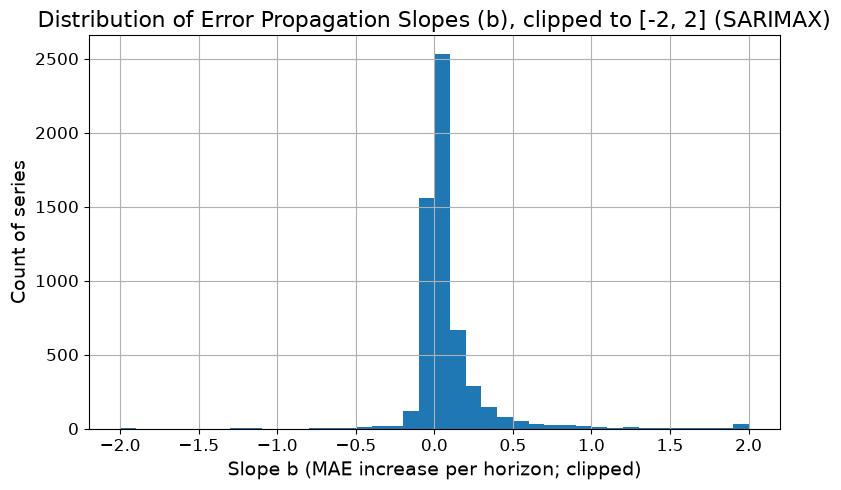

In [14]:
# -------------------------
# Paths
# -------------------------
import os
import time
CSV_PATH = os.path.join(outputs_dir, "validation", "sarimax", "validation_sarimax.csv")  # <-- SARIMAX summary
POI_DIR = os.path.join(outputs_dir, "validation", "sarimax")                             # <-- per-POI CSVs
FIG_DIR = os.path.join(outputs_dir, "validation", "sarimax", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def _timestamp():
    return time.strftime("%Y%m%d-%H%M%S")

def save_and_show(basename):
    plt.tight_layout()
    path = os.path.join(FIG_DIR, f"{basename}.pdf")
    plt.savefig(path, bbox_inches='tight')
    plt.savefig(os.path.join(FIG_DIR, f'{basename}.png'), dpi=150, bbox_inches='tight')
    print(f"[saved] {path}")
    try:
        plt.show()
    except Exception as e:
        print(f"[show skipped] {e}")
    plt.close()

# -------------------------
# Load data
# -------------------------
data = pd.read_csv(CSV_PATH, low_memory=False)

# -------------------------
# Helpers
# -------------------------
def parse_list(s):
    """Safely parse a stringified list; return None on failure."""
    if isinstance(s, list):
        return s
    if isinstance(s, (np.ndarray, tuple)):
        return list(s)
    try:
        from ast import literal_eval
        return list(literal_eval(s))
    except Exception:
        return None

def seq_to_errors(y_true, y_pred, H):
    y_true = np.array(y_true[:H], dtype=float)
    y_pred = np.array(y_pred[:H], dtype=float)
    err = y_true - y_pred
    mae_by_h = np.abs(err)
    rmse_by_h_sq = err**2
    with np.errstate(divide='ignore', invalid='ignore'):
        mape_by_h = np.where(np.abs(y_true) > 1e-12, np.abs(err / y_true) * 100.0, np.nan)
    return mae_by_h, rmse_by_h_sq, mape_by_h

# -------------------------
# Parse predicted and true lists (SARIMAX columns)
# -------------------------
# Preferred: summary CSV already contains 'val_true_list' / 'val_pred_list' (stringified lists)
required_cols = ["val_true_list", "val_pred_list"]
missing = [c for c in required_cols if c not in data.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

data['y_true_seq'] = data['val_true_list'].apply(parse_list)
data['y_pred_seq'] = data['val_pred_list'].apply(parse_list)

# Drop rows with parsing failures or empty sequences
mask_ok = data['y_true_seq'].apply(lambda x: isinstance(x, list) and len(x) > 0) & \
          data['y_pred_seq'].apply(lambda x: isinstance(x, list) and len(x) > 0)
data = data[mask_ok].reset_index(drop=True)

# Ensure sequences are same length per row and compute common horizon H (min length across all)
if len(data) == 0:
    raise ValueError("No valid (true,pred) sequences found. Ensure summary contains lists or per-POI files exist.")

seq_lengths = data.apply(lambda r: min(len(r['y_true_seq']), len(r['y_pred_seq'])), axis=1)
H = int(seq_lengths.min())
# Optional cap to keep comparability with earlier setup
H = min(H, 132)
data['H_common'] = H

print("Number of series:", len(data))
print("Common evaluation horizon H:", H)

# -------------------------
# Horizon-wise errors
# -------------------------
all_mae, all_rmse_sq, all_mape = [], [], []
for _, row in data.iterrows():
    mae_h, rmse_sq_h, mape_h = seq_to_errors(row['y_true_seq'], row['y_pred_seq'], H)
    all_mae.append(mae_h)
    all_rmse_sq.append(rmse_sq_h)
    all_mape.append(mape_h)

all_mae = np.vstack(all_mae)          # shape: (N, H)
all_rmse_sq = np.vstack(all_rmse_sq)  # shape: (N, H)
all_mape = np.vstack(all_mape)        # shape: (N, H)
N = all_mae.shape[0]
horizons = np.arange(1, H + 1)

# -------------------------
# Aggregate by horizon (mean ± SD)
# -------------------------
mean_mae = np.nanmean(all_mae, axis=0)
std_mae  = np.nanstd(all_mae, axis=0, ddof=1)

mean_sq = np.nanmean(all_rmse_sq, axis=0)
std_sq  = np.nanstd(all_rmse_sq, axis=0, ddof=1)
rmse_by_h = np.sqrt(mean_sq)
rmse_lo = np.sqrt(np.clip(mean_sq - std_sq, a_min=0, a_max=None))
rmse_hi = np.sqrt(mean_sq + std_sq)

mean_mape = np.nanmean(all_mape, axis=0)
std_mape  = np.nanstd(all_mape, axis=0, ddof=1)

summary_by_h = pd.DataFrame({
    'h': horizons,
    'mean_MAE': mean_mae,
    'std_MAE': std_mae,
    'RMSE': rmse_by_h,
    'RMSE_lo': rmse_lo,
    'RMSE_hi': rmse_hi,
    'mean_MAPE_percent': mean_mape,
    'std_MAPE_percent': std_mape
})
print("Horizon-wise error propagation summary (mean ± sd)")
print(summary_by_h.head(min(135, H)))

out_summary_csv = os.path.join(outputs_dir, "validation", "sarimax", "sarimax_error_propagation_summary_by_h.csv")
summary_by_h.to_csv(out_summary_csv, index=False)

# -------------------------
# -------------------------
# Per-series linear trend on MAE: MAE(h) ~ a + b*h
# -------------------------
X = horizons.reshape(-1, 1)
slopes = np.empty(N)
intercepts = np.empty(N)

lr = LinearRegression()
for i in range(N):
    y = all_mae[i, :]
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

# Try to preserve an ID column from your CSV
id_col = None
for candidate in ['placekey', 'series', 'series_id', 'poi', 'poi_id']:
    if candidate in data.columns:
        id_col = candidate
        break

per_series_summary = pd.DataFrame({
    'series_index'        : np.arange(N) if id_col is None else data[id_col].values,
    'slope_b_MAE_per_h'   : slopes,
    'intercept_a'         : intercepts,
    'MAE_h1'              : all_mae[:, 0],
    'MAE_hH'              : all_mae[:, -1],
    'EPI_linear_per_h'    : (all_mae[:, -1] - all_mae[:, 0]) / (H if H > 0 else 1),
    'EPI_normalized_ratio': np.divide(all_mae[:, -1], all_mae[:, 0], out=np.full(N, np.nan), where=(all_mae[:, 0] != 0))
})

out_series_csv = os.path.join(outputs_dir, "validation", "sarimax", "sarimax_error_propagation_per_series.csv")
per_series_summary.to_csv(out_series_csv, index=False)

# Merge back to original rows to keep metadata (placekey, naics_code, sarimax_* metrics)
merged = data.copy()
merged['_row_index'] = np.arange(N)
per_series_summary['_row_index'] = np.arange(N)
merged = pd.merge(merged, per_series_summary, on='_row_index', how='left').drop(columns=['_row_index'])
merged_out_csv = os.path.join(outputs_dir, "validation", "sarimax", "sarimax_validation_merged_with_error_slopes.csv")
merged.to_csv(merged_out_csv, index=False)

print("Saved:")
print(out_summary_csv)
print(out_series_csv)
print(merged_out_csv)

# -------------------------
# PLOTS (Histogram of slopes only)
# -------------------------
TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE  = 12
LEGEND_SIZE = 12

slopes_clipped = np.clip(slopes, -2.0, 2.0)
num_clipped_hi = int(np.sum(slopes > 2.0))
num_clipped_lo = int(np.sum(slopes < -2.0))
print(f"Histogram note: {num_clipped_lo} slopes clipped at -2, {num_clipped_hi} slopes clipped at 2.")

plt.figure(figsize=(8, 5))
plt.hist(slopes_clipped, bins=40, range=(-2, 2))
plt.title('Distribution of Error Propagation Slopes (b), clipped to [-2, 2] (SARIMAX)', fontsize=TITLE_SIZE)
plt.xlabel('Slope b (MAE increase per horizon; clipped)', fontsize=LABEL_SIZE)
plt.ylabel('Count of series', fontsize=LABEL_SIZE)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
save_and_show("sarimax_slope_histogram_clipped_-2_to_2")


### TimesFM

In [15]:
# ============================
# TimesFM (GPU), VALIDATION-ONLY (pre-hurricane), single CSV with list columns
# - GPU model (bf16 if supported else fp16 where applicable; TimesFM runs in torch FP32 by default,
#   we keep CUDA checks and high-matmul precision like the official example)
# - CPU inputs (model handles device internally)
# - Robust error logging & safe prediction fallback
# ============================

set_reproducible_seeds(42)
import io
import warnings
import logging
import time
import traceback
from contextlib import redirect_stderr
os.environ.setdefault("TRANSFORMERS_NO_TORCHVISION", "1")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

matplotlib.set_loglevel("ERROR")
warnings.filterwarnings("ignore")
logging.getLogger("matplotlib").setLevel(logging.ERROR)


# ---- CONFIG ----
OUT_SUMMARY_PATH = os.path.join(outputs_dir, "validation", "timesfm", "validation_timesfm.csv")
TIMESFM_MODEL_NAME = os.environ.get("TIMESFM_MODEL_NAME", "google/timesfm-2.5-200m-pytorch")
# kept for API parity; TimesFM returns point + quantiles (not samples). We still accept the env var.
TIMESFM_NUM_SAMPLES = int(os.environ.get("TIMESFM_NUM_SAMPLES", "20"))



# ============================
# Guard: ensure correct package
# ============================
def _assert_correct_timesfm_package():
    try:
        import importlib.metadata as im
        im.version("timesfm")
    except Exception:
        raise ImportError(
            'timesfm not installed.\n'
            'Run:  python -m pip install -U timesfm torch'
        )
_assert_correct_timesfm_package()

# ============================
# TimesFM loader (singleton, forced CUDA check)
# ============================
_timesfm_model = None

def get_timesfm_model():
    """
    Load TimesFM 2.5 (PyTorch) and compile forecast config.
    Fails fast if CUDA is not available (to mirror your Chronos guard).
    """
    global _timesfm_model
    if _timesfm_model is not None:
        return _timesfm_model


    if not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA not available. Install a CUDA-enabled PyTorch build and ensure an NVIDIA GPU is visible."
        )

    # Match official guidance to improve matmul perf on GPU (TimesFM example) :contentReference[oaicite:2]{index=2}
    torch.set_float32_matmul_precision("high")

    # Load model + compile forecast config (quantiles enabled for probabilistic outputs)
    model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(TIMESFM_MODEL_NAME)
    model.compile(
        timesfm.ForecastConfig(
            max_context=1024,           # safe defaults; model supports much longer contexts
            max_horizon=1024,           # allow large H just in case
            normalize_inputs=True,
            use_continuous_quantile_head=True,   # we’ll read median from quantiles if available
            force_flip_invariance=True,
            infer_is_positive=True,
            fix_quantile_crossing=True,
        )
    )
    # Move to CUDA if the wrapper exposes .to(); otherwise internals run on cuda already.
    try:
        model.to("cuda")
    except Exception:
        pass

    print(f"[TimesFM] Loaded {TIMESFM_MODEL_NAME} on GPU "
          f"({torch.cuda.get_device_name(0)}).")
    _timesfm_model = model
    return _timesfm_model

# ============================
# Helpers
# ============================
def _clean_array(x: np.ndarray) -> np.ndarray:
    """Replace non-finite entries with median (or 0.0 if all non-finite)."""
    x = np.asarray(x, dtype=np.float32)
    if np.isfinite(x).all():
        return x
    if np.isfinite(x).any():
        fill = float(np.nanmedian(x[np.isfinite(x)]))
    else:
        fill = 0.0
    return np.nan_to_num(x, nan=fill, posinf=fill, neginf=fill)

def _reduce_timesfm_to_point(point_forecast: np.ndarray,
                             quantile_forecast: np.ndarray | None,
                             H: int) -> np.ndarray:
    """
    Prefer the model's point forecast; if quantiles exist, use the median (P50).
    Ensures shape (H,) and guards non-finite.
    """
    out = None
    if isinstance(point_forecast, np.ndarray):
        # point_forecast expected shape: (1, H)
        out = np.asarray(point_forecast[0], dtype=np.float32) if point_forecast.ndim == 2 else np.asarray(point_forecast, dtype=np.float32)
    if (out is None or not np.isfinite(out).all()) and quantile_forecast is not None:
        # quantile_forecast expected shape: (1, H, K) where K includes mean and 10..90% quantiles (per README). :contentReference[oaicite:3]{index=3}
        q = np.asarray(quantile_forecast)
        # Fallback to the central channel if known; otherwise mean (index 0)
        try:
            # If channels ordered [mean, q10, q20, ..., q90], pick median approx at q50 (index 5)
            median_series = q[0, :, 5]
            out = median_series.astype(np.float32)
        except Exception:
            out = q[0, :, 0].astype(np.float32)  # mean
    if out is None:
        out = np.zeros(H, dtype=np.float32)
    if out.shape[0] != H:
        out = out[:H] if out.shape[0] > H else np.pad(out, (0, H - out.shape[0]), mode="edge")
    return _clean_array(out)

def safe_predict(model, context_np: np.ndarray, H: int, num_samples: int):
    """
    Try multiple input forms (NumPy -> torch CPU tensor -> list) with TimesFM.
    Capture stderr + traceback. Fall back to naive persistence if all fail.
    Returns np.ndarray of shape (H,) and a diagnostics dict.
    """
    attempts = []
    diag = {"ok": False, "attempts": []}

    # TimesFM expects a list of 1D series; it returns (point, quantiles).
    def _call_forecast(inp):
        point, quants = model.forecast(horizon=H, inputs=[inp])
        return _reduce_timesfm_to_point(point, quants, H)

    # 1) NumPy
    try:
        with io.StringIO() as errbuf, redirect_stderr(errbuf):
            pred = _call_forecast(context_np.astype(np.float32))
            stderr = errbuf.getvalue()
        attempts.append(("numpy", None if stderr == "" else stderr))
        diag["attempts"].append(("numpy", stderr[:500]))
        return pred, {**diag, "ok": True}
    except Exception:
        attempts.append(("numpy", traceback.format_exc()))
        diag["attempts"].append(("numpy", traceback.format_exc()[:500]))

    # 2) torch tensor (CPU)
    try:
        ctx_t = torch.tensor(context_np, dtype=torch.float32)  # CPU tensor
        with io.StringIO() as errbuf, redirect_stderr(errbuf):
            pred = _call_forecast(ctx_t.cpu().numpy())
            stderr = errbuf.getvalue()
        attempts.append(("torch_cpu", None if stderr == "" else stderr))
        diag["attempts"].append(("torch_cpu", stderr[:500]))
        return pred, {**diag, "ok": True}
    except Exception:
        attempts.append(("torch_cpu", traceback.format_exc()))
        diag["attempts"].append(("torch_cpu", traceback.format_exc()[:500]))

    # 3) Python list
    try:
        ctx_l = context_np.astype(np.float32).tolist()
        with io.StringIO() as errbuf, redirect_stderr(errbuf):
            pred = _call_forecast(np.array(ctx_l, dtype=np.float32))
            stderr = errbuf.getvalue()
        attempts.append(("list", None if stderr == "" else stderr))
        diag["attempts"].append(("list", stderr[:500]))
        return pred, {**diag, "ok": True}
    except Exception:
        attempts.append(("list", traceback.format_exc()))
        diag["attempts"].append(("list", traceback.format_exc()[:500]))

    # Fallback: naive last value
    last_val = float(context_np[-1]) if context_np.size else 0.0
    print("[WARN] TimesFM prediction failed on all attempts. Using naive persistence.")
    for name, info in attempts:
        print(f"  attempt={name} -> {str(info).splitlines()[0] if info else 'no-stderr'}")
    return np.full(H, last_val, dtype=float), {**diag, "ok": False}

# ============================
# SINGLE-POI PROCESSOR (GPU model, CPU inputs)
# ============================
def process_single_poi_full_scale(poi_data):
    """
    - Validation window: H days immediately before hurricane_date (H = post-hurricane length)
    - Context (train) = data strictly before validation
    - Model runs on GPU; inputs remain on CPU (TimesFM handles device internally)
    - Returns metrics + list columns
    Assumes `compute_metrics(y_true, y_pred)` exists in your env.
    """
    try:
        errcap = io.StringIO()
        with warnings.catch_warnings(), redirect_stderr(errcap):
            warnings.simplefilter("ignore")

            # --- dates ---
            date_range = pd.date_range(start="2023-05-01", end="2025-02-02")
            hurricane_date = pd.to_datetime("2024-09-23")

            # --- series ---
            placekey = poi_data["placekey"]
            visits_list = poi_data["visits_list"]
            series = pd.Series(visits_list, index=date_range).astype(float)

            # Horizon = post-hurricane length
            test = series[series.index >= hurricane_date]
            H = len(test)
            if H == 0:
                return None

            # Validation window: last H days before hurricane
            val_end = hurricane_date - pd.Timedelta(days=1)
            val_start = val_end - pd.Timedelta(days=H - 1)
            validation = series[(series.index >= val_start) & (series.index <= val_end)]

            # Context strictly before validation
            train = series[series.index < val_start]
            if len(train) < 10:
                return None

            # Clean/guard non-finite
            train_arr = _clean_array(train.values)

            # --- TimesFM prediction (inputs on CPU) ---
            model = get_timesfm_model()
            preds, diag = safe_predict(model, train_arr, H, TIMESFM_NUM_SAMPLES)

            # --- Metrics on VALIDATION window ---
            preds = _clean_array(preds)
            y_true = _clean_array(validation.values)
            c_mae, c_rmse, c_r2, c_auc_pos, c_auc_neg, c_auc_total = compute_metrics(
                y_true, preds
            )

            return {
                "placekey": placekey,
                "latitude": poi_data.get("latitude"),
                "longitude": poi_data.get("longitude"),
                "naics_code": poi_data.get("naics_code"),
                "city": poi_data.get("city"),
                "region": poi_data.get("region"),
                "GEOID": poi_data.get("GEOID"),
                "County": poi_data.get("county"),
                "mean_per_day": poi_data.get("mean_per_day"),
                "mean_before_hurricane": poi_data.get("mean_before_hurricane"),
                "mean_after_hurricane": poi_data.get("mean_after_hurricane"),

                "timesfm_mae": c_mae,
                "timesfm_rmse": c_rmse,
                "timesfm_r2": c_r2,
                "timesfm_auc_pos": c_auc_pos,
                "timesfm_auc_neg": c_auc_neg,
                "timesfm_auc_total": c_auc_total,

                "val_dates": [d.strftime("%Y-%m-%d") for d in validation.index.tolist()],
                "val_true_list": y_true.tolist(),
                "val_pred_list": preds.tolist(),

                # optional debug hooks (stringify to survive CSV)
                "timesfm_ok": diag.get("ok", False),
            }

    except Exception as e:
        # Print full traceback + any captured stderr (even if message is empty)
        tb = traceback.format_exc()
        print(f"ERROR processing POI {poi_data.get('placekey', 'unknown')}: {repr(e)}")
        print(tb.splitlines()[-3] if tb else "no-traceback")
        return None

# ============================
# FULL-SCALE DRIVER
# ============================

def run_full_scale_processing():
    print(f"=== VALIDATION-ONLY (TimesFM GPU) PROCESSING - {len(df_filtered)} POIs ===")
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
    print(f"Model: {TIMESFM_MODEL_NAME}")
    print(f"Starting at: {pd.Timestamp.now()}")

    # ensure model is loaded on GPU
    _ = get_timesfm_model()

    poi_list = df_filtered.to_dict("records")

    start_time = time.time()
    results = [process_single_poi_full_scale(p) for p in tqdm(poi_list, desc="Processing all POIs (validation-only)")]

    summary_rows = [r for r in results if r is not None]
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(OUT_SUMMARY_PATH, index=False)

    elapsed = time.time() - start_time
    print("\n=== PROCESSING COMPLETE ===")
    print(f"Total time: {elapsed/60:.1f} minutes ({elapsed:.0f} seconds)")
    print(f"Successfully processed: {len(summary_rows)}/{len(poi_list)} "
          f"({(len(summary_rows)/len(poi_list)*100 if poi_list else 0):.1f}%)")
    print(f"Results saved to: {OUT_SUMMARY_PATH}")

    return summary_df

 
# ============================
# Execute
# ============================
import os
if os.path.exists(OUT_SUMMARY_PATH) and os.path.getsize(OUT_SUMMARY_PATH) > 10:
    print(f"✅ [SKIP] Validation output already exists at: {OUT_SUMMARY_PATH}")
    print("Loading existing results into final_summary_df...")
    final_summary_df = pd.read_csv(OUT_SUMMARY_PATH)
else:
    print("🚀 Starting validation-only (TimesFM, GPU) processing...")
    final_summary_df = run_full_scale_processing()


🚀 Starting validation-only (TimesFM, GPU) processing...
=== VALIDATION-ONLY (TimesFM GPU) PROCESSING - 5671 POIs ===
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU
Model: google/timesfm-2.5-200m-pytorch
Starting at: 2026-07-01 00:11:13.863408
[TimesFM] Loaded google/timesfm-2.5-200m-pytorch on GPU (NVIDIA GeForce RTX 4060 Laptop GPU).


Processing all POIs (validation-only): 100%|██████████| 5671/5671 [1:50:54<00:00,  1.17s/it]  



=== PROCESSING COMPLETE ===
Total time: 110.9 minutes (6655 seconds)
Successfully processed: 5671/5671 (100.0%)
Results saved to: results_2026-06-30_23-59-42\validation\timesfm\validation_timesfm.csv


Number of series: 5671
Common evaluation horizon H: 132
Horizon-wise error propagation summary (mean ± sd)
       h   mean_MAE    std_MAE       RMSE  RMSE_lo     RMSE_hi  \
0      1  18.399727  35.541700  40.019241      0.0  164.913479   
1      2  16.407550  32.581329  36.476890      0.0  143.269722   
2      3  18.552289  36.007226  40.502828      0.0  147.924785   
3      4  16.487765  39.705316  42.989307      0.0  184.106293   
4      5  18.320152  39.018294  43.102051      0.0  152.286478   
..   ...        ...        ...        ...      ...         ...   
127  128  17.916475  30.636313  35.488283      0.0  101.333683   
128  129  18.025242  33.151375  37.732337      0.0  120.824904   
129  130  18.229923  36.448058  40.749930      0.0  164.715917   
130  131  20.652844  42.092881  46.883239      0.0  169.697102   
131  132  19.790250  52.983840  56.554808      0.0  291.210122   

     mean_MAPE_percent  std_MAPE_percent  
0            26.127885         54.407604  
1            2

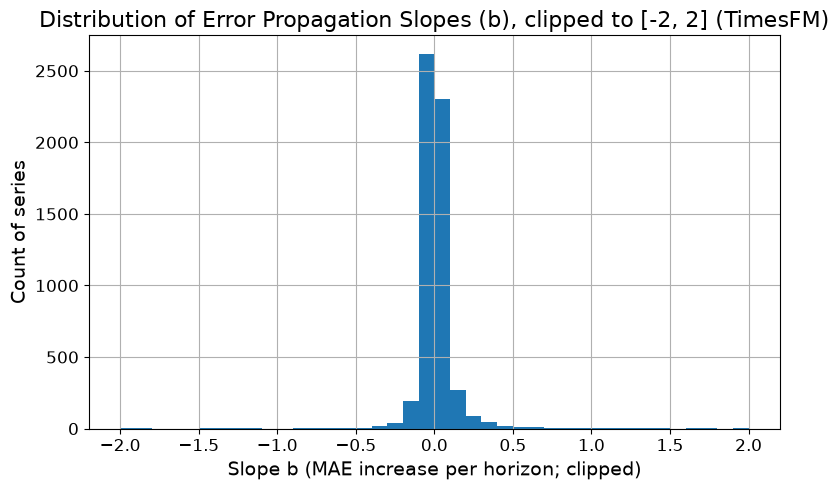

In [16]:
# ============================================
# TimesFM validation results: error propagation + clustering
# ============================================

# -------------------------
# Paths
# -------------------------
import os
import time
CSV_PATH = os.path.join(outputs_dir, "validation", "timesfm", "validation_timesfm.csv")  # <-- your TimesFM output
FIG_DIR = os.path.join(outputs_dir, "validation", "timesfm", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def _timestamp():
    return time.strftime("%Y%m%d-%H%M%S")

def save_and_show(basename):
    plt.tight_layout()
    path = os.path.join(FIG_DIR, f"{basename}.pdf")
    plt.savefig(path, bbox_inches='tight')
    plt.savefig(os.path.join(FIG_DIR, f'{basename}.png'), dpi=150, bbox_inches='tight')
    print(f"[saved] {path}")
    try:
        plt.show()
    except Exception as e:
        print(f"[show skipped] {e}")
    plt.close()

# -------------------------
# Load data
# -------------------------
data = pd.read_csv(CSV_PATH, low_memory=False)

# -------------------------
# Helpers
# -------------------------
def parse_list(s):
    """Safely parse a stringified list; return None on failure."""
    if isinstance(s, list):
        return s
    if isinstance(s, (np.ndarray, tuple)):
        return list(s)
    try:
        from ast import literal_eval
        return list(literal_eval(s))
    except Exception:
        return None

def seq_to_errors(y_true, y_pred, H):
    y_true = np.array(y_true[:H], dtype=float)
    y_pred = np.array(y_pred[:H], dtype=float)
    err = y_true - y_pred
    mae_by_h = np.abs(err)
    rmse_by_h_sq = err**2
    with np.errstate(divide='ignore', invalid='ignore'):
        mape_by_h = np.where(np.abs(y_true) > 1e-12, np.abs(err / y_true) * 100.0, np.nan)
    return mae_by_h, rmse_by_h_sq, mape_by_h

# -------------------------
# Parse predicted and true lists (TimesFM columns)
# -------------------------
# Your TimesFM code saves:
#   'val_true_list', 'val_pred_list', 'val_dates', 'timesfm_* metrics', plus POI meta (placekey, naics_code, etc.)
required_cols = ["val_true_list", "val_pred_list"]
missing = [c for c in required_cols if c not in data.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

data['y_true_seq'] = data['val_true_list'].apply(parse_list)
data['y_pred_seq'] = data['val_pred_list'].apply(parse_list)

# Drop rows with parsing failures or empty sequences
data = data.dropna(subset=['y_true_seq', 'y_pred_seq']).reset_index(drop=True)
data = data[[len(t) > 0 and len(p) > 0 for t, p in zip(data['y_true_seq'], data['y_pred_seq'])]].reset_index(drop=True)

# Ensure sequences are same length per row and compute common horizon H (min length across all)
seq_lengths = data.apply(lambda r: min(len(r['y_true_seq']), len(r['y_pred_seq'])), axis=1)
if len(seq_lengths) == 0:
    raise ValueError("No valid (true,pred) sequences found after parsing.")
H = int(seq_lengths.min())

# Optional cap (keeps comparisons aligned with your earlier setup)
H = min(H, 132)
data['H_common'] = H

print("Number of series:", len(data))
print("Common evaluation horizon H:", H)

# -------------------------
# Horizon-wise errors
# -------------------------
all_mae, all_rmse_sq, all_mape = [], [], []
for _, row in data.iterrows():
    mae_h, rmse_sq_h, mape_h = seq_to_errors(row['y_true_seq'], row['y_pred_seq'], H)
    all_mae.append(mae_h)
    all_rmse_sq.append(rmse_sq_h)
    all_mape.append(mape_h)

all_mae = np.vstack(all_mae)          # shape: (N, H)
all_rmse_sq = np.vstack(all_rmse_sq)  # shape: (N, H)
all_mape = np.vstack(all_mape)        # shape: (N, H)
N = all_mae.shape[0]
horizons = np.arange(1, H + 1)

# -------------------------
# Aggregate by horizon (mean ± SD)
# RMSE via squared errors; SD ribbon mapped via sqrt of mean±SD of squared errors
# -------------------------
mean_mae = np.nanmean(all_mae, axis=0)
std_mae  = np.nanstd(all_mae, axis=0, ddof=1)

mean_sq = np.nanmean(all_rmse_sq, axis=0)
std_sq  = np.nanstd(all_rmse_sq, axis=0, ddof=1)
rmse_by_h = np.sqrt(mean_sq)
rmse_lo = np.sqrt(np.clip(mean_sq - std_sq, a_min=0, a_max=None))
rmse_hi = np.sqrt(mean_sq + std_sq)

mean_mape = np.nanmean(all_mape, axis=0)
std_mape  = np.nanstd(all_mape, axis=0, ddof=1)

summary_by_h = pd.DataFrame({
    'h': horizons,
    'mean_MAE': mean_mae,
    'std_MAE': std_mae,
    'RMSE': rmse_by_h,
    'RMSE_lo': rmse_lo,
    'RMSE_hi': rmse_hi,
    'mean_MAPE_percent': mean_mape,
    'std_MAPE_percent': std_mape
})
print("Horizon-wise error propagation summary (mean ± sd)")
print(summary_by_h.head(min(135, H)))

out_summary_csv = os.path.join(outputs_dir, "validation", "timesfm", "timesfm_error_propagation_summary_by_h.csv")
summary_by_h.to_csv(out_summary_csv, index=False)

# -------------------------
# -------------------------
# Per-series linear trend on MAE: MAE(h) ~ a + b*h
# -------------------------
X = horizons.reshape(-1, 1)
slopes = np.empty(N)
intercepts = np.empty(N)

lr = LinearRegression()
for i in range(N):
    y = all_mae[i, :]
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

# Try to preserve an ID column from your CSV
id_col = None
for candidate in ['placekey', 'series', 'series_id', 'poi', 'poi_id']:
    if candidate in data.columns:
        id_col = candidate
        break

per_series_summary = pd.DataFrame({
    'series_index'        : np.arange(N) if id_col is None else data[id_col].values,
    'slope_b_MAE_per_h'   : slopes,
    'intercept_a'         : intercepts,
    'MAE_h1'              : all_mae[:, 0],
    'MAE_hH'              : all_mae[:, -1],
    'EPI_linear_per_h'    : (all_mae[:, -1] - all_mae[:, 0]) / (H if H > 0 else 1),
    'EPI_normalized_ratio': np.divide(all_mae[:, -1], all_mae[:, 0], out=np.full(N, np.nan), where=(all_mae[:, 0] != 0))
})

out_series_csv = os.path.join(outputs_dir, "validation", "timesfm", "timesfm_error_propagation_per_series.csv")
per_series_summary.to_csv(out_series_csv, index=False)

# Also merge back to original rows to keep metadata (placekey, naics_code, timesfm_* metrics)
merged = data.copy()
merged['_row_index'] = np.arange(N)
per_series_summary['_row_index'] = np.arange(N)
merged = pd.merge(merged, per_series_summary, on='_row_index', how='left').drop(columns=['_row_index'])
merged_out_csv = os.path.join(outputs_dir, "validation", "timesfm", "timesfm_validation_merged_with_error_slopes.csv")
merged.to_csv(merged_out_csv, index=False)

print("Saved:")
print(out_summary_csv)
print(out_series_csv)
print(merged_out_csv)

# -------------------------
# PLOTS (Histogram of slopes only)
# -------------------------
TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE  = 12
LEGEND_SIZE = 12

slopes_clipped = np.clip(slopes, -2.0, 2.0)
num_clipped_hi = int(np.sum(slopes > 2.0))
num_clipped_lo = int(np.sum(slopes < -2.0))
print(f"Histogram note: {num_clipped_lo} slopes clipped at -2, {num_clipped_hi} slopes clipped at 2.")

plt.figure(figsize=(8, 5))
plt.hist(slopes_clipped, bins=40, range=(-2, 2))
plt.title('Distribution of Error Propagation Slopes (b), clipped to [-2, 2] (TimesFM)', fontsize=TITLE_SIZE)
plt.xlabel('Slope b (MAE increase per horizon; clipped)', fontsize=LABEL_SIZE)
plt.ylabel('Count of series', fontsize=LABEL_SIZE)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
save_and_show("timesfm_slope_histogram_clipped_-2_to_2")


### Chronos 

In [17]:
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))


cuda available: True
device: NVIDIA GeForce RTX 4060 Laptop GPU


In [18]:
# ============================
# Chronos-T5 (GPU), VALIDATION-ONLY (pre-hurricane), single CSV with list columns
# - GPU model (bf16 if supported else fp16)
# - CPU inputs (Chronos moves them internally)
# - Robust error logging & safe prediction fallback
# ============================

set_reproducible_seeds(42)
import io
import warnings
import logging
import time
import traceback
from contextlib import redirect_stderr
os.environ.setdefault("TRANSFORMERS_NO_TORCHVISION", "1")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

matplotlib.set_loglevel("ERROR")
warnings.filterwarnings("ignore")
logging.getLogger("matplotlib").setLevel(logging.ERROR)

# ---- CONFIG ----
OUT_SUMMARY_PATH = os.path.join(outputs_dir, "validation", "chronos", "validation_chronos.csv")
CHRONOS_MODEL_NAME = os.environ.get("CHRONOS_MODEL_NAME", "amazon/chronos-t5-large")
CHRONOS_NUM_SAMPLES = int(os.environ.get("CHRONOS_NUM_SAMPLES", "20"))



# ============================
# Guard: ensure correct package
# ============================
def _assert_correct_chronos_package():
    try:
        import importlib.metadata as im
        im.version("chronos-forecasting")
    except Exception:
        raise ImportError(
            'chronos-forecasting not installed.\n'
            'Run:  python -m pip install -U chronos-forecasting "transformers>=4.43,<5"'
        )
_assert_correct_chronos_package()

# ============================
# Chronos pipeline loader (singleton, forced CUDA)
# ============================
_chronos_pipe = None
_pipe_dtype = None

def get_chronos_pipeline():
    """
    Load Chronos-T5 on GPU in half precision (bf16 if supported else fp16).
    Fails fast if CUDA is not available.
    """
    global _chronos_pipe, _pipe_dtype
    if _chronos_pipe is not None:
        return _chronos_pipe


    if not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA not available. Install a CUDA-enabled PyTorch build and ensure an NVIDIA GPU is visible."
        )

    torch_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    _pipe_dtype = torch_dtype

    _chronos_pipe = ChronosPipeline.from_pretrained(
        CHRONOS_MODEL_NAME,
        device_map="cuda",
        torch_dtype=torch_dtype,
    )
    print(f"[Chronos] Loaded {CHRONOS_MODEL_NAME} on GPU "
          f"({torch.cuda.get_device_name(0)}, dtype={torch_dtype}).")
    return _chronos_pipe

# ============================
# Helpers
# ============================
def _clean_array(x: np.ndarray) -> np.ndarray:
    """Replace non-finite entries with median (or 0.0 if all non-finite)."""
    x = np.asarray(x, dtype=np.float32)
    if np.isfinite(x).all():
        return x
    if np.isfinite(x).any():
        fill = float(np.nanmedian(x[np.isfinite(x)]))
    else:
        fill = 0.0
    return np.nan_to_num(x, nan=fill, posinf=fill, neginf=fill)

def safe_predict(pipe, context_np: np.ndarray, H: int, num_samples: int):
    """
    Try multiple input forms (NumPy -> torch CPU tensor -> list).
    Capture stderr + traceback. Fall back to naive persistence if all fail.
    Returns np.ndarray of shape (H,) and a diagnostics dict.
    """

    attempts = []
    diag = {"ok": False, "attempts": []}

    # 1) NumPy (CPU)
    try:
        with io.StringIO() as errbuf, redirect_stderr(errbuf):
            pred = pipe.predict(context_np, prediction_length=H, num_samples=num_samples)
            stderr = errbuf.getvalue()
        attempts.append(("numpy", None if stderr == "" else stderr))
        diag["attempts"].append(("numpy", stderr[:500]))
        return _reduce_samples_to_point(pred, H), {**diag, "ok": True}
    except Exception:
        attempts.append(("numpy", traceback.format_exc()))
        diag["attempts"].append(("numpy", traceback.format_exc()[:500]))

    # 2) torch tensor (CPU)
    try:
        ctx_t = torch.tensor(context_np, dtype=torch.float32)  # CPU tensor
        with io.StringIO() as errbuf, redirect_stderr(errbuf):
            pred = pipe.predict(ctx_t, prediction_length=H, num_samples=num_samples)
            stderr = errbuf.getvalue()
        attempts.append(("torch_cpu", None if stderr == "" else stderr))
        diag["attempts"].append(("torch_cpu", stderr[:500]))
        return _reduce_samples_to_point(pred, H), {**diag, "ok": True}
    except Exception:
        attempts.append(("torch_cpu", traceback.format_exc()))
        diag["attempts"].append(("torch_cpu", traceback.format_exc()[:500]))

    # 3) Python list
    try:
        ctx_l = context_np.tolist()
        with io.StringIO() as errbuf, redirect_stderr(errbuf):
            pred = pipe.predict(ctx_l, prediction_length=H, num_samples=num_samples)
            stderr = errbuf.getvalue()
        attempts.append(("list", None if stderr == "" else stderr))
        diag["attempts"].append(("list", stderr[:500]))
        return _reduce_samples_to_point(pred, H), {**diag, "ok": True}
    except Exception:
        attempts.append(("list", traceback.format_exc()))
        diag["attempts"].append(("list", traceback.format_exc()[:500]))

    # Fallback: naive last value
    last_val = float(context_np[-1]) if context_np.size else 0.0
    print("[WARN] Chronos prediction failed on all attempts. Using naive persistence.")
    for name, info in attempts:
        print(f"  attempt={name} -> {str(info).splitlines()[0] if info else 'no-stderr'}")
    return np.full(H, last_val, dtype=float), {**diag, "ok": False}

def _reduce_samples_to_point(pred, H: int) -> np.ndarray:
    """Reduce [num_series, num_samples, H] to (H,) via median over samples."""
    if isinstance(pred, torch.Tensor):
        arr = pred[0].detach().cpu().numpy()
    else:
        arr = np.array(pred[0])
    if arr.ndim == 2:
        out = np.median(arr, axis=0)
    elif arr.ndim == 1:
        out = arr
    else:
        out = np.asarray(arr).reshape(-1)[:H]
    if out.shape[0] != H:
        out = out[:H] if out.shape[0] > H else np.pad(out, (0, H - out.shape[0]), mode="edge")
    # guard non-finite
    return _clean_array(out)

# ============================
# SINGLE-POI PROCESSOR (GPU model, CPU inputs)
# ============================
def process_single_poi_full_scale(poi_data):
    """
    - Validation window: H days immediately before hurricane_date (H = post-hurricane length)
    - Context (train) = data strictly before validation
    - Model runs on GPU; inputs remain on CPU (Chronos moves them internally)
    - Returns metrics + list columns
    Assumes `compute_metrics(y_true, y_pred)` exists in your env.
    """
    try:
        errcap = io.StringIO()
        with warnings.catch_warnings(), redirect_stderr(errcap):
            warnings.simplefilter("ignore")

            # --- dates ---
            date_range = pd.date_range(start="2023-05-01", end="2025-02-02")
            hurricane_date = pd.to_datetime("2024-09-23")

            # --- series ---
            placekey = poi_data["placekey"]
            visits_list = poi_data["visits_list"]
            series = pd.Series(visits_list, index=date_range).astype(float)

            # Horizon = post-hurricane length
            test = series[series.index >= hurricane_date]
            H = len(test)
            if H == 0:
                return None

            # Validation window: last H days before hurricane
            val_end = hurricane_date - pd.Timedelta(days=1)
            val_start = val_end - pd.Timedelta(days=H - 1)
            validation = series[(series.index >= val_start) & (series.index <= val_end)]

            # Context strictly before validation
            train = series[series.index < val_start]
            if len(train) < 10:
                return None

            # Clean/guard non-finite
            train_arr = _clean_array(train.values)

            # --- Chronos-T5 prediction (inputs on CPU) ---
            pipe = get_chronos_pipeline()
            preds, diag = safe_predict(pipe, train_arr, H, CHRONOS_NUM_SAMPLES)

            # --- Metrics on VALIDATION window ---
            preds = _clean_array(preds)
            y_true = _clean_array(validation.values)
            c_mae, c_rmse, c_r2, c_auc_pos, c_auc_neg, c_auc_total = compute_metrics(
                y_true, preds
            )

            return {
                "placekey": placekey,
                "latitude": poi_data.get("latitude"),
                "longitude": poi_data.get("longitude"),
                "naics_code": poi_data.get("naics_code"),
                "city": poi_data.get("city"),
                "region": poi_data.get("region"),
                "GEOID": poi_data.get("GEOID"),
                "County": poi_data.get("county"),
                "mean_per_day": poi_data.get("mean_per_day"),
                "mean_before_hurricane": poi_data.get("mean_before_hurricane"),
                "mean_after_hurricane": poi_data.get("mean_after_hurricane"),

                "chronos_mae": c_mae,
                "chronos_rmse": c_rmse,
                "chronos_r2": c_r2,
                "chronos_auc_pos": c_auc_pos,
                "chronos_auc_neg": c_auc_neg,
                "chronos_auc_total": c_auc_total,

                "val_dates": [d.strftime("%Y-%m-%d") for d in validation.index.tolist()],
                "val_true_list": y_true.tolist(),
                "val_pred_list": preds.tolist(),

                # optional debug hooks (stringify to survive CSV)
                "chronos_ok": diag.get("ok", False),
            }

    except Exception as e:
        # Print full traceback + any captured stderr (even if message is empty)
        tb = traceback.format_exc()
        print(f"ERROR processing POI {poi_data.get('placekey', 'unknown')}: {repr(e)}")
        print(tb.splitlines()[-3] if tb else "no-traceback")
        return None

# ============================
# FULL-SCALE DRIVER
# ============================

def run_full_scale_processing():
    print(f"=== VALIDATION-ONLY (Chronos-T5 GPU) PROCESSING - {len(df_filtered)} POIs ===")
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
    print(f"Model: {CHRONOS_MODEL_NAME}")
    print(f"Starting at: {pd.Timestamp.now()}")

    # ensure model is loaded on GPU
    _ = get_chronos_pipeline()

    poi_list = df_filtered.to_dict("records")

    start_time = time.time()
    results = [process_single_poi_full_scale(p) for p in tqdm(poi_list, desc="Processing all POIs (validation-only)")]

    summary_rows = [r for r in results if r is not None]
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(OUT_SUMMARY_PATH, index=False)

    elapsed = time.time() - start_time
    print("\n=== PROCESSING COMPLETE ===")
    print(f"Total time: {elapsed/60:.1f} minutes ({elapsed:.0f} seconds)")
    print(f"Successfully processed: {len(summary_rows)}/{len(poi_list)} "
          f"({(len(summary_rows)/len(poi_list)*100 if poi_list else 0):.1f}%)")
    print(f"Results saved to: {OUT_SUMMARY_PATH}")

    return summary_df

 
# ============================
# Execute
# ============================
import os
if os.path.exists(OUT_SUMMARY_PATH) and os.path.getsize(OUT_SUMMARY_PATH) > 10:
    print(f"✅ [SKIP] Validation output already exists at: {OUT_SUMMARY_PATH}")
    print("Loading existing results into final_summary_df...")
    final_summary_df = pd.read_csv(OUT_SUMMARY_PATH)
else:
    print("🚀 Starting validation-only (Chronos-T5, GPU) processing...")
    final_summary_df = run_full_scale_processing()


🚀 Starting validation-only (Chronos-T5, GPU) processing...
=== VALIDATION-ONLY (Chronos-T5 GPU) PROCESSING - 5671 POIs ===
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU
Model: amazon/chronos-t5-large
Starting at: 2026-07-01 02:02:17.807824


`torch_dtype` is deprecated! Use `dtype` instead!


[Chronos] Loaded amazon/chronos-t5-large on GPU (NVIDIA GeForce RTX 4060 Laptop GPU, dtype=torch.bfloat16).


Processing all POIs (validation-only): 100%|██████████| 5671/5671 [7:26:14<00:00,  4.72s/it]



=== PROCESSING COMPLETE ===
Total time: 446.3 minutes (26776 seconds)
Successfully processed: 5671/5671 (100.0%)
Results saved to: results_2026-06-30_23-59-42\validation\chronos\validation_chronos.csv


Number of series: 5671
Common evaluation horizon H: 132
Horizon-wise error propagation summary (mean ± sd)
       h   mean_MAE    std_MAE       RMSE  RMSE_lo     RMSE_hi  \
0      1  19.130896  40.833143  45.089275      0.0  194.539064   
1      2  16.554904  38.345996  41.763872      0.0  209.774609   
2      3  18.685720  43.428796  47.274559      0.0  219.858709   
3      4  17.125642  51.920054  54.667213      0.0  266.089728   
4      5  18.913107  50.236667  53.674792      0.0  254.570937   
..   ...        ...        ...        ...      ...         ...   
127  128  20.634208  49.174296  53.324061      0.0  247.409958   
128  129  20.737139  50.273116  54.378024      0.0  248.116644   
129  130  21.518042  56.303387  60.270544      0.0  274.811327   
130  131  22.397749  54.604042  59.014700      0.0  253.785430   
131  132  21.109512  63.866471  67.259337      0.0  337.648739   

     mean_MAPE_percent  std_MAPE_percent  
0            26.150882         56.895733  
1            2

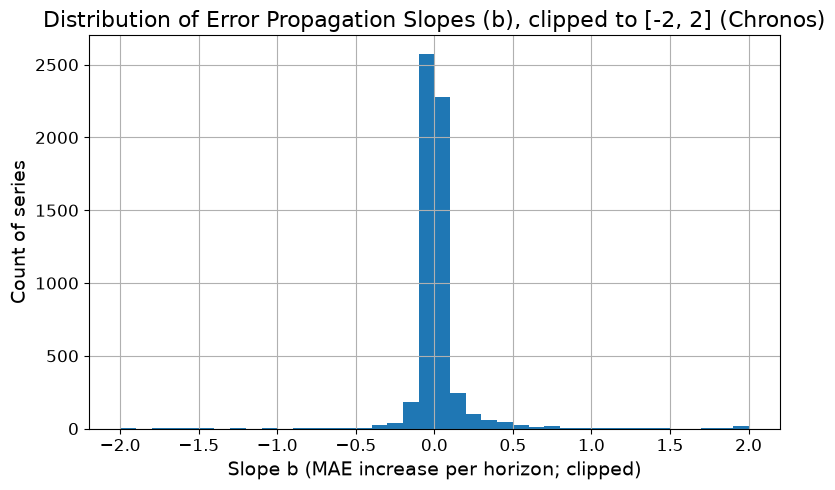

In [19]:
# ============================================
# Chronos-T5 validation results: error propagation + clustering
# ============================================


# -------------------------
# Paths
# -------------------------
import os
import time
CSV_PATH = os.path.join(outputs_dir, "validation", "chronos", "validation_chronos.csv")  # <-- your Chronos output
FIG_DIR = os.path.join(outputs_dir, "validation", "chronos", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def _timestamp():
    return time.strftime("%Y%m%d-%H%M%S")

def save_and_show(basename):
    plt.tight_layout()
    path = os.path.join(FIG_DIR, f"{basename}.pdf")
    plt.savefig(path, bbox_inches='tight')
    plt.savefig(os.path.join(FIG_DIR, f'{basename}.png'), dpi=150, bbox_inches='tight')
    print(f"[saved] {path}")
    try:
        plt.show()
    except Exception as e:
        print(f"[show skipped] {e}")
    plt.close()

# -------------------------
# Load data
# -------------------------
data = pd.read_csv(CSV_PATH, low_memory=False)

# -------------------------
# Helpers
# -------------------------
def parse_list(s):
    """Safely parse a stringified list; return None on failure."""
    if isinstance(s, list):
        return s
    if isinstance(s, (np.ndarray, tuple)):
        return list(s)
    try:
        from ast import literal_eval
        return list(literal_eval(s))
    except Exception:
        return None

def seq_to_errors(y_true, y_pred, H):
    y_true = np.array(y_true[:H], dtype=float)
    y_pred = np.array(y_pred[:H], dtype=float)
    err = y_true - y_pred
    mae_by_h = np.abs(err)
    rmse_by_h_sq = err**2
    with np.errstate(divide='ignore', invalid='ignore'):
        mape_by_h = np.where(np.abs(y_true) > 1e-12, np.abs(err / y_true) * 100.0, np.nan)
    return mae_by_h, rmse_by_h_sq, mape_by_h

# -------------------------
# Parse predicted and true lists (Chronos columns)
# -------------------------
# Your Chronos code saves these columns:
#   'val_true_list', 'val_pred_list', 'val_dates', 'chronos_* metrics', plus POI meta (placekey, naics_code, etc.)
required_cols = ["val_true_list", "val_pred_list"]
missing = [c for c in required_cols if c not in data.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

data['y_true_seq'] = data['val_true_list'].apply(parse_list)
data['y_pred_seq'] = data['val_pred_list'].apply(parse_list)

# Drop rows with parsing failures or empty sequences
data = data.dropna(subset=['y_true_seq', 'y_pred_seq']).reset_index(drop=True)
data = data[[len(t) > 0 and len(p) > 0 for t, p in zip(data['y_true_seq'], data['y_pred_seq'])]].reset_index(drop=True)

# Ensure sequences are same length per row and compute common horizon H (min length across all)
seq_lengths = data.apply(lambda r: min(len(r['y_true_seq']), len(r['y_pred_seq'])), axis=1)
if len(seq_lengths) == 0:
    raise ValueError("No valid (true,pred) sequences found after parsing.")
H = int(seq_lengths.min())

# Optional cap (keeps comparisons aligned with your earlier setup)
H = min(H, 132)
data['H_common'] = H

print("Number of series:", len(data))
print("Common evaluation horizon H:", H)

# -------------------------
# Horizon-wise errors
# -------------------------
all_mae, all_rmse_sq, all_mape = [], [], []
for _, row in data.iterrows():
    mae_h, rmse_sq_h, mape_h = seq_to_errors(row['y_true_seq'], row['y_pred_seq'], H)
    all_mae.append(mae_h)
    all_rmse_sq.append(rmse_sq_h)
    all_mape.append(mape_h)

all_mae = np.vstack(all_mae)          # shape: (N, H)
all_rmse_sq = np.vstack(all_rmse_sq)  # shape: (N, H)
all_mape = np.vstack(all_mape)        # shape: (N, H)
N = all_mae.shape[0]
horizons = np.arange(1, H + 1)

# -------------------------
# Aggregate by horizon (mean ± SD)
# RMSE via squared errors; SD ribbon mapped via sqrt of mean±SD of squared errors
# -------------------------
mean_mae = np.nanmean(all_mae, axis=0)
std_mae  = np.nanstd(all_mae, axis=0, ddof=1)

mean_sq = np.nanmean(all_rmse_sq, axis=0)
std_sq  = np.nanstd(all_rmse_sq, axis=0, ddof=1)
rmse_by_h = np.sqrt(mean_sq)
rmse_lo = np.sqrt(np.clip(mean_sq - std_sq, a_min=0, a_max=None))
rmse_hi = np.sqrt(mean_sq + std_sq)

mean_mape = np.nanmean(all_mape, axis=0)
std_mape  = np.nanstd(all_mape, axis=0, ddof=1)

summary_by_h = pd.DataFrame({
    'h': horizons,
    'mean_MAE': mean_mae,
    'std_MAE': std_mae,
    'RMSE': rmse_by_h,
    'RMSE_lo': rmse_lo,
    'RMSE_hi': rmse_hi,
    'mean_MAPE_percent': mean_mape,
    'std_MAPE_percent': std_mape
})
print("Horizon-wise error propagation summary (mean ± sd)")
print(summary_by_h.head(min(135, H)))

out_summary_csv = os.path.join(outputs_dir, "validation", "chronos", "chronos_error_propagation_summary_by_h.csv")
summary_by_h.to_csv(out_summary_csv, index=False)

# -------------------------
# -------------------------
# Per-series linear trend on MAE: MAE(h) ~ a + b*h
# -------------------------
X = horizons.reshape(-1, 1)
slopes = np.empty(N)
intercepts = np.empty(N)

lr = LinearRegression()
for i in range(N):
    y = all_mae[i, :]
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

# Try to preserve an ID column from your CSV
id_col = None
for candidate in ['placekey', 'series', 'series_id', 'poi', 'poi_id']:
    if candidate in data.columns:
        id_col = candidate
        break

per_series_summary = pd.DataFrame({
    'series_index'        : np.arange(N) if id_col is None else data[id_col].values,
    'slope_b_MAE_per_h'   : slopes,
    'intercept_a'         : intercepts,
    'MAE_h1'              : all_mae[:, 0],
    'MAE_hH'              : all_mae[:, -1],
    'EPI_linear_per_h'    : (all_mae[:, -1] - all_mae[:, 0]) / (H if H > 0 else 1),
    'EPI_normalized_ratio': np.divide(all_mae[:, -1], all_mae[:, 0], out=np.full(N, np.nan), where=(all_mae[:, 0] != 0))
})

out_series_csv = os.path.join(outputs_dir, "validation", "chronos", "chronos_error_propagation_per_series.csv")
per_series_summary.to_csv(out_series_csv, index=False)

# Also merge back to original rows to keep metadata (placekey, naics_code, chronos_* metrics)
merged = data.copy()
merged['_row_index'] = np.arange(N)
per_series_summary['_row_index'] = np.arange(N)
merged = pd.merge(merged, per_series_summary, on='_row_index', how='left').drop(columns=['_row_index'])
merged_out_csv = os.path.join(outputs_dir, "validation", "chronos", "chronos_validation_merged_with_error_slopes.csv")
merged.to_csv(merged_out_csv, index=False)

print("Saved:")
print(out_summary_csv)
print(out_series_csv)
print(merged_out_csv)

# -------------------------
# PLOTS (Histogram of slopes only)
# -------------------------
TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE  = 12
LEGEND_SIZE = 12

slopes_clipped = np.clip(slopes, -2.0, 2.0)
num_clipped_hi = int(np.sum(slopes > 2.0))
num_clipped_lo = int(np.sum(slopes < -2.0))
print(f"Histogram note: {num_clipped_lo} slopes clipped at -2, {num_clipped_hi} slopes clipped at 2.")

plt.figure(figsize=(8, 5))
plt.hist(slopes_clipped, bins=40, range=(-2, 2))
plt.title('Distribution of Error Propagation Slopes (b), clipped to [-2, 2] (Chronos)', fontsize=TITLE_SIZE)
plt.xlabel('Slope b (MAE increase per horizon; clipped)', fontsize=LABEL_SIZE)
plt.ylabel('Count of series', fontsize=LABEL_SIZE)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
save_and_show("chronos_slope_histogram_clipped_-2_to_2")


### Prophet

In [20]:
# ============================
# Prophet-only, VALIDATION-ONLY (pre-hurricane) saving lists to single summary CSV
# ============================

# Enhanced warning suppression


set_reproducible_seeds(42)
import io
import warnings
import logging
import time
import traceback
from contextlib import redirect_stderr
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*This axis already has a converter set.*")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

matplotlib.set_loglevel("ERROR")

# ---- CONFIG ----
OUT_SUMMARY_PATH = os.path.join(outputs_dir, "validation", "prophet", "validation_prophet.csv")

# --- helper to ensure results dir exists


# ============================
# SINGLE-POI PROCESSOR (Prophet, validation-only)
# ============================
def process_single_poi_full_scale(poi_data):
    set_reproducible_seeds(42)
    """Production version (Prophet-only) that:
       - defines a test window starting at hurricane_date
       - defines a validation window (same length) immediately before hurricane_date
       - trains Prophet on data BEFORE the validation window
       - predicts the validation window
       - returns metrics + list columns of true/pred for aggregation
    """
    try:
        stderr_backup = io.StringIO()
        with warnings.catch_warnings(), redirect_stderr(stderr_backup):
            warnings.simplefilter("ignore")

            # --- dates ---
            date_range = pd.date_range(start="2023-05-01", end="2025-02-02")
            hurricane_date = pd.to_datetime("2024-09-23")

            # --- series setup ---
            placekey = poi_data["placekey"]
            visits_list = poi_data["visits_list"]
            series = pd.Series(visits_list, index=date_range).astype(float)

            # Post-hurricane "test" length determines validation horizon
            test = series[series.index >= hurricane_date]
            H = len(test)

            if H == 0:
                # nothing to compare against; skip gracefully
                return None

            # Validation = last H days BEFORE hurricane_date
            val_end = hurricane_date - pd.Timedelta(days=1)
            val_start = val_end - pd.Timedelta(days=H - 1)
            validation = series[(series.index >= val_start) & (series.index <= val_end)]

            # Train on data STRICTLY before validation
            train = series[series.index < val_start]

            # Need enough training samples for Prophet to fit
            if len(train) < 10:
                # too short; skip
                return None

            # --- Prophet ---
            prophet_logger = logging.getLogger("prophet")
            prophet_logger.setLevel(logging.ERROR)

            prophet_df = pd.DataFrame({"ds": train.index, "y": train.values})
            m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
            m.fit(prophet_df)

            # Forecast H days ahead to match validation dates
            future = m.make_future_dataframe(periods=H, freq="D")
            forecast = m.predict(future)

            # Align predictions exactly on the validation dates
            pred_df = forecast[forecast["ds"].isin(validation.index)][["ds", "yhat"]].set_index("ds").reindex(validation.index)
            prophet_pred = pred_df["yhat"].values

            # --- Metrics on VALIDATION window ---
            # compute_metrics(y_true, y_pred) expected to be defined in your env
            # returns: mae, rmse, r2, auc_pos, auc_neg, auc_total, scaled_pred (keep signature)
            p_mae, p_rmse, p_r2, p_auc_pos, p_auc_neg, p_auc_total = compute_metrics(
                validation.values, prophet_pred
            )

            # --- Return ONE row per POI, including list columns of true/preds ---
            return {
                "placekey": placekey,
                "latitude": poi_data.get("latitude"),
                "longitude": poi_data.get("longitude"),
                "naics_code": poi_data.get("naics_code"),
                "city": poi_data.get("city"),
                "region": poi_data.get("region"),
                "GEOID": poi_data.get("GEOID"),
                "County": poi_data.get("county"),
                "mean_per_day": poi_data.get("mean_per_day"),
                "mean_before_hurricane": poi_data.get("mean_before_hurricane"),
                "mean_after_hurricane": poi_data.get("mean_after_hurricane"),

                # Prophet metrics on VALIDATION window:
                "prophet_mae": p_mae,
                "prophet_rmse": p_rmse,
                "prophet_r2": p_r2,
                "prophet_auc_pos": p_auc_pos,
                "prophet_auc_neg": p_auc_neg,
                "prophet_auc_total": p_auc_total,

                # Save lists directly as columns (will be serialized to CSV as strings)
                "val_dates": [d.strftime("%Y-%m-%d") for d in validation.index.tolist()],
                "val_true_list": validation.values.tolist(),
                "val_pred_list": prophet_pred.tolist(),
            }

    except Exception as e:
        print(f"ERROR processing POI {poi_data.get('placekey', 'unknown')}: {e}")
        return None


# ============================
# FULL-SCALE DRIVER (parallel)
# ============================

def run_full_scale_processing():
    """Process ALL POIs with joblib parallel; write single CSV with list columns."""
    print(f"=== VALIDATION-ONLY (Prophet) PROCESSING - {len(df_filtered)} POIs ===")
    print(f"Starting at: {pd.Timestamp.now()}")

    poi_list = df_filtered.to_dict("records")

    n_jobs = max(1, min((os.cpu_count() or 4) - 3, 12))
    print(f"Using {n_jobs} parallel jobs...")

    start_time = time.time()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        results = Parallel(n_jobs=n_jobs, verbose=0)(
            delayed(process_single_poi_full_scale)(poi_data)
            for poi_data in tqdm(poi_list, desc="Processing all POIs (validation-only)")
        )

    # Collate non-null rows
    summary_rows = [r for r in results if r is not None]
    summary_df = pd.DataFrame(summary_rows)

    # IMPORTANT: save all in ONE file, with lists as columns (serialized)
    summary_df.to_csv(OUT_SUMMARY_PATH, index=False)

    elapsed = time.time() - start_time
    print("\n=== PROCESSING COMPLETE ===")
    print(f"Total time: {elapsed/60:.1f} minutes ({elapsed:.0f} seconds)")
    print(f"Successfully processed: {len(summary_rows)}/{len(poi_list)} "
          f"({(len(summary_rows)/len(poi_list)*100 if poi_list else 0):.1f}%)")
    print(f"Results saved to: {OUT_SUMMARY_PATH}")

    return summary_df


 
# ============================
# Execute
# ============================
import os
if os.path.exists(OUT_SUMMARY_PATH) and os.path.getsize(OUT_SUMMARY_PATH) > 10:
    print(f"✅ [SKIP] Validation output already exists at: {OUT_SUMMARY_PATH}")
    print("Loading existing results into final_summary_df...")
    final_summary_df = pd.read_csv(OUT_SUMMARY_PATH)
else:
    print("🚀 Starting validation-only (Prophet) parallel processing...")
    final_summary_df = run_full_scale_processing()


🚀 Starting validation-only (Prophet) parallel processing...
=== VALIDATION-ONLY (Prophet) PROCESSING - 5671 POIs ===
Starting at: 2026-07-01 09:28:46.757394
Using 12 parallel jobs...


Processing all POIs (validation-only): 100%|██████████| 5671/5671 [05:05<00:00, 18.55it/s]



=== PROCESSING COMPLETE ===
Total time: 5.1 minutes (308 seconds)
Successfully processed: 5671/5671 (100.0%)
Results saved to: results_2026-06-30_23-59-42\validation\prophet\validation_prophet.csv


Number of series: 5671
Common evaluation horizon H: 132
[saved] results_2026-06-30_23-59-42\validation\prophet\figures\prophet_slope_histogram_clipped.pdf


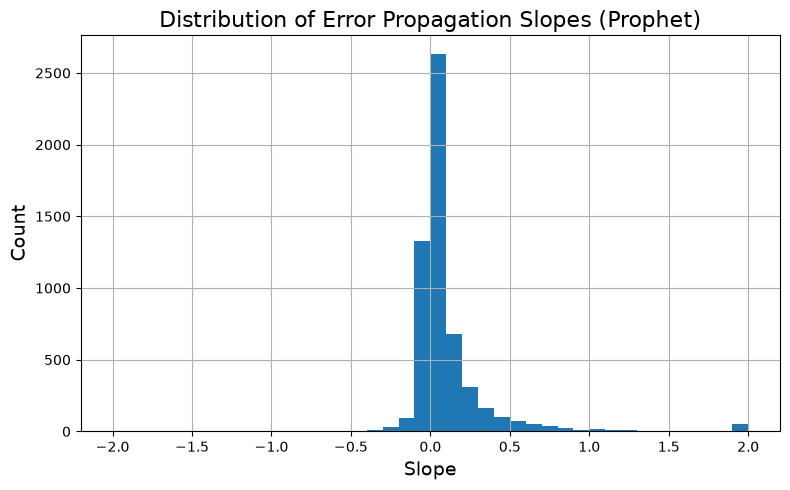

In [21]:
# ============================================
# Prophet validation results: error propagation + clustering
# ============================================


# -------------------------
# Paths
# -------------------------
import os
import time
CSV_PATH = os.path.join(outputs_dir, "validation", "prophet", "validation_prophet.csv")
FIG_DIR = os.path.join(outputs_dir, "validation", "prophet", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def _timestamp():
    return time.strftime("%Y%m%d-%H%M%S")

def save_and_show(basename):
    plt.tight_layout()
    path = os.path.join(FIG_DIR, f"{basename}.pdf")
    plt.savefig(path, bbox_inches='tight')
    plt.savefig(os.path.join(FIG_DIR, f'{basename}.png'), dpi=150, bbox_inches='tight')
    print(f"[saved] {path}")
    try:
        plt.show()
    except Exception as e:
        print(f"[show skipped] {e}")
    plt.close()

# -------------------------
# Load data
# -------------------------
data = pd.read_csv(CSV_PATH, low_memory=False)

# -------------------------
# Helpers
# -------------------------
def parse_list(s):
    if isinstance(s, list):
        return s
    if isinstance(s, (np.ndarray, tuple)):
        return list(s)
    try:
        from ast import literal_eval
        return list(literal_eval(s))
    except Exception:
        return None

def seq_to_errors(y_true, y_pred, H):
    y_true = np.array(y_true[:H], dtype=float)
    y_pred = np.array(y_pred[:H], dtype=float)
    err = y_true - y_pred
    mae_by_h = np.abs(err)
    rmse_by_h_sq = err**2
    with np.errstate(divide='ignore', invalid='ignore'):
        mape_by_h = np.where(np.abs(y_true) > 1e-12, np.abs(err / y_true) * 100.0, np.nan)
    return mae_by_h, rmse_by_h_sq, mape_by_h

# -------------------------
# Parse predicted and true lists (Prophet columns)
# -------------------------
required_cols = ["val_true_list", "val_pred_list"]
missing = [c for c in required_cols if c not in data.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

data['y_true_seq'] = data['val_true_list'].apply(parse_list)
data['y_pred_seq'] = data['val_pred_list'].apply(parse_list)

data = data.dropna(subset=['y_true_seq', 'y_pred_seq']).reset_index(drop=True)
data = data[[len(t) > 0 and len(p) > 0 for t, p in zip(data['y_true_seq'], data['y_pred_seq'])]].reset_index(drop=True)

seq_lengths = data.apply(lambda r: min(len(r['y_true_seq']), len(r['y_pred_seq'])), axis=1)
if len(seq_lengths) == 0:
    raise ValueError("No valid (true,pred) sequences found after parsing.")

H = int(seq_lengths.min())
H = min(H, 132)
data['H_common'] = H

print("Number of series:", len(data))
print("Common evaluation horizon H:", H)

# -------------------------
# Horizon-wise errors
# -------------------------
all_mae, all_rmse_sq, all_mape = [], [], []
for _, row in data.iterrows():
    mae_h, rmse_sq_h, mape_h = seq_to_errors(row['y_true_seq'], row['y_pred_seq'], H)
    all_mae.append(mae_h)
    all_rmse_sq.append(rmse_sq_h)
    all_mape.append(mape_h)

all_mae = np.vstack(all_mae)
all_rmse_sq = np.vstack(all_rmse_sq)
all_mape = np.vstack(all_mape)

N = all_mae.shape[0]
horizons = np.arange(1, H + 1)

# -------------------------
# Aggregate by horizon
# -------------------------
mean_mae = np.nanmean(all_mae, axis=0)
std_mae  = np.nanstd(all_mae, axis=0, ddof=1)

mean_sq = np.nanmean(all_rmse_sq, axis=0)
std_sq  = np.nanstd(all_rmse_sq, axis=0, ddof=1)

rmse_by_h = np.sqrt(mean_sq)
rmse_lo = np.sqrt(np.clip(mean_sq - std_sq, a_min=0, a_max=None))
rmse_hi = np.sqrt(mean_sq + std_sq)

mean_mape = np.nanmean(all_mape, axis=0)
std_mape  = np.nanstd(all_mape, axis=0, ddof=1)

summary_by_h = pd.DataFrame({
    'h': horizons,
    'mean_MAE': mean_mae,
    'std_MAE': std_mae,
    'RMSE': rmse_by_h,
    'RMSE_lo': rmse_lo,
    'RMSE_hi': rmse_hi,
    'mean_MAPE_percent': mean_mape,
    'std_MAPE_percent': std_mape
})

out_summary_csv = os.path.join(outputs_dir, "validation", "prophet", "prophet_error_propagation_summary_by_h.csv")
summary_by_h.to_csv(out_summary_csv, index=False)

# -------------------------
# -------------------------
# Per-series slope
# -------------------------
X = horizons.reshape(-1, 1)
slopes = np.empty(N)
intercepts = np.empty(N)

lr = LinearRegression()

for i in range(N):
    y = all_mae[i, :]
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

id_col = None
for candidate in ['placekey', 'series', 'series_id', 'poi', 'poi_id']:
    if candidate in data.columns:
        id_col = candidate
        break

per_series_summary = pd.DataFrame({
    'series_index': np.arange(N) if id_col is None else data[id_col].values,
    'slope_b_MAE_per_h': slopes,
    'intercept_a': intercepts,
    'MAE_h1': all_mae[:, 0],
    'MAE_hH': all_mae[:, -1],
    'EPI_linear_per_h': (all_mae[:, -1] - all_mae[:, 0]) / H,
    'EPI_normalized_ratio': np.divide(
        all_mae[:, -1],
        all_mae[:, 0],
        out=np.full(N, np.nan),
        where=(all_mae[:, 0] != 0)
    )
})

out_series_csv = os.path.join(outputs_dir, "validation", "prophet", "prophet_error_propagation_per_series.csv")
per_series_summary.to_csv(out_series_csv, index=False)

merged = data.copy()
merged['_row_index'] = np.arange(N)
per_series_summary['_row_index'] = np.arange(N)

merged = pd.merge(
    merged,
    per_series_summary,
    on='_row_index',
    how='left'
).drop(columns=['_row_index'])

merged_out_csv = os.path.join(outputs_dir, "validation", "prophet", "prophet_validation_merged_with_error_slopes.csv")
merged.to_csv(merged_out_csv, index=False)

# -------------------------
# Plot settings
# -------------------------
TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE  = 12
LEGEND_SIZE = 12

# 4 Histogram
plt.figure(figsize=(8,5))
plt.hist(np.clip(slopes, -2, 2), bins=40, range=(-2,2))
plt.title('Distribution of Error Propagation Slopes (Prophet)', fontsize=TITLE_SIZE)
plt.xlabel('Slope', fontsize=LABEL_SIZE)
plt.ylabel('Count', fontsize=LABEL_SIZE)
plt.grid(True)
save_and_show("prophet_slope_histogram_clipped")


### Combined

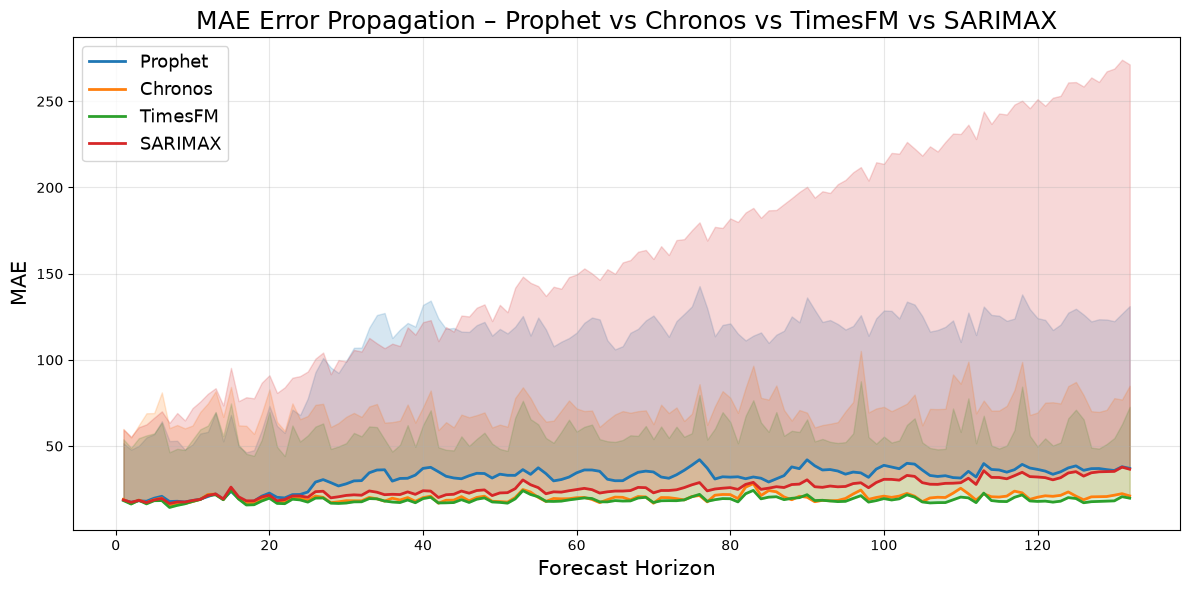

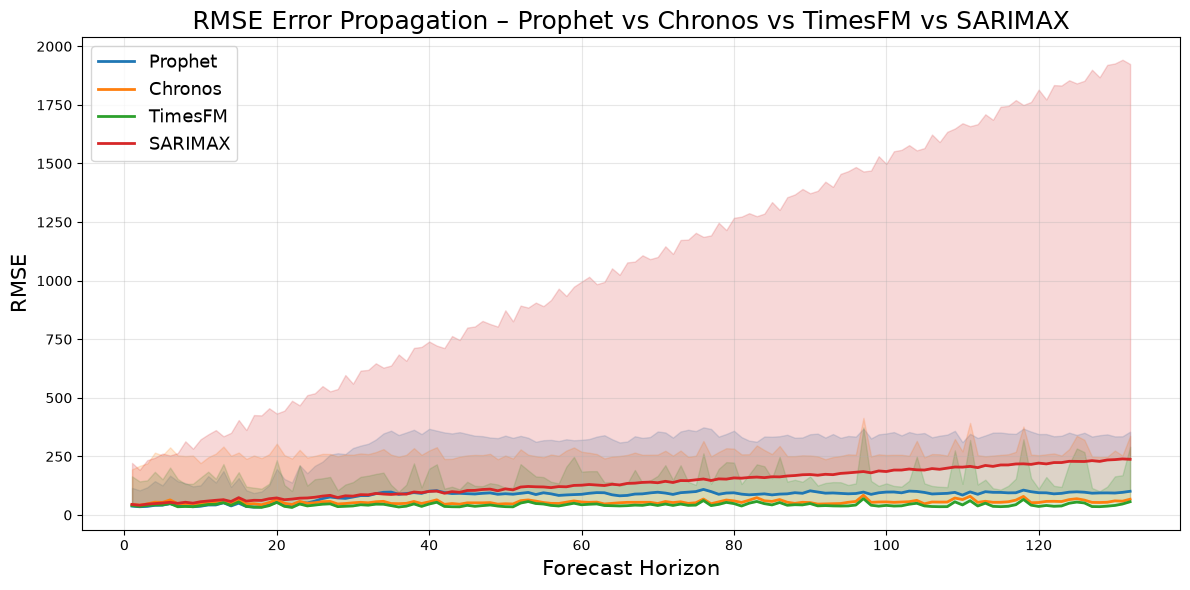

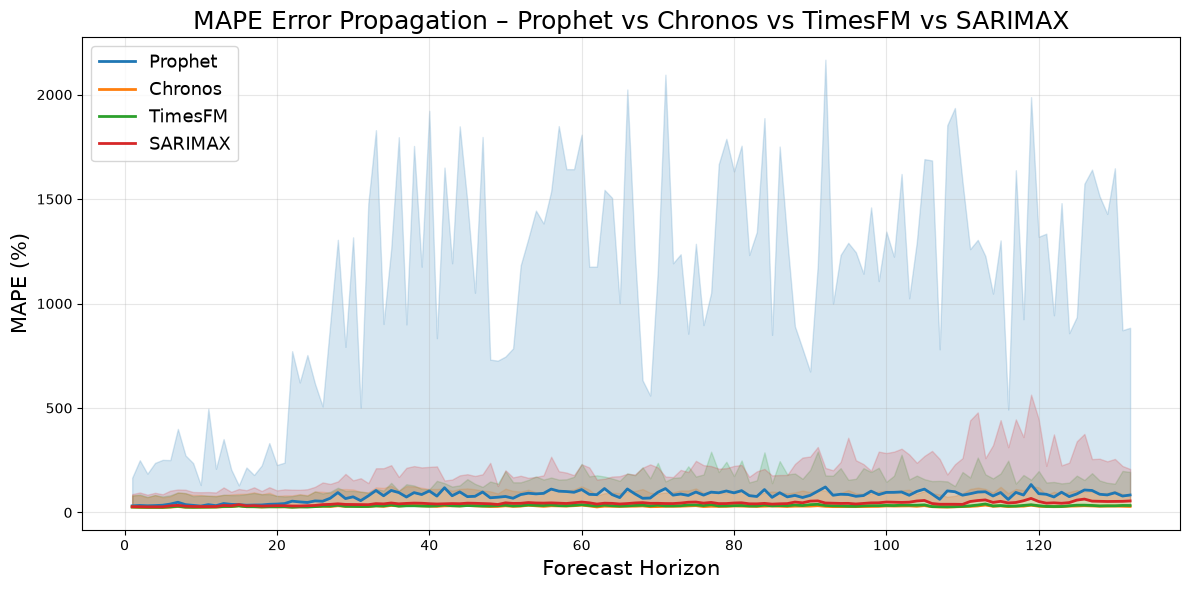


All combined comparison plots saved in: results_2026-06-30_23-59-42\validation\Combined


In [22]:

# =====================================================================
#   INPUT SUMMARY FILES FROM YOUR FOUR MODELS
# =====================================================================
import os
PATHS = {
    "Prophet":  os.path.join(outputs_dir, "validation", "prophet", "prophet_error_propagation_summary_by_h.csv"),
    "Chronos":  os.path.join(outputs_dir, "validation", "chronos", "chronos_error_propagation_summary_by_h.csv"),
    "TimesFM":  os.path.join(outputs_dir, "validation", "timesfm", "timesfm_error_propagation_summary_by_h.csv"),
    "SARIMAX":  os.path.join(outputs_dir, "validation", "sarimax", "sarimax_error_propagation_summary_by_h.csv"),
}

# =====================================================================
#   COLORS (consistent & easy to distinguish)
# =====================================================================
COLORS = {
    "Prophet": "#1f77b4",   # blue
    "Chronos": "#ff7f0e",   # orange
    "TimesFM": "#2ca02c",   # green
    "SARIMAX": "#d62728",   # red
}

OUT_DIR = os.path.join(figures_dir, "validation", "Combined")


# =====================================================================
#   LOAD ALL MODELS INTO ONE DICTIONARY
# =====================================================================
model_data = {}
for model, path in PATHS.items():
    df = pd.read_csv(path)
    df["model"] = model
    model_data[model] = df

# Shared horizon
H = min(df["h"].max() for df in model_data.values())
h = np.arange(1, H + 1)

# =====================================================================
#   GENERIC PLOTTING FUNCTION (SAVE + SHOW)
# =====================================================================
def plot_metric(mean_col, std_col, ylabel, title, filename, nonnegative=True, onesided=False):
    plt.figure(figsize=(12, 6))

    for model, df in model_data.items():
        df = df[df["h"] <= H]

        mu = df[mean_col].values
        
        # Calculate standard deviation dynamically to handle different column formats
        if mean_col == "RMSE":
            sd = df["RMSE_hi"].values - mu
        else:
            sd = df[std_col].values

        if onesided:
            lower = mu
            upper = mu + sd
        else:
            lower = mu - sd
            upper = mu + sd

        if nonnegative:
            lower = np.maximum(lower, 0)

        plt.plot(df["h"], mu, linewidth=2, label=model, color=COLORS[model])
        plt.fill_between(df["h"], lower, upper, alpha=0.18, color=COLORS[model])

    plt.title(title, fontsize=18)
    plt.xlabel("Forecast Horizon", fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{filename}.pdf"), bbox_inches="tight")
    plt.savefig(os.path.join(OUT_DIR, f"{filename}.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# =====================================================================
#   PLOTS (SAVE + SHOW) - Using Positive-Only Shading
# =====================================================================

# 1) MAE
plot_metric(
    mean_col="mean_MAE",
    std_col="std_MAE",
    ylabel="MAE",
    title="MAE Error Propagation – Prophet vs Chronos vs TimesFM vs SARIMAX",
    filename="combined_MAE",
    onesided=True
)

# 2) RMSE
plot_metric(
    mean_col="RMSE",
    std_col=None,
    ylabel="RMSE",
    title="RMSE Error Propagation – Prophet vs Chronos vs TimesFM vs SARIMAX",
    filename="combined_RMSE",
    onesided=True
)

# 3) MAPE
plot_metric(
    mean_col="mean_MAPE_percent",
    std_col="std_MAPE_percent",
    ylabel="MAPE (%)",
    title="MAPE Error Propagation – Prophet vs Chronos vs TimesFM vs SARIMAX",
    filename="combined_MAPE",
    onesided=True
)

print("\nAll combined comparison plots saved in:", OUT_DIR)


### Validation Statistics Tables
This section generates **Table 1** (overall summary statistics), **Table 2** (model win counts), and **Table 3** (horizon-wise metric breakdown) in both CSV and LaTeX formats from the validation results of all four models.

In [2]:
# =====================================================================
#   GENERATE TABLES 1, 2, AND 3 (CSV & LaTeX)
# =====================================================================
import os
import glob
import pandas as pd
import numpy as np

# Auto-locate outputs_dir
results_folders = sorted(glob.glob("results_*"))
if not results_folders:
    raise FileNotFoundError("No results_* folder found on disk.")
outputs_dir = results_folders[-1]
stats_dir = os.path.join(outputs_dir, "statistics")
os.makedirs(stats_dir, exist_ok=True)

# Load validation data
prophet_path = os.path.join(outputs_dir, "validation", "prophet", "validation_prophet.csv")
sarimax_path = os.path.join(outputs_dir, "validation", "sarimax", "validation_sarimax.csv")
chronos_path = os.path.join(outputs_dir, "validation", "chronos", "validation_chronos.csv")
timesfm_path = os.path.join(outputs_dir, "validation", "timesfm", "validation_timesfm.csv")

df_prophet = pd.read_csv(prophet_path)
df_sarimax = pd.read_csv(sarimax_path)
df_chronos = pd.read_csv(chronos_path)
df_timesfm = pd.read_csv(timesfm_path)

# Align indexes on placekey
pkeys = df_timesfm["placekey"].values
df_prophet = df_prophet.set_index("placekey").reindex(pkeys).reset_index()
df_sarimax = df_sarimax.set_index("placekey").reindex(pkeys).reset_index()
df_chronos = df_chronos.set_index("placekey").reindex(pkeys).reset_index()

# ----------------- TABLE 1 -----------------
table1_rows = []
for metric in ["mae", "rmse"]:
    for model, df, col in [
        ("Prophet", df_prophet, f"prophet_{metric}"),
        ("SARIMAX", df_sarimax, f"sarimax_{metric}"),
        ("Chronos", df_chronos, f"chronos_{metric}"),
        ("TimesFM", df_timesfm, f"timesfm_{metric}")
    ]:
        values = df[col].dropna().values
        mean_val = np.mean(values)
        median_val = np.median(values)
        std_val = np.std(values, ddof=1)
        q25 = np.percentile(values, 25)
        q75 = np.percentile(values, 75)
        iqr_val = q75 - q25
        max_val = np.max(values)
        
        table1_rows.append({
            "Metric": metric.upper(),
            "Model": model,
            "Mean": round(mean_val, 2),
            "Median": round(median_val, 2),
            "Std": round(std_val, 2),
            "Interquartile Range": round(iqr_val, 2),
            "Max": round(max_val, 2)
        })

table1_df = pd.DataFrame(table1_rows)
table1_df.to_csv(os.path.join(stats_dir, "table1.csv"), index=False)

# LaTeX for Table 1
t1_tex = "\\begin{table}[htbp]\n\\centering\n"
t1_tex += "\\caption{Summary statistics for MAE and RMSE across all 5,671 POIs}\n"
t1_tex += "\\begin{tabular}{llccccc}\n\\toprule\n"
t1_tex += "Metric & Model & Mean & Median & Std & Interquartile Range & Max \\\\\n\\midrule\n"
prev_metric = ""
for idx, r in table1_df.iterrows():
    metric_str = r["Metric"] if r["Metric"] != prev_metric else ""
    prev_metric = r["Metric"]
    is_best = r["Model"] == "TimesFM"
    model_str = f"\\textbf{{{r['Model']}}}" if is_best else r["Model"]
    mean_str = f"\\textbf{{{r['Mean']:.2f}}}" if is_best else f"{r['Mean']:.2f}"
    med_str = f"\\textbf{{{r['Median']:.2f}}}" if is_best else f"{r['Median']:.2f}"
    std_str = f"\\textbf{{{r['Std']:.2f}}}" if is_best else f"{r['Std']:.2f}"
    iqr_str = f"\\textbf{{{r['Interquartile Range']:.2f}}}" if is_best else f"{r['Interquartile Range']:.2f}"
    max_str = f"\\textbf{{{r['Max']:.2f}}}" if is_best else f"{r['Max']:.2f}"
    
    t1_tex += f"{metric_str} & {model_str} & {mean_str} & {med_str} & {std_str} & {iqr_str} & {max_str} \\\\\n"
    if idx == 3:
        t1_tex += "\\midrule\n"
t1_tex += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"
with open(os.path.join(stats_dir, "table1.tex"), "w", encoding="utf-8") as f:
    f.write(t1_tex)

# ----------------- TABLE 2 -----------------
mae_matrix = pd.DataFrame({
    "Prophet": df_prophet["prophet_mae"],
    "SARIMAX": df_sarimax["sarimax_mae"],
    "Chronos": df_chronos["chronos_mae"],
    "TimesFM": df_timesfm["timesfm_mae"]
})
rmse_matrix = pd.DataFrame({
    "Prophet": df_prophet["prophet_rmse"],
    "SARIMAX": df_sarimax["sarimax_rmse"],
    "Chronos": df_chronos["chronos_rmse"],
    "TimesFM": df_timesfm["timesfm_rmse"]
})

mae_wins = mae_matrix.idxmin(axis=1).value_counts()
rmse_wins = rmse_matrix.idxmin(axis=1).value_counts()

table2_rows = []
for model in ["TimesFM", "Chronos", "SARIMAX", "Prophet"]:
    table2_rows.append({
        "Model": model,
        "MAE Wins": mae_wins.get(model, 0),
        "RMSE Wins": rmse_wins.get(model, 0)
    })
table2_df = pd.DataFrame(table2_rows)
table2_df.to_csv(os.path.join(stats_dir, "table2.csv"), index=False)

# LaTeX for Table 2
t2_tex = "\\begin{table}[htbp]\n\\centering\n"
t2_tex += "\\caption{POI-level win counts (best-performing model for each metric). A higher number of wins shows better performance}\n"
t2_tex += "\\begin{tabular}{lcc}\n\\toprule\n"
t2_tex += "Model & MAE Wins & RMSE Wins \\\\\n\\midrule\n"
for idx, r in table2_df.iterrows():
    t2_tex += f"{r['Model']} & {r['MAE Wins']} & {r['RMSE Wins']} \\\\\n"
t2_tex += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"
with open(os.path.join(stats_dir, "table2.tex"), "w", encoding="utf-8") as f:
    f.write(t2_tex)

# ----------------- TABLE 3 -----------------
horizons = [1, 10, 20, 30, 40, 60, 80, 100, 120, 132]
summary_data = {}
for m in ["prophet", "chronos", "timesfm", "sarimax"]:
    path = os.path.join(outputs_dir, "validation", m, f"{m}_error_propagation_summary_by_h.csv")
    df = pd.read_csv(path)
    df_filtered = df[df["h"].isin(horizons)].set_index("h")
    summary_data[m] = df_filtered

# Table 3 CSV saving
table3_cols = ["h"]
for m in ["prophet", "chronos", "timesfm", "sarimax"]:
    table3_cols.extend([f"{m}_MAE", f"{m}_SD", f"{m}_RMSE", f"{m}_MAPE"])

table3_rows = []
for h in horizons:
    row = {"h": h}
    for m in ["prophet", "chronos", "timesfm", "sarimax"]:
        row[f"{m}_MAE"] = round(summary_data[m].loc[h, "mean_MAE"], 2)
        row[f"{m}_SD"] = round(summary_data[m].loc[h, "std_MAE"], 2)
        row[f"{m}_RMSE"] = round(summary_data[m].loc[h, "RMSE"], 2)
        row[f"{m}_MAPE"] = round(summary_data[m].loc[h, "mean_MAPE_percent"], 2)
    table3_rows.append(row)
table3_df = pd.DataFrame(table3_rows)
table3_df.to_csv(os.path.join(stats_dir, "table3.csv"), index=False)

# LaTeX for Table 3
t3_tex = "\\begin{table}[htbp]\n\\centering\n"
t3_tex += "\\caption{Summary of Horizon-wise Error Metrics for Prophet, Chronos, TimesFM, and SARIMAX}\n"
t3_tex += "\\begin{tabular}{c|cccc|cccc}\n\\toprule\n"
t3_tex += " & \\multicolumn{8}{c}{\\textbf{Panel A: Prophet and Chronos}} \\\\\n"
t3_tex += "\\midrule\n"
t3_tex += "\\multirow{2}{*}{Horizon} & \\multicolumn{4}{c|}{Prophet} & \\multicolumn{4}{c}{Chronos} \\\\\n"
t3_tex += " & MAE & SD & RMSE & MAPE & MAE & SD & RMSE & MAPE \\\\\n\\midrule\n"
for h in horizons:
    row = table3_df[table3_df["h"] == h].iloc[0]
    t3_tex += f"{h} & {row['prophet_MAE']:.2f} & {row['prophet_SD']:.2f} & {row['prophet_RMSE']:.2f} & {row['prophet_MAPE']:.2f}\\% & "
    t3_tex += f"{row['chronos_MAE']:.2f} & {row['chronos_SD']:.2f} & {row['chronos_RMSE']:.2f} & {row['chronos_MAPE']:.2f}\\% \\\\\n"
t3_tex += "\\midrule\\midrule\n"
t3_tex += " & \\multicolumn{8}{c}{\\textbf{Panel B: TimesFM and SARIMAX}} \\\\\n"
t3_tex += "\\midrule\n"
t3_tex += "\\multirow{2}{*}{Horizon} & \\multicolumn{4}{c|}{TimesFM} & \\multicolumn{4}{c}{SARIMAX} \\\\\n"
t3_tex += " & MAE & SD & RMSE & MAPE & MAE & SD & RMSE & MAPE \\\\\n\\midrule\n"
for h in horizons:
    row = table3_df[table3_df["h"] == h].iloc[0]
    t3_tex += f"{h} & {row['timesfm_MAE']:.2f} & {row['timesfm_SD']:.2f} & {row['timesfm_RMSE']:.2f} & {row['timesfm_MAPE']:.2f}\\% & "
    t3_tex += f"{row['sarimax_MAE']:.2f} & {row['sarimax_SD']:.2f} & {row['sarimax_RMSE']:.2f} & {row['sarimax_MAPE']:.2f}\\% \\\\\n"
t3_tex += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"

with open(os.path.join(stats_dir, "table3.tex"), "w", encoding="utf-8") as f:
    f.write(t3_tex)

print("Tables generated successfully:")
print(os.path.join(stats_dir, "table1.csv"))
print(os.path.join(stats_dir, "table2.csv"))
print(os.path.join(stats_dir, "table3.csv"))


Tables generated successfully:
results_latest\statistics\table1.csv
results_latest\statistics\table2.csv
results_latest\statistics\table3.csv


# Test set using TimesFM 

In [27]:
# ============================
# TimesFM (GPU), TEST (post-hurricane), single CSV with list columns
# - GPU model (bf16 if supported else fp16 where applicable; TimesFM runs in torch FP32 by default,
#   we keep CUDA checks and high-matmul precision like the official example)
# - CPU inputs (model handles device internally)
# - Robust error logging & safe prediction fallback
# ============================

set_reproducible_seeds(42)
import io
import warnings
import logging
import time
import traceback
from contextlib import redirect_stderr
os.environ.setdefault("TRANSFORMERS_NO_TORCHVISION", "1")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

# import matplotlib.pyplot as plt
matplotlib.set_loglevel("ERROR")
warnings.filterwarnings("ignore")
logging.getLogger("matplotlib").setLevel(logging.ERROR)

# ---- CONFIG ----
# assumes base_results_dir was created earlier
OUT_SUMMARY_PATH = os.path.join(
    outputs_dir,
    "predictions/test_timesfm.csv"
)
TIMESFM_MODEL_NAME = os.environ.get("TIMESFM_MODEL_NAME", "google/timesfm-2.5-200m-pytorch")
# kept for API parity; TimesFM returns point + quantiles (not samples). We still accept the env var.
TIMESFM_NUM_SAMPLES = int(os.environ.get("TIMESFM_NUM_SAMPLES", "20"))



# ============================
# Guard: ensure correct package
# ============================
def _assert_correct_timesfm_package():
    try:
        import importlib.metadata as im
        im.version("timesfm")
    except Exception:
        raise ImportError(
            'timesfm not installed.\n'
            'Run:  python -m pip install -U timesfm torch'
        )
_assert_correct_timesfm_package()

# ============================
# TimesFM loader (singleton, forced CUDA check)
# ============================
_timesfm_model = None

def get_timesfm_model():
    """
    Load TimesFM 2.5 (PyTorch) and compile forecast config.
    Fails fast if CUDA is not available (to mirror your Chronos guard).
    """
    global _timesfm_model
    if _timesfm_model is not None:
        return _timesfm_model


    if not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA not available. Install a CUDA-enabled PyTorch build and ensure an NVIDIA GPU is visible."
        )

    # Match official guidance to improve matmul perf on GPU
    torch.set_float32_matmul_precision("high")

    # Load model + compile forecast config (quantiles enabled for probabilistic outputs)
    model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(TIMESFM_MODEL_NAME)
    model.compile(
        timesfm.ForecastConfig(
            max_context=1024,           # safe defaults; model supports much longer contexts
            max_horizon=1024,           # allow large H just in case
            normalize_inputs=True,
            use_continuous_quantile_head=True,   # we’ll read median from quantiles if available
            force_flip_invariance=True,
            infer_is_positive=True,
            fix_quantile_crossing=True,
        )
    )
    # Move to CUDA if the wrapper exposes .to(); otherwise internals run on cuda already.
    try:
        model.to("cuda")
    except Exception:
        pass

    import torch as _torch
    print(f"[TimesFM] Loaded {TIMESFM_MODEL_NAME} on GPU "
          f"({_torch.cuda.get_device_name(0)}).")
    _timesfm_model = model
    return _timesfm_model

# ============================
# Helpers
# ============================
def _clean_array(x: np.ndarray) -> np.ndarray:
    """Replace non-finite entries with median (or 0.0 if all non-finite)."""
    x = np.asarray(x, dtype=np.float32)
    if np.isfinite(x).all():
        return x
    if np.isfinite(x).any():
        fill = float(np.nanmedian(x[np.isfinite(x)]))
    else:
        fill = 0.0
    return np.nan_to_num(x, nan=fill, posinf=fill, neginf=fill)

def _reduce_timesfm_to_point(point_forecast: np.ndarray,
                             quantile_forecast: np.ndarray | None,
                             H: int) -> np.ndarray:
    """
    Prefer the model's point forecast; if quantiles exist, use the median (P50).
    Ensures shape (H,) and guards non-finite.
    """
    out = None
    if isinstance(point_forecast, np.ndarray):
        # point_forecast expected shape: (1, H)
        out = np.asarray(point_forecast[0], dtype=np.float32) if point_forecast.ndim == 2 else np.asarray(point_forecast, dtype=np.float32)
    if (out is None or not np.isfinite(out).all()) and quantile_forecast is not None:
        # quantile_forecast expected shape: (1, H, K) where K includes mean and 10..90% quantiles
        q = np.asarray(quantile_forecast)
        try:
            # If channels ordered [mean, q10, q20, ..., q90], pick median approx at q50 (index 5)
            median_series = q[0, :, 5]
            out = median_series.astype(np.float32)
        except Exception:
            out = q[0, :, 0].astype(np.float32)  # mean
    if out is None:
        out = np.zeros(H, dtype=np.float32)
    if out.shape[0] != H:
        out = out[:H] if out.shape[0] > H else np.pad(out, (0, H - out.shape[0]), mode="edge")
    return _clean_array(out)

def safe_predict(model, context_np: np.ndarray, H: int, num_samples: int):
    """
    Try multiple input forms (NumPy -> torch CPU tensor -> list) with TimesFM.
    Capture stderr + traceback. Fall back to naive persistence if all fail.
    Returns np.ndarray of shape (H,) and a diagnostics dict.
    """
    attempts = []
    diag = {"ok": False, "attempts": []}

    # TimesFM expects a list of 1D series; it returns (point, quantiles).
    def _call_forecast(inp):
        point, quants = model.forecast(horizon=H, inputs=[inp])
        return _reduce_timesfm_to_point(point, quants, H)

    # 1) NumPy
    try:
        with io.StringIO() as errbuf, redirect_stderr(errbuf):
            pred = _call_forecast(context_np.astype(np.float32))
            stderr = errbuf.getvalue()
        attempts.append(("numpy", None if stderr == "" else stderr))
        diag["attempts"].append(("numpy", stderr[:500]))
        return pred, {**diag, "ok": True}
    except Exception:
        attempts.append(("numpy", traceback.format_exc()))
        diag["attempts"].append(("numpy", traceback.format_exc()[:500]))

    # 2) torch tensor (CPU)
    try:
        ctx_t = torch.tensor(context_np, dtype=torch.float32)  # CPU tensor
        with io.StringIO() as errbuf, redirect_stderr(errbuf):
            pred = _call_forecast(ctx_t.cpu().numpy())
            stderr = errbuf.getvalue()
        attempts.append(("torch_cpu", None if stderr == "" else stderr))
        diag["attempts"].append(("torch_cpu", stderr[:500]))
        return pred, {**diag, "ok": True}
    except Exception:
        attempts.append(("torch_cpu", traceback.format_exc()))
        diag["attempts"].append(("torch_cpu", traceback.format_exc()[:500]))

    # 3) Python list
    try:
        ctx_l = context_np.astype(np.float32).tolist()
        with io.StringIO() as errbuf, redirect_stderr(errbuf):
            pred = _call_forecast(np.array(ctx_l, dtype=np.float32))
            stderr = errbuf.getvalue()
        attempts.append(("list", None if stderr == "" else stderr))
        diag["attempts"].append(("list", stderr[:500]))
        return pred, {**diag, "ok": True}
    except Exception:
        attempts.append(("list", traceback.format_exc()))
        diag["attempts"].append(("list", traceback.format_exc()[:500]))

    # Fallback: naive last value
    last_val = float(context_np[-1]) if context_np.size else 0.0
    print("[WARN] TimesFM prediction failed on all attempts. Using naive persistence.")
    for name, info in attempts:
        print(f"  attempt={name} -> {str(info).splitlines()[0] if info else 'no-stderr'}")
    return np.full(H, last_val, dtype=float), {**diag, "ok": False}

# ============================
# SINGLE-POI PROCESSOR (GPU model, CPU inputs) – TEST SPLIT
# ============================
def process_single_poi_full_scale(poi_data):
    """
    TEST SET version (matches SARIMAX/Prophet code):
      - Train = all data strictly BEFORE hurricane_date
      - Test  = all data ON or AFTER hurricane_date
      - Model runs on GPU; inputs remain on CPU (TimesFM handles device internally)
      - Returns metrics + list columns for the TEST window
    Assumes `compute_metrics(y_true, y_pred)` exists in your env.
    """
    try:
        errcap = io.StringIO()
        with warnings.catch_warnings(), redirect_stderr(errcap):
            warnings.simplefilter("ignore")

            # --- dates ---
            date_range = pd.date_range(start="2023-05-01", end="2025-02-02")
            hurricane_date = pd.to_datetime("2024-09-23")

            # --- series ---
            placekey = poi_data["placekey"]
            visits_list = poi_data["visits_list"]
            series = pd.Series(visits_list, index=date_range).astype(float)

            # Train/Test split like your SARIMAX/Prophet code
            train = series[series.index < hurricane_date]
            test = series[series.index >= hurricane_date]

            H = len(test)
            if H == 0:
                return None
            if len(train) < 10:
                return None

            # Clean/guard non-finite
            train_arr = _clean_array(train.values)

            # --- TimesFM prediction (inputs on CPU) ---
            model = get_timesfm_model()
            preds, diag = safe_predict(model, train_arr, H, TIMESFM_NUM_SAMPLES)

            # --- Metrics on TEST window ---
            preds = _clean_array(preds)
            y_true = _clean_array(test.values)
            (
                t_mae,
                t_rmse,
                t_r2,
                t_auc_pos,
                t_auc_neg,
                t_auc_total,
            ) = compute_metrics(y_true, preds)

            return {
                "placekey": placekey,
                "latitude": poi_data.get("latitude"),
                "longitude": poi_data.get("longitude"),
                "naics_code": poi_data.get("naics_code"),
                "city": poi_data.get("city"),
                "region": poi_data.get("region"),
                "GEOID": poi_data.get("GEOID"),
                "County": poi_data.get("county"),
                "mean_per_day": poi_data.get("mean_per_day"),
                "mean_before_hurricane": poi_data.get("mean_before_hurricane"),
                "mean_after_hurricane": poi_data.get("mean_after_hurricane"),

                "timesfm_mae": t_mae,
                "timesfm_rmse": t_rmse,
                "timesfm_r2": t_r2,
                "timesfm_auc_pos": t_auc_pos,
                "timesfm_auc_neg": t_auc_neg,
                "timesfm_auc_total": t_auc_total,

                # TEST window lists
                "test_dates": [d.strftime("%Y-%m-%d") for d in test.index.tolist()],
                "test_true_list": y_true.tolist(),
                "test_pred_list": preds.tolist(),

                # optional debug hooks (stringify to survive CSV)
                "timesfm_ok": diag.get("ok", False),
            }

    except Exception as e:
        # Print full traceback + any captured stderr (even if message is empty)
        tb = traceback.format_exc()
        print(f"ERROR processing POI {poi_data.get('placekey', 'unknown')}: {repr(e)}")
        print(tb.splitlines()[-3] if tb else "no-traceback")
        return None

# ============================
# FULL-SCALE DRIVER
# ============================

def run_full_scale_processing():
    print(f"=== TEST (TimesFM GPU) PROCESSING - {len(df_filtered)} POIs ===")
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
    print(f"Model: {TIMESFM_MODEL_NAME}")
    print(f"Starting at: {pd.Timestamp.now()}")

    # ensure model is loaded on GPU
    _ = get_timesfm_model()

    poi_list = df_filtered.to_dict("records")

    start_time = time.time()
    results = [process_single_poi_full_scale(p) for p in tqdm(poi_list, desc="Processing all POIs (TEST)")]

    summary_rows = [r for r in results if r is not None]
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(OUT_SUMMARY_PATH, index=False)

    elapsed = time.time() - start_time
    print("\n=== PROCESSING COMPLETE ===")
    print(f"Total time: {elapsed/60:.1f} minutes ({elapsed:.0f} seconds)")
    print(f"Successfully processed: {len(summary_rows)}/{len(poi_list)} "
          f"({(len(summary_rows)/len(poi_list)*100 if poi_list else 0):.1f}%)")
    print(f"Results saved to: {OUT_SUMMARY_PATH}")

    return summary_df

# ============================
# Execute
# ============================
import os
if os.path.exists(OUT_SUMMARY_PATH) and os.path.getsize(OUT_SUMMARY_PATH) > 10:
    print(f"✅ [SKIP] Test prediction output already exists at: {OUT_SUMMARY_PATH}")
    print("Loading existing results into final_summary_df...")
    final_summary_df = pd.read_csv(OUT_SUMMARY_PATH)
else:
    print("🚀 Starting TEST-only (TimesFM, GPU) processing...")
    final_summary_df = run_full_scale_processing()


🚀 Starting TEST-only (TimesFM, GPU) processing...
=== TEST (TimesFM GPU) PROCESSING - 5671 POIs ===
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU
Model: google/timesfm-2.5-200m-pytorch
Starting at: 2026-07-01 16:31:32.453890
[TimesFM] Loaded google/timesfm-2.5-200m-pytorch on GPU (NVIDIA GeForce RTX 4060 Laptop GPU).


Processing all POIs (TEST): 100%|██████████| 5671/5671 [2:12:21<00:00,  1.40s/it]  



=== PROCESSING COMPLETE ===
Total time: 132.4 minutes (7942 seconds)
Successfully processed: 5671/5671 (100.0%)
Results saved to: results_2026-06-30_23-59-42\predictions/test_timesfm.csv


## Statistical test

In [28]:
# --- Path Definitions for Standalone Repo Structure ---
import warnings
import os
MAIN_CSV_PATH = os.path.join(outputs_dir, 'predictions', 'test_timesfm.csv')
URBAN_SHP_PATH = 'data/geospatial/tl_2020_us_uac20/tl_2020_us_uac20.shp'
RUCC_CSV_PATH = 'data/raw/Ruralurbancontinuumcodes2023.csv'
# ================================
# CONFIG: paths (EDIT THESE)
# ================================

# Option A (preferred): 2020 Urban Areas shapefile (national file tl_2020_us_uac20.shp)
# Option B: RUCC (long format) CSV (FIPS, State, County_Name, Attribute, Val

# ================================
# Imports
# ================================
warnings.filterwarnings("ignore")



# Optional: Welch ANOVA via pingouin or statsmodels
_pg = None
try:
    _pg = pg
except Exception:
    pass

try:
    from statsmodels.stats.oneway import anova_oneway as sm_welch_anova
except Exception:
    sm_welch_anova = None

# Optional (for shapefile confounder)
_gpd = None
try:
    _gpd = gpd
except Exception:
    pass

# ================================
# Helper functions
# ================================
def ci_mean(series, alpha=0.05):
    """Return (mean, n, lower, upper) for a 1-α CI using t-distribution."""
    x = pd.to_numeric(series, errors="coerce").dropna()
    n = x.size
    mean = x.mean()
    if n <= 1:
        return mean, n, np.nan, np.nan
    se = x.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    lower, upper = mean - tcrit*se, mean + tcrit*se
    return mean, n, lower, upper

def eta_omega_from_anova(anova_table):
    """Compute eta^2 and omega^2 for a one-way ANOVA table (typ=2 from statsmodels)."""
    ss_between = anova_table.loc[anova_table.index.str.contains('C\\(naics_2d\\)', regex=True), 'sum_sq'].sum()
    ss_resid  = anova_table.loc['Residual', 'sum_sq']
    df_between = anova_table.loc[anova_table.index.str.contains('C\\(naics_2d\\)', regex=True), 'df'].sum()
    df_resid   = anova_table.loc['Residual', 'df']
    ss_total = ss_between + ss_resid
    eta2 = ss_between / ss_total if ss_total > 0 else np.nan
    ms_between = ss_between / df_between if df_between > 0 else np.nan
    ms_within  = ss_resid  / df_resid   if df_resid  > 0 else np.nan
    omega2 = (ss_between - df_between*ms_within) / (ss_total + ms_within) if (ss_total + ms_within) > 0 else np.nan
    return eta2, omega2

def sector_means_ci(df, value_col='prophet_auc_total', group_col='naics_2d'):
    rows = []
    for g, sub in df.groupby(group_col):
        mean, n, lo, hi = ci_mean(sub[value_col])
        rows.append([str(g), mean, n, lo, hi])
    out = pd.DataFrame(rows, columns=[group_col, 'mean', 'n', 'ci_low', 'ci_high'])
    return out.sort_values('mean', ascending=False)

def safe_welch_anova(df, y='prophet_auc_total', g='naics_2d'):
    """Welch ANOVA using pingouin if available, else statsmodels anova_oneway with use_var='unequal' if available."""
    if _pg is not None:
        res = _pg.welch_anova(dv=y, between=g, data=df)
        return ('pingouin', res)
    elif sm_welch_anova is not None:
        groups = [sub[y].dropna().values for _, sub in df.groupby(g)]
        res = sm_welch_anova(groups, use_var='unequal', welch_correction=True)
        # statsmodels returns a SimpleTable; convert to dict-ish
        return ('statsmodels', res)
    else:
        return ('none', None)

# ================================
# 1) Load and prep main data
# ================================
df = pd.read_csv(MAIN_CSV_PATH)
# Ensure as string, then take first 2 characters, then back to int
df["naics_2d"] = df["naics_code"].astype(str).str[:2].astype(int)

# Ensure necessary cols exist
required_cols = ['timesfm_auc_total', 'naics_2d', 'latitude', 'longitude', 'County']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in main CSV: {missing}")

# Clean/convert
df['timesfm_auc_total'] = pd.to_numeric(df['timesfm_auc_total'], errors='coerce')
df['naics_2d'] = df['naics_2d'].astype(str).str.zfill(2)
df = df.dropna(subset=['timesfm_auc_total', 'naics_2d'])

print(f"[INFO] Loaded {len(df):,} rows for analysis after cleaning.")

# ================================
# 2) One-way ANOVA (Sector only)
# ================================
m1 = ols('timesfm_auc_total ~ C(naics_2d)', data=df).fit()
anova_m1 = sm.stats.anova_lm(m1, typ=2)
eta2, omega2 = eta_omega_from_anova(anova_m1)

print("\n=== One-way ANOVA (Sector only) ===")
print(anova_m1)
print(f"\nEffect sizes: eta^2={eta2:.3f}, omega^2={omega2:.3f}")
print(f"R^2 (model): {m1.rsquared:.3f}")

# Assumption checks
# Levene’s test for equal variances across groups
groups = [sub['timesfm_auc_total'].values for _, sub in df.groupby('naics_2d')]
lev_stat, lev_p = stats.levene(*groups, center='median')

# Shapiro–Wilk on residuals (sample if huge)
resid = m1.resid
if len(resid) > 5000:
    np.random.seed(42)
    resid_sample = pd.Series(resid).sample(5000, random_state=42).values
else:
    resid_sample = resid.values
shap_stat, shap_p = stats.shapiro(resid_sample)

print("\n=== Assumption checks ===")
print(f"Levene’s test (median-centered): W={lev_stat:.3f}, p={lev_p:.3e}")
print(f"Shapiro–Wilk (resid sample n={len(resid_sample)}): W={shap_stat:.3f}, p={shap_p:.3e}")

# Robust checks
print("\n=== Robust alternatives ===")
welch_backend, welch_res = safe_welch_anova(df, y='timesfm_auc_total', g='naics_2d')
if welch_backend == 'pingouin':
    print("[Welch ANOVA via pingouin]")
    print(welch_res)
elif welch_backend == 'statsmodels':
    print("[Welch ANOVA via statsmodels.stats.oneway.anova_oneway]")
    print(welch_res)
else:
    print("Welch ANOVA not available (install `pingouin` or use statsmodels >=0.13).")

# Kruskal–Wallis
kw_stat, kw_p = stats.kruskal(*groups)
print(f"[Kruskal–Wallis] H={kw_stat:.3f}, df={len(groups)-1}, p={kw_p:.3e}")

# ================================
# 3) Tukey HSD (pairwise)
# ================================

tukey = pairwise_tukeyhsd(endog=df['timesfm_auc_total'], groups=df['naics_2d'], alpha=0.05)
print("\n=== Tukey HSD (pairwise sector differences) ===")
print(tukey.summary())

# Save Tukey to CSV
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
tukey_df.to_csv(os.path.join(outputs_dir, "statistics", "tukey_sector_pairs.csv"), index=False)
print("[SAVED] outputs/statistics/tukey_sector_pairs.csv")

# ================================
# 4) Sector means + 95% CI
# ================================
means_ci = sector_means_ci(df, value_col='timesfm_auc_total', group_col='naics_2d')
means_ci.to_csv(os.path.join(outputs_dir, "statistics", "sector_means_ci.csv"), index=False)
print("\n=== Sector means with 95% CI (top 10 by mean) ===")
print(means_ci.head(10))
print("[SAVED] outputs/statistics/sector_means_ci.csv")

# ================================
# 5) Confounder analysis: Urban/Rural
#    (A) Shapefile (precise, per-point)
#    (B) RUCC (county-based)
# ================================
def add_urban_flag_from_shapefile(df_in):
    gdf = _gpd.GeoDataFrame(
        df_in.copy(),
        geometry=_gpd.points_from_xy(df_in['longitude'], df_in['latitude']),
        crs="EPSG:4326"
    )

    urban = _gpd.read_file(URBAN_SHP_PATH)
    if urban.crs is None:
        # TIGER is commonly EPSG:4269 (NAD83)
        urban = urban.set_crs("EPSG:4269", allow_override=True)
    urban = urban.to_crs("EPSG:4326")
    urban = urban[['GEOID20', 'NAME20', 'geometry']]

    # Clip to bounding box (optional speed-up)
    xmin, ymin, xmax, ymax = gdf.total_bounds
    bbox = _gpd.GeoDataFrame(geometry=[box(xmin-0.5, ymin-0.5, xmax+0.5, ymax+0.5)], crs="EPSG:4326")
    try:
        urban_clip = _gpd.overlay(urban, bbox, how='intersection')
        if len(urban_clip) == 0:
            urban_clip = urban
    except Exception:
        urban_clip = urban

    joined = _gpd.sjoin(gdf, urban_clip, how="left", predicate="within").drop(columns=["index_right"])
    joined['urban_flag'] = np.where(joined['GEOID20'].notna(), "Urban", "Rural")
    out = pd.DataFrame(joined.drop(columns='geometry'))
    return out

def add_urban_flag_from_rucc(df_in):
    rucc = pd.read_csv(RUCC_CSV_PATH, encoding='latin1')
    rucc = rucc[rucc['Attribute'] == 'RUCC_2023'].copy()
    rucc['RUCC_2023'] = pd.to_numeric(rucc['Value'], errors='coerce')

    # Clean county names for match
    df_tmp = df_in.copy()
    df_tmp['County'] = df_tmp['County'].str.replace(" County", "", regex=False).str.strip()
    rucc['County_Name'] = rucc['County_Name'].astype(str).str.replace(" County", "", regex=False).str.strip()
    rucc['State'] = rucc['State'].astype(str).str.upper().str.strip()

    rucc_nc = rucc[rucc['State'].isin(['NC','NORTH CAROLINA'])][['County_Name','RUCC_2023']]
    merged = df_tmp.merge(rucc_nc, left_on='County', right_on='County_Name', how='left')
    # Build string dtype then set NA safely
    urban_rural = pd.Series(np.where(merged['RUCC_2023'] <= 3, 'Urban', 'Rural'), index=merged.index, dtype='string')
    urban_rural[merged['RUCC_2023'].isna()] = pd.NA
    merged['urban_flag'] = urban_rural
    return merged

urban_source = None
df_urban = None

if _gpd is not None and URBAN_SHP_PATH and os.path.exists(URBAN_SHP_PATH):
    try:
        df_urban = add_urban_flag_from_shapefile(df)
        urban_source = "shapefile"
        print("\n[INFO] Urban/Rural built from shapefile (Census 2020 Urban Areas).")
        print(df_urban['urban_flag'].value_counts(dropna=False))
    except Exception as e:
        print(f"[WARN] Shapefile path present but join failed: {e}. Falling back to RUCC (if available).")

if df_urban is None and RUCC_CSV_PATH and os.path.exists(RUCC_CSV_PATH):
    try:
        df_urban = add_urban_flag_from_rucc(df)
        urban_source = "rucc"
        print("\n[INFO] Urban/Rural built from RUCC county codes (1–3 Urban, 4–9 Rural).")
        print(df_urban['urban_flag'].value_counts(dropna=False))
    except Exception as e:
        print(f"[WARN] RUCC merge failed: {e}. Urban/Rural confounder will be skipped.")

# ================================
# 6) Two-way ANOVA with Urban/Rural (if available)
# ================================
if df_urban is not None and df_urban['urban_flag'].notna().any():
    work = df_urban[['timesfm_auc_total', 'naics_2d', 'urban_flag']].dropna()
    work['naics_2d'] = work['naics_2d'].astype(str)

    m2 = ols('timesfm_auc_total ~ C(naics_2d) * C(urban_flag)', data=work).fit()
    anova_m2 = sm.stats.anova_lm(m2, typ=2)

    print("\n=== Two-way ANOVA (Sector × Urban/Rural) ===")
    print(anova_m2)
    print(f"\nR^2 (sector only): {m1.rsquared:.3f}")
    print(f"R^2 (with spatial main + interaction): {m2.rsquared:.3f}")
    print(f"ΔR^2: {m2.rsquared - m1.rsquared:.3f}")
    print(f"[SOURCE] Urban/Rural derived from: {urban_source}")
else:
    print("\n[INFO] Skipping two-way ANOVA: Urban/Rural not available (no shapefile/rucc match).")

# ================================
# 7) Save key outputs
# ================================
anova_m1.to_csv(os.path.join(outputs_dir, "statistics", "anova_sector_only.csv"))
print("[SAVED] outputs/statistics/anova_sector_only.csv")

if df_urban is not None and df_urban['urban_flag'].notna().any():
    anova_m2.to_csv(os.path.join(outputs_dir, "statistics", "anova_sector_urban.csv"))
    df_urban[['placekey','naics_2d','timesfm_auc_total','urban_flag']].to_csv(os.path.join(outputs_dir, "statistics", "dataset_with_urban_flag.csv"), index=False)
    print("[SAVED] outputs/statistics/anova_sector_urban.csv")
    print("[SAVED] outputs/statistics/dataset_with_urban_flag.csv")

[INFO] Loaded 5,671 rows for analysis after cleaning.

=== One-way ANOVA (Sector only) ===
                 sum_sq      df          F         PR(>F)
C(naics_2d)   23.456354    22.0  45.425212  8.453605e-181
Residual     132.567039  5648.0        NaN            NaN

Effect sizes: eta^2=0.150, omega^2=0.147
R^2 (model): 0.150

=== Assumption checks ===
Levene’s test (median-centered): W=7.867, p=5.310e-25
Shapiro–Wilk (resid sample n=5000): W=0.999, p=1.983e-02

=== Robust alternatives ===
[Welch ANOVA via pingouin]
     Source  ddof1       ddof2          F         p_unc       np2
0  naics_2d     22  186.962811  57.890941  2.233125e-71  0.150339
[Kruskal–Wallis] H=912.056, df=22, p=9.755e-179

=== Tukey HSD (pairwise sector differences) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    11     22  -0.1019    1.0  -0.709  0.5052  False
    11     23   -0.043    1.0 -0.6015  

## Plots

In [29]:
# ------------------------------------------------------------
# Load df1 with auto-locating outputs_dir (Jupyter kernel restart safety)
# ------------------------------------------------------------
try:
    _ = outputs_dir
except NameError:
    import glob
    import os
    results_folders = sorted(glob.glob("results_*"))
    if results_folders:
        outputs_dir = results_folders[-1]
        figures_dir = outputs_dir
        print(f"[info] Automatically set outputs_dir to latest run: {outputs_dir}")
    else:
        raise FileNotFoundError("Could not find any results_* folder on disk.")

try:
    _ = df1
    print("[info] df1 is already defined in memory.")
except NameError:
    import pandas as pd
    import os
    csv_path = os.path.join(outputs_dir, "predictions", "test_timesfm.csv")
    if not os.path.exists(csv_path):
        csv_path = os.path.join(outputs_dir, "outputs", "predictions", "test_timesfm.csv")
    df1 = pd.read_csv(csv_path)
    print(f"[info] Loaded df1 from: {csv_path} (Shape: {df1.shape})")

df1.head()


[info] Loaded df1 from: results_2026-06-30_23-59-42\predictions\test_timesfm.csv (Shape: (5671, 21))


,placekey,latitude,longitude,naics_code,city,region,GEOID,County,mean_per_day,mean_before_hurricane,...,timesfm_mae,timesfm_rmse,timesfm_r2,timesfm_auc_pos,timesfm_auc_neg,timesfm_auc_total,test_dates,test_true_list,test_pred_list,timesfm_ok
0,zzy-226@63g-2dz-kcq,36.099589,-79.778028,3231,Greensboro,NC,3.708101e+11,Guilford,39.785714,42.017613,...,5.140802,7.290843,0.242584,41.562866,-0.281709,0.312736,"['2024-09-23', '2024-09-24', '2024-09-25', '20...","[53.0, 46.0, 39.0, 68.0, 47.0, 39.0, 27.0, 31....","[31.547916412353516, 33.59444046020508, 33.421...",True
1,229-222@8gf-r5g-2hq,35.594863,-82.550944,5412,Asheville,NC,3.702100e+11,Buncombe,74.220497,84.144814,...,31.906404,37.487405,-2.964997,12.949144,-11.139246,0.013711,"['2024-09-23', '2024-09-24', '2024-09-25', '20...","[45.0, 49.0, 66.0, 52.0, 32.0, 16.0, 31.0, 15....","[55.95996856689453, 54.2723388671875, 58.27257...",True
2,22b-222@8gf-dk3-d35,35.224164,-81.036060,5615,Belmont,NC,3.707103e+11,Gaston,156.156832,159.688845,...,25.621218,32.146646,-0.141722,11.116440,-15.995081,-0.036959,"['2024-09-23', '2024-09-24', '2024-09-25', '20...","[171.0, 191.0, 129.0, 202.0, 238.0, 183.0, 164...","[154.93258666992188, 148.41342163085938, 151.4...",True
3,229-225@8gf-fnx-kxq,35.445106,-80.880242,311811,Huntersville,NC,3.711901e+11,Mecklenburg,112.459627,118.095890,...,16.353561,22.750436,0.589330,5.467526,-7.654936,-0.016571,"['2024-09-23', '2024-09-24', '2024-09-25', '20...","[68.0, 89.0, 95.0, 96.0, 125.0, 196.0, 103.0, ...","[65.90464782714844, 67.816162109375, 68.994735...",True
4,zzw-223@8gg-b7s-b6k,35.631602,-81.379969,445120,Hickory,NC,3.703501e+11,Catawba,55.563665,57.424658,...,9.586337,13.035711,-0.117945,13.524900,-7.782347,0.043504,"['2024-09-23', '2024-09-24', '2024-09-25', '20...","[67.0, 63.0, 11.0, 69.0, 77.0, 76.0, 57.0, 66....","[58.61766052246094, 59.25697326660156, 59.6762...",True


### Sample AUC calculation at test set with validation

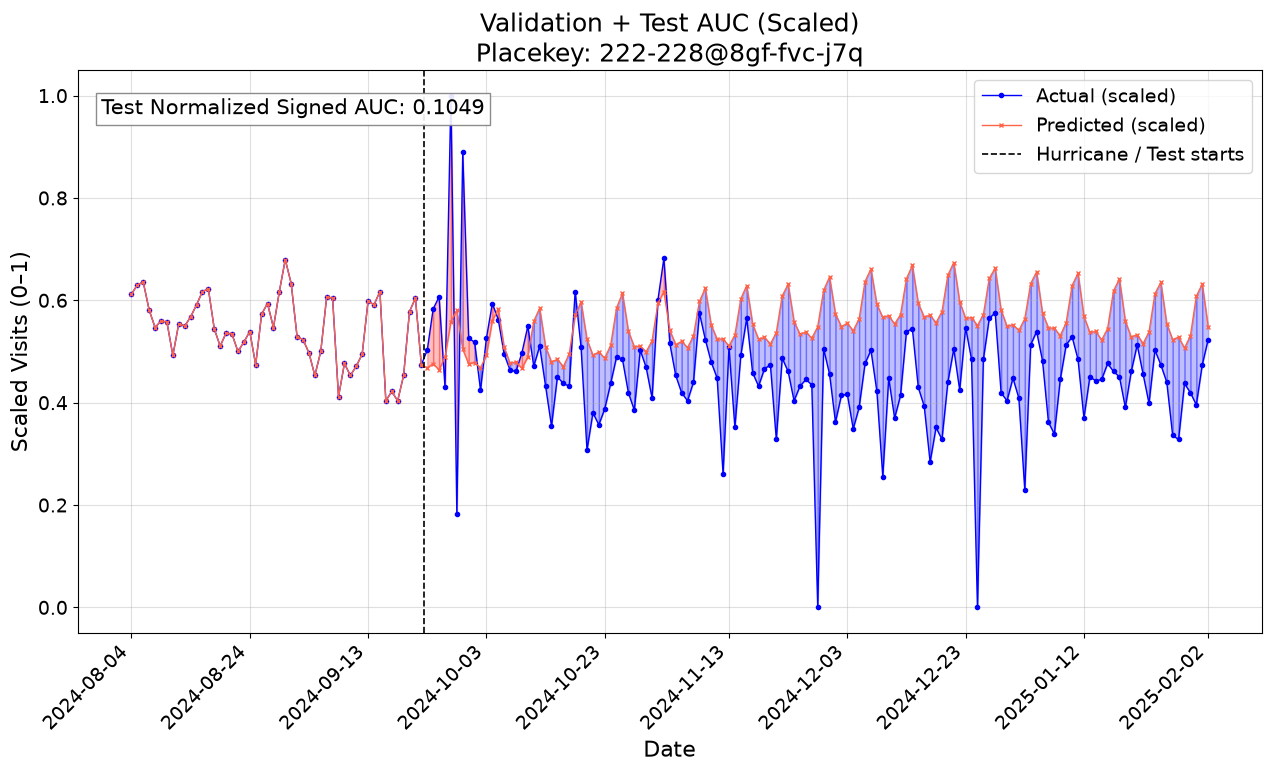

{'placekey': '222-228@8gf-fvc-j7q', 'signed_auc_total_test': np.float64(13.844682852066624), 'normalized_auc_test': np.float64(0.10488396100050473), 'n_validation_points_added': 50}


In [30]:
def parse_list_cell(s):
    """Safely parse stringified list from cell data."""
    if isinstance(s, list):
        return s
    if isinstance(s, (np.ndarray, tuple)):
        return list(s)
    try:
        from ast import literal_eval
        return list(literal_eval(s))
    except Exception:
        return []

def plot_scaled_signed_auc_with_validation_from_visits(
    df1,
    original_df,
    placekey_of_interest,
    n_validation_points=30,
    save_path=None,
    max_xticks=10,
    figsize=(13, 8),
    title_prefix="Validation + Test AUC (Scaled)"
):
    # -----------------------------
    # 1) Get TimesFM result row
    # -----------------------------
    row = df1.loc[df1["placekey"] == placekey_of_interest]
    if row.empty:
        raise ValueError(f"placekey not found in df1: {placekey_of_interest}")
    row = row.iloc[0]

    # -----------------------------
    # 2) Get original POI row
    # -----------------------------
    orig_row = original_df.loc[original_df["placekey"] == placekey_of_interest]
    if orig_row.empty:
        raise ValueError(f"placekey not found in original_df: {placekey_of_interest}")
    orig_row = orig_row.iloc[0]

    # -----------------------------
    # 3) Parse test prediction results
    # -----------------------------
    test_true = np.array(parse_list_cell(row["test_true_list"]), dtype=float)
    test_pred = np.array(parse_list_cell(row["test_pred_list"]), dtype=float)
    test_dates = parse_list_cell(row["test_dates"])

    # -----------------------------
    # 4) Rebuild full observed series from visits_list
    # -----------------------------
    date_range = pd.date_range(start="2023-05-01", end="2025-02-02")
    hurricane_date = pd.to_datetime("2024-09-23")

    visits = np.array(parse_list_cell(orig_row["visits_list"]), dtype=float)

    if len(visits) != len(date_range):
        raise ValueError(
            f"visits_list length mismatch: visits={len(visits)}, dates={len(date_range)}"
        )

    full_series = pd.Series(visits, index=date_range)

    train_val = full_series[full_series.index < hurricane_date]

    val_true = train_val.iloc[-n_validation_points:].values
    val_dates = [d.strftime("%Y-%m-%d") for d in train_val.iloc[-n_validation_points:].index]

    # Use actual values as validation "prediction" if validation predictions do not exist
    val_pred = val_true.copy()

    # -----------------------------
    # 5) Combine validation + test
    # -----------------------------
    y_true = np.concatenate([val_true, test_true])
    y_pred = np.concatenate([val_pred, test_pred])
    dates = val_dates + test_dates

    val_len = len(val_true)
    test_start_idx = val_len

    # -----------------------------
    # 6) Scale jointly
    # -----------------------------
    global_min = min(np.min(y_true), np.min(y_pred))
    global_max = max(np.max(y_true), np.max(y_pred))
    denom = global_max - global_min + 1e-8

    y_true_scaled = (y_true - global_min) / denom
    y_pred_scaled = (y_pred - global_min) / denom

    # -----------------------------
    # 7) AUC only for test part
    # -----------------------------
    test_true_scaled = y_true_scaled[test_start_idx:]
    test_pred_scaled = y_pred_scaled[test_start_idx:]

    diff0 = test_pred_scaled[:-1] - test_true_scaled[:-1]
    diff1 = test_pred_scaled[1:] - test_true_scaled[1:]
    area_per_segment = 0.5 * (diff0 + diff1)

    signed_auc_total = np.sum(area_per_segment)
    normalized_auc = signed_auc_total / (len(test_true_scaled) - 1)

    # -----------------------------
    # 8) Plot
    # -----------------------------
    x = np.arange(len(y_true_scaled))

    tick_idx = np.linspace(0, len(dates) - 1, min(max_xticks, len(dates)), dtype=int)
    tick_idx = np.unique(tick_idx)
    tick_labels = [dates[i] for i in tick_idx]

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        x, y_true_scaled,
        label="Actual (scaled)",
        color="blue",
        marker="o",
        markersize=3,
        linewidth=1
    )

    ax.plot(
        x, y_pred_scaled,
        label="Predicted (scaled)",
        color="tomato",
        marker="x",
        markersize=3,
        linewidth=1
    )

    ax.axvline(
        test_start_idx - 0.5,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Hurricane / Test starts"
    )

    # Shade only test AUC
    for j in range(len(test_true_scaled) - 1):
        i = test_start_idx + j

        color = "blue" if area_per_segment[j] >= 0 else "red"

        ax.fill_between(
            [x[i], x[i + 1]],
            [y_true_scaled[i], y_true_scaled[i + 1]],
            [y_pred_scaled[i], y_pred_scaled[i + 1]],
            color=color,
            alpha=0.25
        )

    ax.set_title(f"{title_prefix}\nPlacekey: {placekey_of_interest}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Scaled Visits (0–1)")
    ax.legend()
    ax.grid(True, alpha=0.4)

    ax.set_xticks(tick_idx)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")

    ax.text(
        0.02, 0.95,
        f"Test Normalized Signed AUC: {normalized_auc:.4f}",
        transform=ax.transAxes,
        fontsize=15,
        verticalalignment="top",
        bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9)
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

    return {
        "placekey": placekey_of_interest,
        "signed_auc_total_test": signed_auc_total,
        "normalized_auc_test": normalized_auc,
        "n_validation_points_added": val_len
    }


plt.rcParams.update({
    "font.size": 16,          # base size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 16,     # x/y labels
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
    "legend.fontsize": 14,    # legend
    "figure.titlesize": 18
})

import os

# Construct path to predictions folder under current outputs_dir
save_pdf_path = os.path.join(outputs_dir, "predictions", "scaled_auc_with_validation.pdf")
os.makedirs(os.path.dirname(save_pdf_path), exist_ok=True)

result = plot_scaled_signed_auc_with_validation_from_visits(
    df1=df1,
    original_df=df_filtered,   # or whatever dataframe has visits_list
    placekey_of_interest="222-228@8gf-fvc-j7q",
    n_validation_points=50,
    save_path=save_pdf_path,
    max_xticks=10
)

print(result)


### AUC at business sector level

[info] Dynamically loaded merged_df from test_timesfm.csv: results_2026-06-30_23-59-42\predictions\test_timesfm.csv


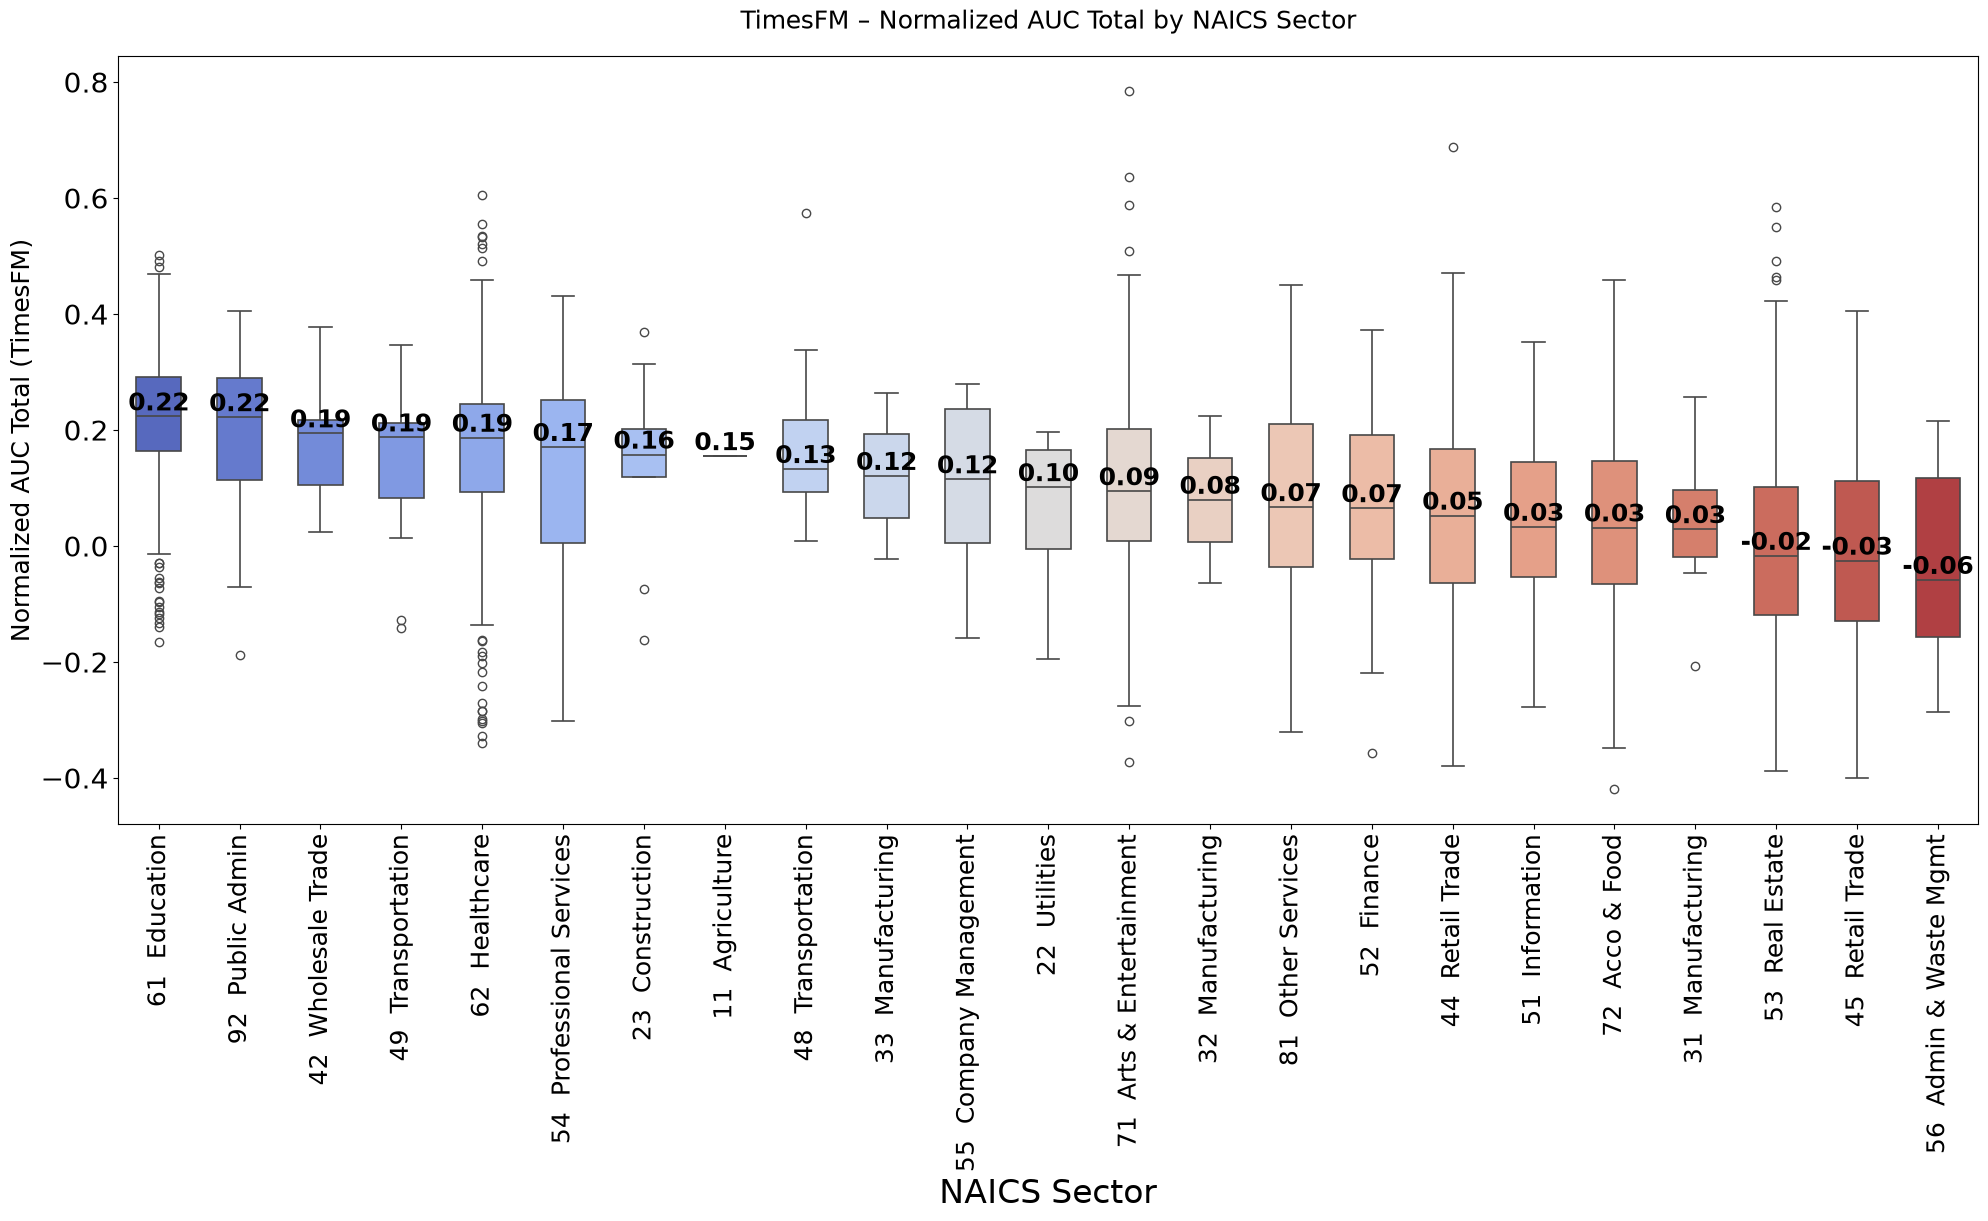

In [31]:
# ------------------------------------------------------------
# 0) Load merged_df if not defined (Jupyter cell order safety)
# ------------------------------------------------------------
try:
    _ = merged_df
except NameError:
    import os
    import glob
    import pandas as pd
    folder = None
    try:
        if os.path.exists(outputs_dir):
            folder = outputs_dir
    except NameError:
        pass
    if not folder:
        results_folders = sorted(glob.glob("results_*"))
        if results_folders:
            folder = results_folders[-1]
    if folder:
        path_anc = os.path.join(folder, "predictions", "test_timesfm_ancilary.csv")
        path_pred = os.path.join(folder, "predictions", "test_timesfm.csv")
        if not os.path.exists(path_anc):
            path_anc = os.path.join(folder, "outputs", "predictions", "test_timesfm_ancilary.csv")
        if not os.path.exists(path_pred):
            path_pred = os.path.join(folder, "outputs", "predictions", "test_timesfm.csv")
        if os.path.exists(path_anc) and os.path.exists(path_pred):
            df_anc = pd.read_csv(path_anc)
            df_pred = pd.read_csv(path_pred)
            cols_to_drop = [c for c in df_anc.columns if c.startswith("sarimax_") or c.startswith("prophet_")]
            clean_df = df_anc.drop(columns=cols_to_drop, errors="ignore")
            pred_cols = ["placekey", "timesfm_mae", "timesfm_rmse", "timesfm_r2",
                         "timesfm_auc_pos", "timesfm_auc_neg", "timesfm_auc_total",
                         "test_dates", "test_true_list", "test_pred_list", "timesfm_ok"]
            pred_cols = [c for c in pred_cols if c in df_pred.columns]
            merged_df = clean_df.merge(df_pred[pred_cols], on="placekey", how="inner")
            print(f"[info] Dynamically loaded merged_df from: {folder}")
        elif os.path.exists(path_pred):
            merged_df = pd.read_csv(path_pred)
            print(f"[info] Dynamically loaded merged_df from test_timesfm.csv: {path_pred}")
        else:
            raise FileNotFoundError(f"Could not find Test_timesfm.csv in {folder}.")
    else:
        raise NameError("NameError: merged_df is not defined and no results_* folder could be found.")

# ------------------------------------------------------------
# 1) Prepare NAICS codes
# ------------------------------------------------------------
merged_df["naics_code_str"] = merged_df["naics_code"].astype(str).str.zfill(6)
merged_df["naics_2d"] = merged_df["naics_code_str"].str[:2]

# ------------------------------------------------------------
# 2) Provide your NAICS names here (ONLY names you want shown)
# ------------------------------------------------------------
naics_names = {
    "61": "Education",
    "92": "Public Admin",
    "42": "Wholesale Trade",
    "49": "Transportation",
    "62": "Healthcare",
    "23": "Construction",
    "11": "Agriculture",
    "54": "Professional Services",
    "55": "Company Management",
    "71": "Arts & Entertainment",
    "48": "Transportation",
    "52": "Finance",
    "33": "Manufacturing",
    "81": "Other Services",
    "44": "Retail Trade",
    "22": "Utilities",
    "72": "Acco & Food",
    "31": "Manufacturing",
    "32": "Manufacturing",
    "51": "Information",
    "45": "Retail Trade",
    "53": "Real Estate",
    "56": "Admin & Waste Mgmt"
}

# ------------------------------------------------------------
# Remove sectors that do NOT have names
# ------------------------------------------------------------
merged_df = merged_df[merged_df["naics_2d"].isin(naics_names.keys())]

# ------------------------------------------------------------
# 3) Sort NAICS sectors by MEDIAN TimesFM AUC
# ------------------------------------------------------------
median_order = (
    merged_df.groupby("naics_2d")["timesfm_auc_total"]
    .median()
    .sort_values(ascending=False)
    .index
)

# ------------------------------------------------------------
# 4) Build custom colormap (coolwarm like your example)
# ------------------------------------------------------------
colors = sns.color_palette("coolwarm", n_colors=len(median_order))
palette_dict = {sector: color for sector, color in zip(median_order, colors)}

# ------------------------------------------------------------
# 5) Start plot
# ------------------------------------------------------------
plt.figure(figsize=(24, 16))

ax = sns.boxplot(
    data=merged_df,
    x="naics_2d",
    y="timesfm_auc_total",
    order=median_order,
    palette=palette_dict,
    width=0.55,
    linewidth=1.2
)
ax.tick_params(axis='y', labelsize=20)

# ------------------------------------------------------------
# 6) Add number labels (median values)
# ------------------------------------------------------------
# ------------------------------------------------------------
# Add median text WITHOUT white background
# ------------------------------------------------------------
medians = merged_df.groupby("naics_2d")["timesfm_auc_total"].median()

for i, sector in enumerate(median_order):
    median_val = medians.loc[sector]
    ax.text(
        i,
        median_val,
        f"{median_val:.2f}",
        ha="center",
        va="bottom",
        fontsize=18,
        color="black",
        fontweight="bold"
    )


# ------------------------------------------------------------
# 7) Build EXACT x-tick text:  "61  Education"
# ------------------------------------------------------------
tick_labels = [
    f"{sec}  {naics_names.get(sec, '')}"
    for sec in median_order
]

ax.set_xticks(range(len(median_order)))
ax.set_xticklabels(
    tick_labels,
    rotation=90,
    ha="center",
    va='top',
    fontsize=18
)



# Add bottom padding so labels don't hit x-axis
plt.subplots_adjust(bottom=0.40)

# ------------------------------------------------------------
# 8) Titles
# ------------------------------------------------------------
ax.set_title("TimesFM – Normalized AUC Total by NAICS Sector", fontsize=18, pad=20)
ax.set_xlabel("NAICS Sector", fontsize=24)
ax.set_ylabel("Normalized AUC Total (TimesFM)", fontsize=18)
plt.savefig(os.path.join(figures_dir, "statistics", "timesfm_naics_boxplot.pdf"), format="pdf", bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "statistics", "timesfm_naics_boxplot.png"), dpi=150, bbox_inches="tight")

plt.show()

### Further investigation of AUC for several Business sectors


Health Care subgroup summary:
         healthcare_group    n      mean    median       std        q1  \
2  623 Nursing Facilities    6  0.199831  0.211033  0.097190  0.183036   
0     621 Ambulatory Care  354  0.154335  0.179446  0.151086  0.085501   
1           622 Hospitals   62  0.160885  0.171460  0.138658  0.090913   

         q3       min       max       iqr  
2  0.225441  0.036206  0.336763  0.042405  
0  0.242408 -0.339391  0.605123  0.156906  
1  0.258068 -0.136334  0.447957  0.167155  

Education subgroup summary:
                education_group    n      mean    median       std        q1  \
0   6111 Elementary & Secondary  353  0.253092  0.249060  0.085385  0.194039   
1  6113 Colleges & Universities   88  0.118345  0.122282  0.115605  0.058129   

         q3       min       max       iqr  
0  0.308432 -0.064655  0.501177  0.114394  
1  0.195723 -0.166267  0.421253  0.137594  


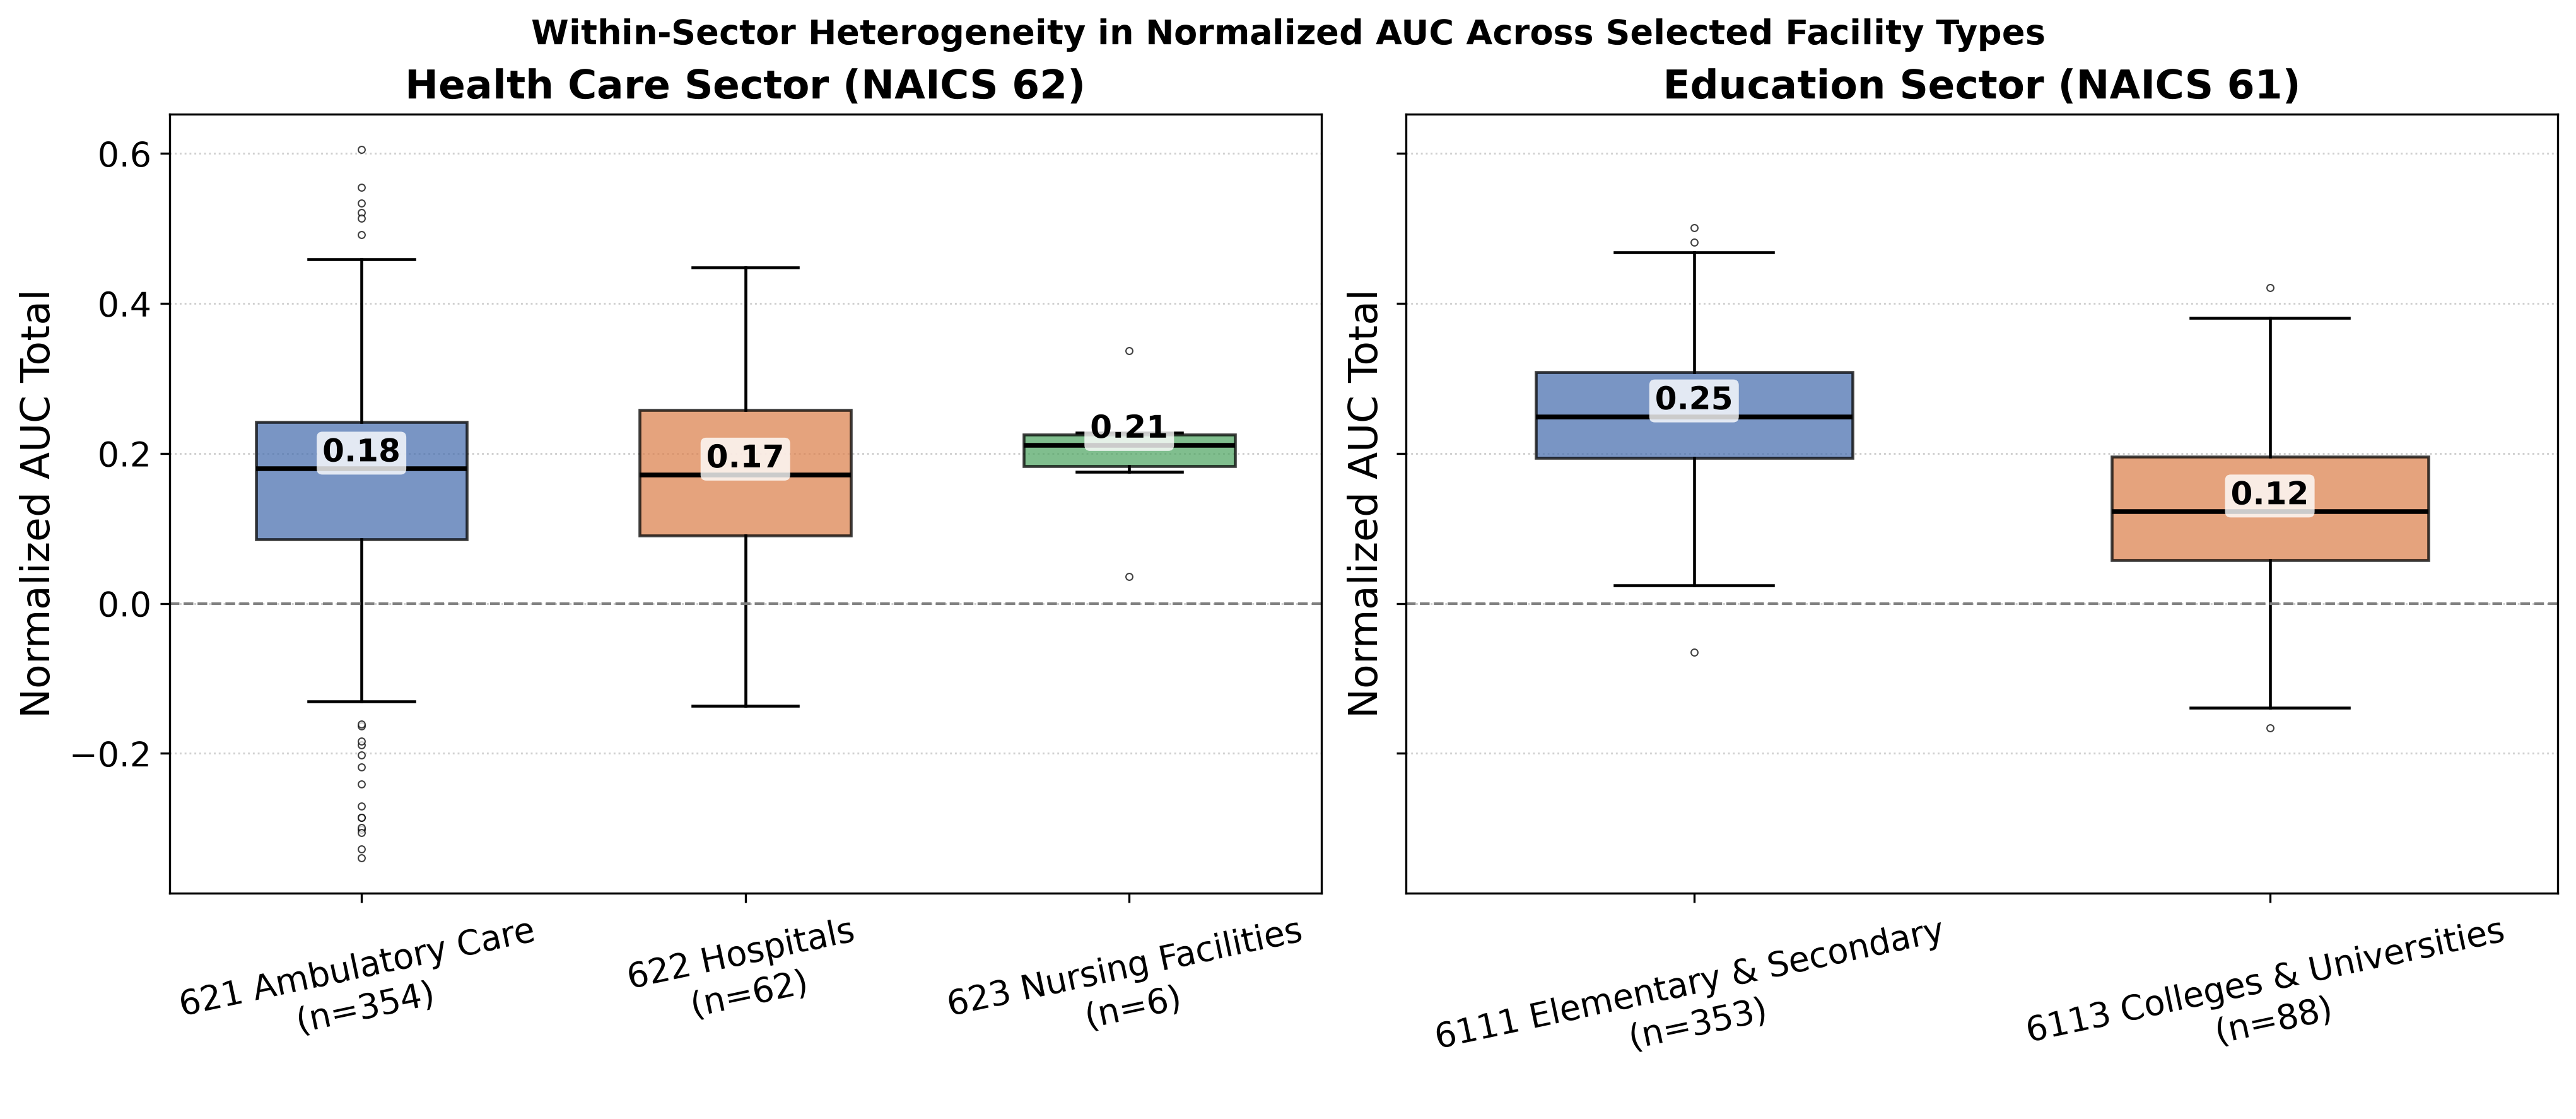


Saved figure to: results_2026-06-30_23-59-42\statistics\figure_subsector_boxplots_healthcare_education.pdf


In [32]:

# -----------------------------
# 1) Prepare data
# -----------------------------
import os
plot_df = df1[['naics_code', 'timesfm_auc_total']].copy()

# Keep digits only from NAICS
plot_df['naics_code'] = (
    plot_df['naics_code']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

plot_df = plot_df.dropna(subset=['naics_code', 'timesfm_auc_total']).copy()
plot_df['timesfm_auc_total'] = pd.to_numeric(plot_df['timesfm_auc_total'], errors='coerce')
plot_df = plot_df.dropna(subset=['timesfm_auc_total']).copy()

# -----------------------------
# 2) Define subgroup mappings
# -----------------------------
def classify_healthcare(code: str):
    if code.startswith('621'):
        return '621 Ambulatory Care'
    elif code.startswith('622'):
        return '622 Hospitals'
    elif code.startswith('623'):
        return '623 Nursing Facilities'
    return np.nan

def classify_education(code: str):
    if code.startswith('611110') or code.startswith('61111') or code.startswith('6111'):
        return '6111 Elementary & Secondary'
    elif code.startswith('611310') or code.startswith('61131') or code.startswith('6113'):
        return '6113 Colleges & Universities'
    elif code.startswith('611710') or code.startswith('61171') or code.startswith('6117'):
        return '6117 Educational Support'
    return np.nan

plot_df['healthcare_group'] = plot_df['naics_code'].apply(classify_healthcare)
plot_df['education_group'] = plot_df['naics_code'].apply(classify_education)

# -----------------------------
# 3) Summaries
# -----------------------------
def summarize_groups(data, group_col):
    out = (
        data.dropna(subset=[group_col])
            .groupby(group_col)['timesfm_auc_total']
            .agg(
                n='count',
                mean='mean',
                median='median',
                std='std',
                q1=lambda x: x.quantile(0.25),
                q3=lambda x: x.quantile(0.75),
                min='min',
                max='max'
            )
            .reset_index()
    )
    out['iqr'] = out['q3'] - out['q1']
    return out

health_summary = summarize_groups(plot_df, 'healthcare_group')
edu_summary = summarize_groups(plot_df, 'education_group')

print("\nHealth Care subgroup summary:")
print(health_summary.sort_values('median', ascending=False))

print("\nEducation subgroup summary:")
print(edu_summary.sort_values('median', ascending=False))

# -----------------------------
# 4) Plot helper
# -----------------------------
def build_panel(ax, data, group_col, title, desired_order):
    sub = data.dropna(subset=[group_col]).copy()

    # Keep only groups that exist
    groups_present = [g for g in desired_order if g in sub[group_col].unique()]
    if len(groups_present) == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=11)
        ax.set_title(title, fontsize=12, weight='bold')
        ax.axis('off')
        return

    box_data = [sub.loc[sub[group_col] == g, 'timesfm_auc_total'].values for g in groups_present]
    counts = [len(x) for x in box_data]
    medians = [np.median(x) for x in box_data]

    labels = [f"{g}\n(n={n})" for g, n in zip(groups_present, counts)]

    boxplot_kwargs = {
        'patch_artist': True,
        'widths': 0.55,
        'showfliers': True,
        'medianprops': dict(linewidth=1.8, color='black'),
        'whiskerprops': dict(linewidth=1.1),
        'capprops': dict(linewidth=1.1),
        'boxprops': dict(linewidth=1.1),
        'flierprops': dict(
            marker='o',
            markersize=2.6,
            markerfacecolor='white',
            markeredgewidth=0.5,
            alpha=0.75
        )
    }
    try:
        bp = ax.boxplot(box_data, labels=labels, **boxplot_kwargs)
    except TypeError:
        bp = ax.boxplot(box_data, tick_labels=labels, **boxplot_kwargs)

    # Soft grayscale palette for publication friendliness
    facecolors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
    for patch, c in zip(bp['boxes'], facecolors[:len(groups_present)]):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)

    # Median annotations
    for i, med in enumerate(medians, start=1):
        ax.text(
            i,
            med,
            f"{med:.2f}",
            ha='center',
            va='bottom' if med >= 0 else 'top',
            fontsize=12,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.8)
        )

    ax.axhline(0, linestyle='--', linewidth=1.0, color='gray')
    ax.set_title(title, fontsize=15, weight='bold')
    ax.set_ylabel('Normalized AUC Total', fontsize=15)
    ax.tick_params(axis='x', labelrotation=12, labelsize=13)
    ax.tick_params(axis='y', labelsize=13)

    # Light grid
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.6)

# -----------------------------
# 5) Create single publication-style figure
# -----------------------------
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 20,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, axes = plt.subplots(
    1, 2,
    figsize=(13.5, 5.8),
    sharey=True,
    constrained_layout=True
)

health_order = [
    '621 Ambulatory Care',
    '622 Hospitals',
    '623 Nursing Facilities'
]

edu_order = [
    '6111 Elementary & Secondary',
    '6113 Colleges & Universities',
    '6117 Educational Support'
]

build_panel(
    axes[0],
    plot_df,
    'healthcare_group',
    'Health Care Sector (NAICS 62)',
    health_order
)

build_panel(
    axes[1],
    plot_df,
    'education_group',
    'Education Sector (NAICS 61)',
    edu_order
)

fig.suptitle(
    'Within-Sector Heterogeneity in Normalized AUC Across Selected Facility Types',
    fontsize=13,
    fontweight='bold'
)

# Save as PDF
out_pdf = os.path.join(figures_dir, "statistics", "figure_subsector_boxplots_healthcare_education.pdf")
plt.savefig(out_pdf, bbox_inches='tight')
plt.savefig(out_pdf.replace('.pdf', '.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved figure to: {out_pdf}")

### AUC at business county level

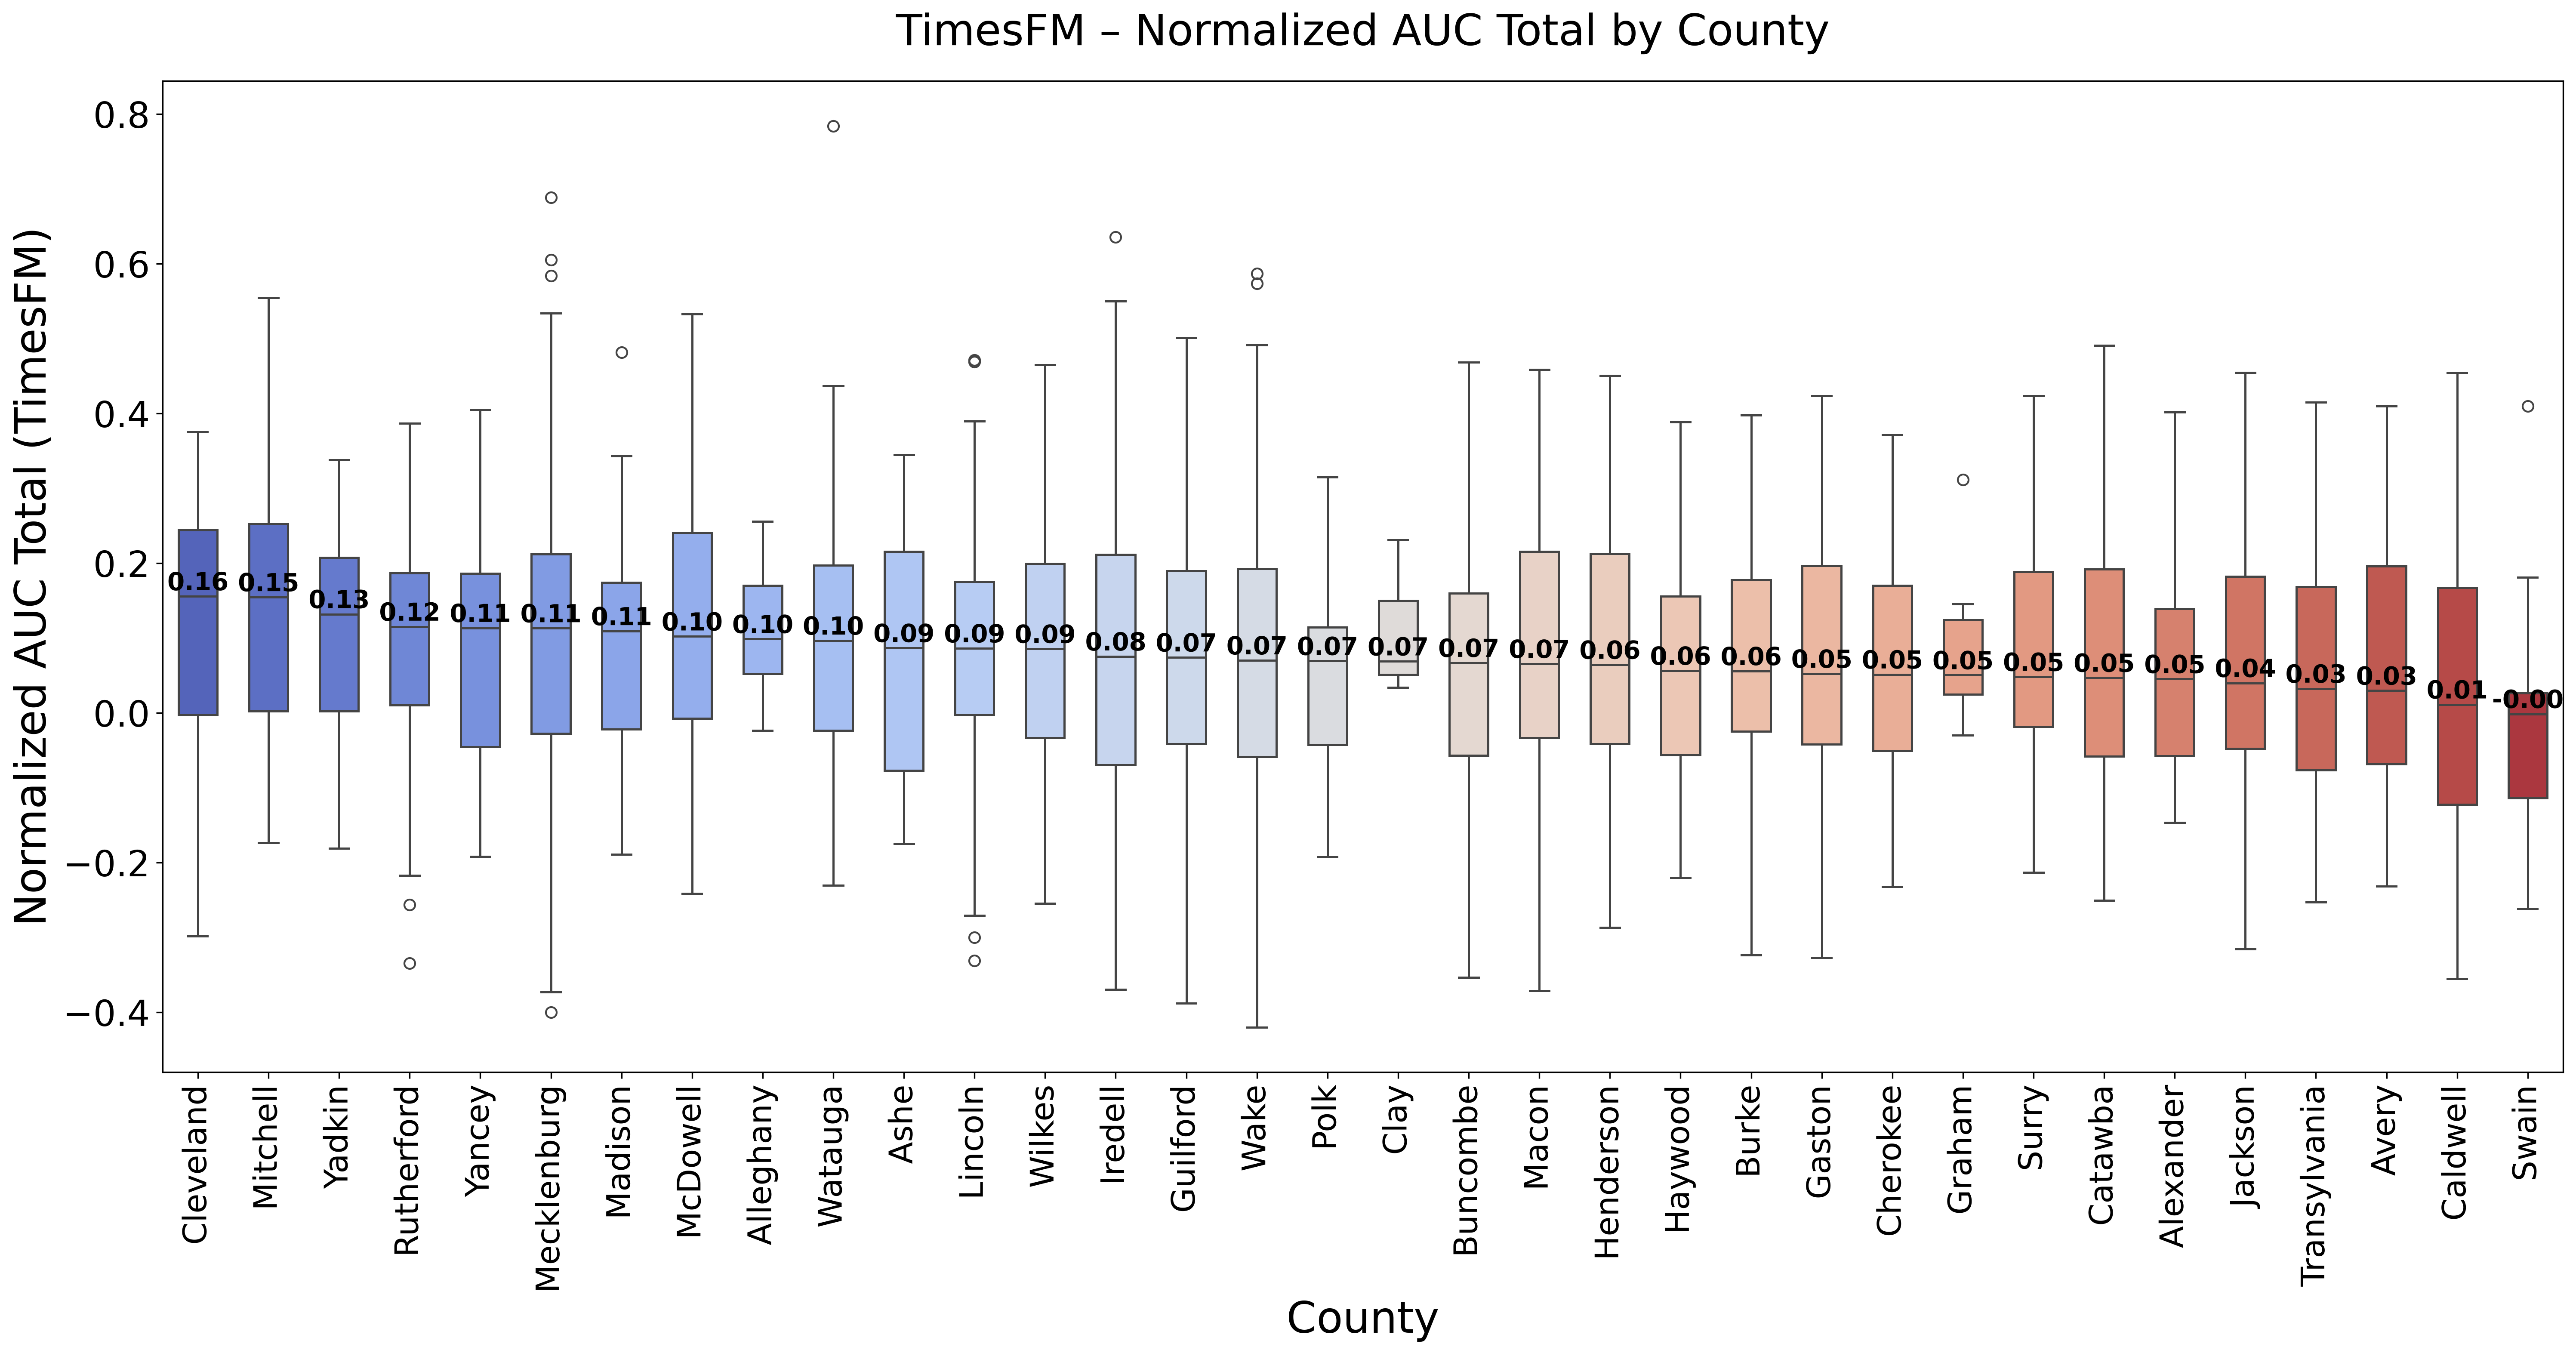

In [33]:

# ------------------------------------------------------------
# 1) Remove NAICS logic — now we group by COUNTY
# ------------------------------------------------------------
# Keep only counties that exist in the dataset
import os
counties = merged_df["County"].unique()

# ------------------------------------------------------------
# 2) Sort counties by MEDIAN TimesFM AUC (descending)
# ------------------------------------------------------------
median_order = (
    merged_df.groupby("County")["timesfm_auc_total"]
    .median()
    .sort_values(ascending=False)
    .index
)

# ------------------------------------------------------------
# 3) Build custom colormap (coolwarm like your original figure)
# ------------------------------------------------------------
colors = sns.color_palette("coolwarm", n_colors=len(median_order))
palette_dict = {County: color for County, color in zip(median_order, colors)}

# ------------------------------------------------------------
# 4) Start plot
# ------------------------------------------------------------
plt.figure(figsize=(24, 16))

ax = sns.boxplot(
    data=merged_df,
    x="County",
    y="timesfm_auc_total",
    order=median_order,
    palette=palette_dict,
    width=0.55,
    linewidth=1.2
)
ax.tick_params(axis='y', labelsize=20)

# ------------------------------------------------------------
# 5) Add median labels (NO white background)
# ------------------------------------------------------------
medians = merged_df.groupby("County")["timesfm_auc_total"].median()

for i, County in enumerate(median_order):
    median_val = medians.loc[County]
    ax.text(
        i,
        median_val,
        f"{median_val:.2f}",
        ha="center",
        va="bottom",
        fontsize=14,
        color="black",
        fontweight="bold"
    )

# ------------------------------------------------------------
# 6) Clean xtick labels
# (just the county names, rotated like NAICS labels)
# ------------------------------------------------------------
tick_labels = [str(county) for county in median_order]

ax.set_xticks(range(len(median_order)))
ax.set_xticklabels(
    tick_labels,
    rotation=90,
    ha="center",
    va="top",        # keeps text above axis, not below
    fontsize=18
)

plt.subplots_adjust(bottom=0.40)

# ------------------------------------------------------------
# 7) Titles & labels
# ------------------------------------------------------------
ax.set_title("TimesFM – Normalized AUC Total by County", fontsize=24, pad=20)
ax.set_xlabel("County", fontsize=24)
ax.set_ylabel("Normalized AUC Total (TimesFM)", fontsize=24)

# ------------------------------------------------------------
# 8) Save PDF
# ------------------------------------------------------------
plt.savefig(os.path.join(figures_dir, "statistics", "timesfm_county_boxplot.pdf"), format="pdf", bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "statistics", "timesfm_county_boxplot.png"), dpi=150, bbox_inches="tight")

plt.show()

# Add ancillary data and generate plots for paper

First, we ensure we have the summary_df loaded

In [9]:
# ------------------------------------------------------------
# Load final_summary_df with auto-locating outputs_dir (Jupyter kernel restart safety)
# ------------------------------------------------------------
try:
    _ = final_summary_df
    _SKIP_ANCILLARY = "elevation_m" in final_summary_df.columns
    print(f"[info] final_summary_df is already defined in memory. Skip ancillary? {_SKIP_ANCILLARY}")
except NameError:
    import os
    import glob
    import pandas as pd

    # Resolve outputs_dir if not in namespace
    try:
        _ = outputs_dir
    except NameError:
        results_folders = sorted(glob.glob("results_*"))
        if results_folders:
            outputs_dir = results_folders[-1]
            figures_dir = outputs_dir
            print(f"[info] Automatically set outputs_dir to latest run: {outputs_dir}")
        else:
            raise FileNotFoundError("Could not find any results_* folder on disk.")

    # First check if the fully-merged ancillary file exists
    anc_path = os.path.join(outputs_dir, "predictions", "test_timesfm_ancilary.csv")
    if not os.path.exists(anc_path):
        anc_path = os.path.join(outputs_dir, "outputs", "predictions", "test_timesfm_ancilary.csv")

    if os.path.exists(anc_path):
        final_summary_df = pd.read_csv(anc_path)
        _SKIP_ANCILLARY = False
        print(f"✅ Loaded final_summary_df from existing ancillary file: {anc_path} (Shape: {final_summary_df.shape})")
        print("Ancillary features (elevation, road closures, precipitation) are already compiled. Subsequent cells will be skipped.")
    else:
        _SKIP_ANCILLARY = False
        csv_path = os.path.join(outputs_dir, "predictions", "test_timesfm.csv")
        if not os.path.exists(csv_path):
            csv_path = os.path.join(outputs_dir, "outputs", "predictions", "test_timesfm.csv")
        
        if os.path.exists(csv_path):
            final_summary_df = pd.read_csv(csv_path)
            print(f"Loaded raw predictions into final_summary_df: {csv_path} (Shape: {final_summary_df.shape})")
        else:
            raise FileNotFoundError(f"Could not find predictions file in {outputs_dir}.")

final_summary_df.head()


✅ Loaded final_summary_df from existing ancillary file: results_latest\predictions\test_timesfm_ancilary.csv (Shape: (5671, 35))
Ancillary features (elevation, road closures, precipitation) are already compiled. Subsequent cells will be skipped.


,Unnamed: 0,placekey,latitude,longitude,naics_code,city,region,GEOID,County,mean_per_day,...,precip_20240925,precip_20240926,precip_20240927,precip_20240928,precip_20240929,precip_sum_week,precip_mean_week,precip_max_week,road_closure_dist_closest,road_closure_dist_second_closest
0,0,zzy-226@63g-2dz-kcq,36.099589,-79.778028,3231,Greensboro,NC,3.708101e+11,Guilford,39.785714,...,1.291339,0.220472,0.468504,0.921260,0.0,4.440945,0.634421,1.539370,77.896505,117.777972
1,1,229-222@8gf-r5g-2hq,35.594863,-82.550944,5412,Asheville,NC,3.702100e+11,Buncombe,74.220497,...,0.311024,7.279527,4.370079,1.157480,0.0,13.279527,1.897075,7.279527,16.247025,22.852251
2,2,22b-222@8gf-dk3-d35,35.224164,-81.036060,5615,Belmont,NC,3.707103e+11,Gaston,156.156832,...,0.905512,0.555118,5.476377,0.685039,0.0,7.622047,1.088864,5.476377,54.347037,64.226972
3,3,229-225@8gf-fnx-kxq,35.445106,-80.880242,311811,Huntersville,NC,3.711901e+11,Mecklenburg,112.459627,...,1.826772,0.228346,4.866142,0.417323,0.0,7.354331,1.050619,4.866142,47.016981,71.938574
4,4,zzw-223@8gg-b7s-b6k,35.631602,-81.379969,445120,Hickory,NC,3.703501e+11,Catawba,55.563665,...,1.362205,1.027559,4.307086,0.956693,0.0,7.704724,1.100675,4.307086,4.260887,31.733071


## Add Elevation Data

In [36]:
if not globals().get("_SKIP_ANCILLARY", False):
    import requests
    import time
    import pandas as pd
    from tqdm import tqdm

    # Initialize elevation_m column if it doesn't exist yet (from previous cell)
    if "elevation_m" not in final_summary_df.columns:
        final_summary_df["elevation_m"] = None

    url_base = "https://api.opentopodata.org/v1/aster30m"

    def fetch_one_elevation(lat, lon, timeout=30):
        url = f"{url_base}?locations={lat},{lon}"
        response = requests.get(url, timeout=timeout)
        data = response.json()

        if data.get("status") == "OK":
            return data["results"][0].get("elevation", None)
        else:
            raise ValueError(data)

    n_retries = 5
    sleep_between_retries = 1.0

    missing_idx = final_summary_df.index[
        final_summary_df["elevation_m"].isna()
    ].tolist()

    retry_failures = []

    for idx in tqdm(missing_idx, desc="Fetching/Retrying elevations"):
        lat = final_summary_df.loc[idx, "latitude"]
        lon = final_summary_df.loc[idx, "longitude"]

        # Skip clearly invalid/NaN coordinates (from previous cell)
        if pd.isna(lat) or pd.isna(lon) or not (-90 <= lat <= 90) or not (-180 <= lon <= 180):
            retry_failures.append({
                "row_index": idx,
                "latitude": lat,
                "longitude": lon,
                "error": "invalid coordinate"
            })
            continue

        lat = round(lat, 6)
        lon = round(lon, 6)

        success = False
        last_error = None

        for attempt in range(1, n_retries + 1):
            try:
                elevation = fetch_one_elevation(lat, lon)

                if elevation is not None:
                    final_summary_df.loc[idx, "elevation_m"] = elevation
                    success = True
                    break
                else:
                    last_error = "Returned None"

            except Exception as e:
                last_error = str(e)

            time.sleep(sleep_between_retries * attempt)  # increasing wait

        if not success:
            retry_failures.append({
                "row_index": idx,
                "latitude": lat,
                "longitude": lon,
                "error": last_error
            })

    retry_failures_df = pd.DataFrame(retry_failures)

    print("Still missing elevation values:", final_summary_df["elevation_m"].isna().sum())
    print("Still failed rows:", len(retry_failures_df))

    # Convert to numeric float64 to ensure continuous plotting behavior
    final_summary_df["elevation_m"] = pd.to_numeric(final_summary_df["elevation_m"], errors="coerce")

    if not retry_failures_df.empty:
        print(retry_failures_df.head())


Fetching/Retrying elevations: 100%|██████████| 5671/5671 [1:34:29<00:00,  1.00it/s]

Still missing elevation values: 0
Still failed rows: 0


In [37]:
if not globals().get("_SKIP_ANCILLARY", False):
    final_summary_df['elevation_m'].isna().sum() #2200 NA values; some POIs cannot receive that info.

##  Add Precipitation Data (this requires that tiff files be located in Geo-datasets subfolder)

In [38]:
if not globals().get("_SKIP_ANCILLARY", False):
    raster_folder = "data/geospatial/nws_precipitation"
    start_date = datetime.strptime('20240923', '%Y%m%d')
    dates = [start_date + timedelta(days=i) for i in range(7)]


In [39]:
import os
if not globals().get("_SKIP_ANCILLARY", False):
    # Prepare (lon, lat) tuples
    points = list(zip(final_summary_df['longitude'], final_summary_df['latitude']))

    # Loop through each raster date
    for date in tqdm(dates, desc="Extracting precipitation"):
        date_str = date.strftime('%Y%m%d')
        filename = f'nws_precip_1day_{date_str}_conus.tif'
        raster_path = os.path.join(raster_folder, filename)

        with rasterio.open(raster_path) as src:
            array = src.read(1)
            array = np.where(array < 0, np.nan, array)

            # Transform points to raster CRS
            raster_crs = src.crs
            poi_gdf = gpd.GeoDataFrame(final_summary_df, geometry=gpd.points_from_xy(final_summary_df.longitude, final_summary_df.latitude), crs="EPSG:4326")
            
            if raster_crs is not None:
                poi_proj = poi_gdf.to_crs(raster_crs)
                xy_proj = [(point.x, point.y) for point in poi_proj.geometry]
            else:
                # If no CRS, assume coordinates are already matching the raster's grid (geographic)
                print(f"[warning] Raster {filename} has no CRS defined. Using raw EPSG:4326 coordinates.")
                xy_proj = list(zip(final_summary_df['longitude'], final_summary_df['latitude']))

            # Sample raster
            sampled = list(src.sample(xy_proj))
            sampled_vals = [float(v[0]) if v[0] >= 0 else np.nan for v in sampled]
            final_summary_df[f'precip_{date_str}'] = sampled_vals


Extracting precipitation: 100%|██████████| 7/7 [00:04<00:00,  1.45it/s]


In [40]:
if not globals().get("_SKIP_ANCILLARY", False):
    final_summary_df["precip_sum_week"] = final_summary_df[[f"precip_{d.strftime('%Y%m%d')}" for d in dates]].sum(axis=1)
    final_summary_df["precip_mean_week"] = final_summary_df[[f"precip_{d.strftime('%Y%m%d')}" for d in dates]].mean(axis=1)
    # List of daily precipitation columns
    precip_cols = [f"precip_{d.strftime('%Y%m%d')}" for d in dates]
    # Compute max precipitation over the week
    final_summary_df["precip_max_week"] = final_summary_df[precip_cols].max(axis=1)


In [41]:
final_summary_df.shape

(5671, 32)

##  Add Road Closure Data

In [10]:
if not globals().get("_SKIP_ANCILLARY", False):
    import os
    import pandas as pd
    
    road_excel_path = "data/raw/RoadClosureIncidents.xlsx"
    use_fallback_road_data = False
    road_df = None
    
    # Try reading the Excel file first
    if os.path.exists(road_excel_path):
        try:
            road_df = pd.read_excel(road_excel_path)
            # Ensure datetime format and filter for 2024 events
            road_df['StartTime (ET)'] = pd.to_datetime(road_df['StartTime (ET)'], errors='coerce')
            road_df = road_df[road_df['StartTime (ET)'].dt.year == 2024]
            # Keep necessary columns
            road_df = road_df[['IncidentId', 'Latitude', 'Longitude']]
            print(f"Filtered {len(road_df)} rows from the dataframe.")
        except Exception as e:
            print(f"[warning] Failed to read Excel: {e}. Falling back to pre-calculated road closures CSV.")
            use_fallback_road_data = True
    else:
        print("[info] RoadClosureIncidents.xlsx not found. Falling back to pre-calculated road closures CSV.")
        use_fallback_road_data = True

    # Fallback to loading pre-calculated values from CSV if Excel is missing or fails
    if use_fallback_road_data:
        ancillary_candidates = [
            "data/raw/summary_metrics_western_nc_v3_ancilary.csv",
            "data/predictions/Test_timesfm_ancilary.csv",
            "results/summary_metrics_western_nc_v3_ancilary.csv"
        ]
        loaded_ancillary = False
        for cand in ancillary_candidates:
            if os.path.exists(cand):
                try:
                    v3_ancil = pd.read_csv(cand)
                    if "placekey" in v3_ancil.columns and "road_closure_dist_closest" in v3_ancil.columns:
                        road_dist_df = v3_ancil[["placekey", "road_closure_dist_closest", "road_closure_dist_second_closest"]].copy()
                        road_dist_df = road_dist_df.drop_duplicates(subset=["placekey"])
                        
                        # Merge onto final_summary_df, dropping columns first if they already exist
                        cols_to_drop = [c for c in ["road_closure_dist_closest", "road_closure_dist_second_closest"] if c in final_summary_df.columns]
                        if cols_to_drop:
                            final_summary_df = final_summary_df.drop(columns=cols_to_drop)
                        
                        final_summary_df = final_summary_df.merge(road_dist_df, on="placekey", how="left")
                        print(f"[info] Successfully loaded road closure distances from: {cand}")
                        loaded_ancillary = True
                        break
                except Exception as ex:
                    print(f"[warning] Could not load from {cand}: {ex}")
        if not loaded_ancillary:
            print("[error] Could not load road closure distances from any backup CSV candidates!")


Filtered 37 rows from the dataframe.


In [11]:
if not globals().get("_SKIP_ANCILLARY", False):

    def haversine_np(lat1, lon1, lat2, lon2):
        R = 6371  # Earth radius in km

        lat1 = np.radians(lat1)
        lon1 = np.radians(lon1)
        lat2 = np.radians(lat2)
        lon2 = np.radians(lon2)

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        
        return R * c  # in kilometers


In [12]:
if not globals().get("_SKIP_ANCILLARY", False):
    # Ensure fallback flag is defined
    if 'use_fallback_road_data' not in globals():
        use_fallback_road_data = True

    # Robust check: only compute if road_df is defined and we are not using fallback data
    if 'road_df' in globals() and road_df is not None and not use_fallback_road_data:
        # Store closures as arrays for fast broadcasting
        rc_lat = road_df['Latitude'].values
        rc_lon = road_df['Longitude'].values

        poi_lat = final_summary_df['latitude'].values
        poi_lon = final_summary_df['longitude'].values

        closest_distances = []
        second_closest_distances = []

        for lat, lon in zip(poi_lat, poi_lon):
            distances = haversine_np(lat, lon, rc_lat, rc_lon)
            sorted_dists = np.sort(distances)
            closest_distances.append(sorted_dists[0])
            second_closest_distances.append(sorted_dists[1] if len(sorted_dists) > 1 else np.nan)

        final_summary_df['road_closure_dist_closest'] = closest_distances
        final_summary_df['road_closure_dist_second_closest'] = second_closest_distances
        print("[info] Recalculated road closure distances successfully.")
    else:
        # If columns already exist, skip cleanly. Otherwise attempt load from backup.
        if 'road_closure_dist_closest' in final_summary_df.columns:
            print("[info] Skipping calculation: road closure columns already present in final_summary_df.")
        else:
            print("[warning] road_df is missing or fallback is enabled. Attempting fallback load from CSV...")
            import os
            import pandas as pd
            ancillary_candidates = [
                "data/raw/summary_metrics_western_nc_v3_ancilary.csv",
                "../data/raw/summary_metrics_western_nc_v3_ancilary.csv",
                "../../data/raw/summary_metrics_western_nc_v3_ancilary.csv",
                "data/predictions/test_timesfm_ancilary.csv"
            ]
            loaded_ancillary = False
            for cand in ancillary_candidates:
                if os.path.exists(cand):
                    try:
                        v3_ancil = pd.read_csv(cand)
                        if "placekey" in v3_ancil.columns and "road_closure_dist_closest" in v3_ancil.columns:
                            road_dist_df = v3_ancil[["placekey", "road_closure_dist_closest", "road_closure_dist_second_closest"]].copy()
                            road_dist_df = road_dist_df.drop_duplicates(subset=["placekey"])
                            cols_to_drop = [c for c in ["road_closure_dist_closest", "road_closure_dist_second_closest"] if c in final_summary_df.columns]
                            if cols_to_drop:
                                final_summary_df = final_summary_df.drop(columns=cols_to_drop)
                            final_summary_df = final_summary_df.merge(road_dist_df, on="placekey", how="left")
                            print(f"[info] Successfully loaded road closure distances from: {cand}")
                            loaded_ancillary = True
                            break
                    except Exception as ex:
                        pass
            if not loaded_ancillary:
                print("[error] Could not load road closure distances from any backup CSV candidates!")


[info] Recalculated road closure distances successfully.


In [13]:
import os
if not globals().get("_SKIP_ANCILLARY", False):
    # final_summary_df.to_csv('./results/summary_metrics_western_nc_v3_ancilary.csv')
    final_summary_df.to_csv(os.path.join(outputs_dir, "predictions", "test_timesfm_ancilary.csv"))


## Generate Plots for Paper

In [14]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
try:
    import contextily as cx
except ImportError:
    cx = None
import os

# Ensure road_df is initialized in globals to prevent NameError
if 'road_df' not in globals():
    road_df = None

# Convert road_df to GeoDataFrame (with dynamic loading fallback)
try:
    if road_df is None:
        # Try relative paths
        for path_cand in ["data/raw/RoadClosureIncidents.xlsx", "../data/raw/RoadClosureIncidents.xlsx", "../../data/raw/RoadClosureIncidents.xlsx"]:
            if os.path.exists(path_cand):
                road_df = pd.read_excel(path_cand)
                road_df['StartTime (ET)'] = pd.to_datetime(road_df['StartTime (ET)'], errors='coerce')
                road_df = road_df[road_df['StartTime (ET)'].dt.year == 2024][['IncidentId', 'Latitude', 'Longitude']]
                print(f"[info] Dynamically loaded road_df from: {path_cand}")
                break
except Exception as e:
    print(f"[warning] Could not load road_df: {e}")
    road_df = None

if road_df is not None and len(road_df) > 0:
    gdf_rc = gpd.GeoDataFrame(
        road_df,
        geometry=gpd.points_from_xy(road_df['Longitude'], road_df['Latitude']),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)
else:
    gdf_rc = None
    print("[info] gdf_rc is set to None (road_df is missing or empty)")

# Always convert POIs to GeoDataFrame
gdf_poi = gpd.GeoDataFrame(
    final_summary_df,
    geometry=gpd.points_from_xy(final_summary_df['longitude'], final_summary_df['latitude']),
    crs="EPSG:4326"
).to_crs(epsg=3857)


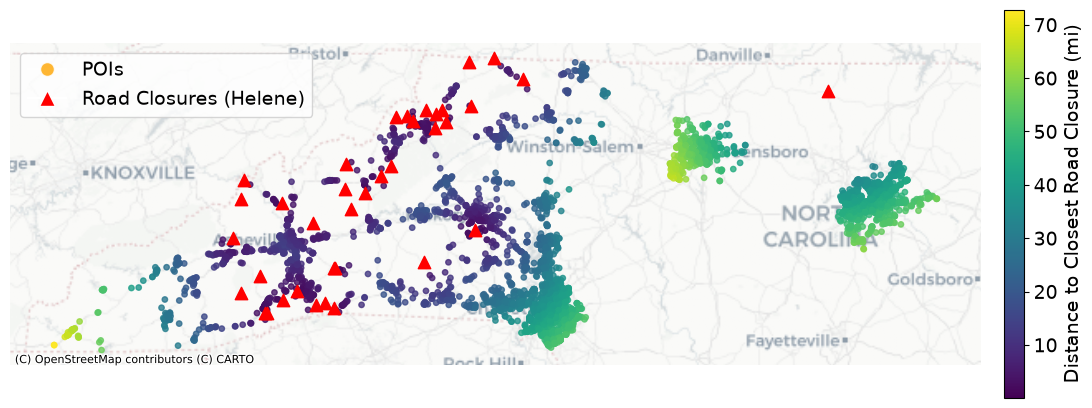

In [20]:
# Remove outlier closure point (manually filter longitudes east of -75 or similar)
# road_df = road_df[road_df['Longitude'] < -80]  # Adjust threshold if needed
import os
if 'road_closure_dist_closest' in gdf_poi.columns:
    gdf_poi['road_closure_dist_closest_miles'] = pd.to_numeric(gdf_poi['road_closure_dist_closest'], errors='coerce') * 0.621371
else:
    gdf_poi['road_closure_dist_closest_miles'] = 0.0

# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot POIs with colorbar
poi_plot = gdf_poi.plot(
    ax=ax,
    column="road_closure_dist_closest_miles",
    cmap="viridis",
    markersize=15,
    legend=True,
    legend_kwds={
        "label": "Distance to Closest Road Closure (mi)",
        "shrink": 0.4,  # smaller colorbar to match map height
        "orientation": "vertical",
        "pad": 0.02
    },
    alpha=0.8,
    zorder=1
)

# Adjust colorbar font size and label
cbar = poi_plot.get_figure().get_axes()[1]
cbar.tick_params(labelsize=14)
cbar.set_ylabel("Distance to Closest Road Closure (mi)", fontsize=14)

# Plot road closures
if gdf_rc is not None:
    gdf_rc.plot(
        ax=ax,
        color="red",
        marker="^",
        markersize=80,
        zorder=2
    )

# Add basemap
if cx is not None:
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

# Add custom legend (top left)
custom_legend = [
    Line2D([0], [0], marker='o', color='w', label='POIs',
           markerfacecolor='orange', markersize=10, alpha=0.8)
]
if gdf_rc is not None:
    custom_legend.append(Line2D([0], [0], marker='^', color='w', label='Road Closures (Helene)',
                                markerfacecolor='red', markersize=12))
ax.legend(handles=custom_legend, loc="upper left", fontsize=14)
figures_dir= r".\results_latest"
# Final formatting
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "maps", "hurricane_helene_pois_map_v2.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "maps", "hurricane_helene_pois_map_v2.png"), dpi=300, bbox_inches="tight")
plt.show()


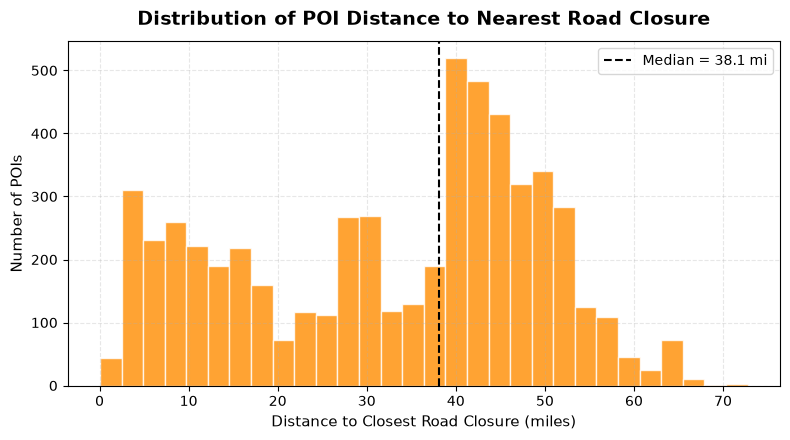

In [40]:
# Ensure gdf_poi is defined
import os
if 'gdf_poi' not in globals() or gdf_poi is None:
    import geopandas as gpd
    gdf_poi = gpd.GeoDataFrame(
        final_summary_df,
        geometry=gpd.points_from_xy(final_summary_df['longitude'], final_summary_df['latitude']),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

if 'road_closure_dist_closest_miles' not in gdf_poi.columns:
    if 'road_closure_dist_closest' in gdf_poi.columns:
        gdf_poi['road_closure_dist_closest_miles'] = gdf_poi['road_closure_dist_closest']*0.621371
    else:
        gdf_poi['road_closure_dist_closest_miles'] = 0.0

# Drop NaNs if any
distances = gdf_poi['road_closure_dist_closest_miles'].dropna()

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(distances, bins=30, color='darkorange', edgecolor='white', alpha=0.8)

# Labels and styling
ax.set_title("Distribution of POI Distance to Nearest Road Closure", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Distance to Closest Road Closure (miles)", fontsize=11)
ax.set_ylabel("Number of POIs", fontsize=11)
ax.axvline(distances.median(), color='black', linestyle='--', linewidth=1.5, label=f"Median = {distances.median():.1f} mi")
ax.tick_params(axis='both', labelsize=10)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "statistics", "distance_to_road_closure_histogram.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "statistics", "distance_to_road_closure_histogram.png"), dpi=150, bbox_inches="tight")
plt.show()


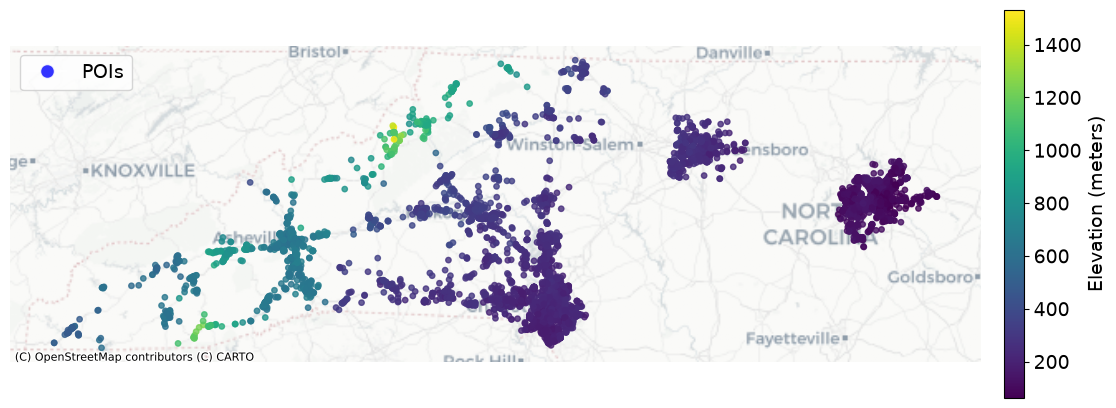

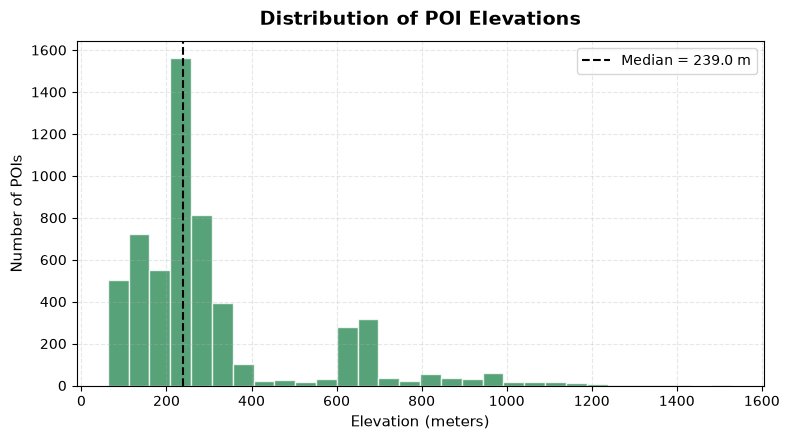

In [41]:
# Ensure gdf_poi is defined
import os
if 'gdf_poi' not in globals() or gdf_poi is None:
    import geopandas as gpd
    gdf_poi = gpd.GeoDataFrame(
        final_summary_df,
        geometry=gpd.points_from_xy(final_summary_df['longitude'], final_summary_df['latitude']),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

# Ensure elevation_m is numeric float64 to prevent geopandas plotting errors
if 'elevation_m' in gdf_poi.columns:
    gdf_poi['elevation_m'] = pd.to_numeric(gdf_poi['elevation_m'], errors='coerce')

# --- Elevation Map ---
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot POIs with elevation coloring
poi_plot = gdf_poi.plot(
    ax=ax,
    column="elevation_m",
    cmap="viridis",
    markersize=15,
    legend=True,
    legend_kwds={
        "label": "Elevation (meters)",
        "shrink": 0.4,
        "orientation": "vertical",
        "pad": 0.02
    },
    alpha=0.8,
    zorder=1
)

# Adjust colorbar
cbar = poi_plot.get_figure().get_axes()[1]
cbar.tick_params(labelsize=14)
cbar.set_ylabel("Elevation (meters)", fontsize=14)

# Add basemap
if cx is not None:
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

# Add custom legend
custom_legend = [
    Line2D([0], [0], marker='o', color='w', label='POIs',
           markerfacecolor='blue', markersize=10, alpha=0.8),
]
ax.legend(handles=custom_legend, loc="upper left", fontsize=14)

# Final formatting
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "maps", "poi_elevation_map.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "maps", "poi_elevation_map.png"), dpi=300, bbox_inches="tight")
plt.show()

# --- Elevation Histogram ---
elevations = gdf_poi['elevation_m'].dropna()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(elevations, bins=30, color='seagreen', edgecolor='white', alpha=0.8)

ax.set_title("Distribution of POI Elevations", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Elevation (meters)", fontsize=11)
ax.set_ylabel("Number of POIs", fontsize=11)
ax.axvline(elevations.median(), color='black', linestyle='--', linewidth=1.5, label=f"Median = {elevations.median():.1f} m")
ax.tick_params(axis='both', labelsize=10)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "statistics", "elevation_histogram.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "statistics", "elevation_histogram.png"), dpi=150, bbox_inches="tight")
plt.savefig(os.path.join(figures_dir, "statistics", "elevation_histogram.png"), dpi=300, bbox_inches="tight")
plt.show()


# Machine learning model

### Load data

In [13]:
# Read file if not already run previous steps
import pandas as pd
import os
try:
    final_summary_df = pd.read_csv(os.path.join(outputs_dir, "predictions", "test_timesfm_ancilary.csv"))
except (NameError, FileNotFoundError):
    import glob
    results_folders = sorted(glob.glob("results_*"))
    if results_folders:
        latest_folder = results_folders[-1]
        path1 = os.path.join(latest_folder, "predictions", "test_timesfm_ancilary.csv")
        path2 = os.path.join(latest_folder, "outputs", "predictions", "test_timesfm_ancilary.csv")
        if os.path.exists(path1):
            final_summary_df = pd.read_csv(path1)
        elif os.path.exists(path2):
            final_summary_df = pd.read_csv(path2)
        else:
            raise FileNotFoundError(f"Could not find test_timesfm_ancilary.csv in {latest_folder}")
    else:
        # Fallback to local files if they exist in current directory
        if os.path.exists("summary_metrics_western_nc_v3_ancilary.csv"):
            final_summary_df = pd.read_csv("summary_metrics_western_nc_v3_ancilary.csv")
        else:
            raise FileNotFoundError("Could not find outputs_dir or any results_* folder containing test_timesfm_ancilary.csv.")

In [14]:
final_summary_df["elevation_m"].isna().sum()

np.int64(0)

In [15]:
final_summary_df.head()

,Unnamed: 0,placekey,latitude,longitude,naics_code,city,region,GEOID,County,mean_per_day,...,precip_20240925,precip_20240926,precip_20240927,precip_20240928,precip_20240929,precip_sum_week,precip_mean_week,precip_max_week,road_closure_dist_closest,road_closure_dist_second_closest
0,0,zzy-226@63g-2dz-kcq,36.099589,-79.778028,3231,Greensboro,NC,3.708101e+11,Guilford,39.785714,...,1.291339,0.220472,0.468504,0.921260,0.0,4.440945,0.634421,1.539370,77.896505,117.777972
1,1,229-222@8gf-r5g-2hq,35.594863,-82.550944,5412,Asheville,NC,3.702100e+11,Buncombe,74.220497,...,0.311024,7.279527,4.370079,1.157480,0.0,13.279527,1.897075,7.279527,16.247025,22.852251
2,2,22b-222@8gf-dk3-d35,35.224164,-81.036060,5615,Belmont,NC,3.707103e+11,Gaston,156.156832,...,0.905512,0.555118,5.476377,0.685039,0.0,7.622047,1.088864,5.476377,54.347037,64.226972
3,3,229-225@8gf-fnx-kxq,35.445106,-80.880242,311811,Huntersville,NC,3.711901e+11,Mecklenburg,112.459627,...,1.826772,0.228346,4.866142,0.417323,0.0,7.354331,1.050619,4.866142,47.016981,71.938574
4,4,zzw-223@8gg-b7s-b6k,35.631602,-81.379969,445120,Hickory,NC,3.703501e+11,Catawba,55.563665,...,1.362205,1.027559,4.307086,0.956693,0.0,7.704724,1.100675,4.307086,4.260887,31.733071


In [16]:
final_summary_df.columns

Index(['Unnamed: 0', 'placekey', 'latitude', 'longitude', 'naics_code', 'city',
       'region', 'GEOID', 'County', 'mean_per_day', 'mean_before_hurricane',
       'mean_after_hurricane', 'timesfm_mae', 'timesfm_rmse', 'timesfm_r2',
       'timesfm_auc_pos', 'timesfm_auc_neg', 'timesfm_auc_total', 'test_dates',
       'test_true_list', 'test_pred_list', 'timesfm_ok', 'elevation_m',
       'precip_20240923', 'precip_20240924', 'precip_20240925',
       'precip_20240926', 'precip_20240927', 'precip_20240928',
       'precip_20240929', 'precip_sum_week', 'precip_mean_week',
       'precip_max_week', 'road_closure_dist_closest',
       'road_closure_dist_second_closest'],
      dtype='str')

In [17]:
import pandas as pd

# --- Simplified ML Data Loading ---
# Since final_summary_df already contains the latest TimesFM predictions and ancillary features,
# we use it directly as merged_df.
merged_df = final_summary_df.copy()

# Ensure naics_2d column is defined
if "naics_code" in merged_df.columns:
    merged_df["naics_2d"] = merged_df["naics_code"].astype(str).str[:2].astype(int)

print(f"Data loaded successfully. Shape: {merged_df.shape}")
print(merged_df.columns.tolist())


Data loaded successfully. Shape: (5671, 36)
['Unnamed: 0', 'placekey', 'latitude', 'longitude', 'naics_code', 'city', 'region', 'GEOID', 'County', 'mean_per_day', 'mean_before_hurricane', 'mean_after_hurricane', 'timesfm_mae', 'timesfm_rmse', 'timesfm_r2', 'timesfm_auc_pos', 'timesfm_auc_neg', 'timesfm_auc_total', 'test_dates', 'test_true_list', 'test_pred_list', 'timesfm_ok', 'elevation_m', 'precip_20240923', 'precip_20240924', 'precip_20240925', 'precip_20240926', 'precip_20240927', 'precip_20240928', 'precip_20240929', 'precip_sum_week', 'precip_mean_week', 'precip_max_week', 'road_closure_dist_closest', 'road_closure_dist_second_closest', 'naics_2d']


In [18]:
merged_df.columns

Index(['Unnamed: 0', 'placekey', 'latitude', 'longitude', 'naics_code', 'city',
       'region', 'GEOID', 'County', 'mean_per_day', 'mean_before_hurricane',
       'mean_after_hurricane', 'timesfm_mae', 'timesfm_rmse', 'timesfm_r2',
       'timesfm_auc_pos', 'timesfm_auc_neg', 'timesfm_auc_total', 'test_dates',
       'test_true_list', 'test_pred_list', 'timesfm_ok', 'elevation_m',
       'precip_20240923', 'precip_20240924', 'precip_20240925',
       'precip_20240926', 'precip_20240927', 'precip_20240928',
       'precip_20240929', 'precip_sum_week', 'precip_mean_week',
       'precip_max_week', 'road_closure_dist_closest',
       'road_closure_dist_second_closest', 'naics_2d'],
      dtype='str')

### Plot vs Ancillary

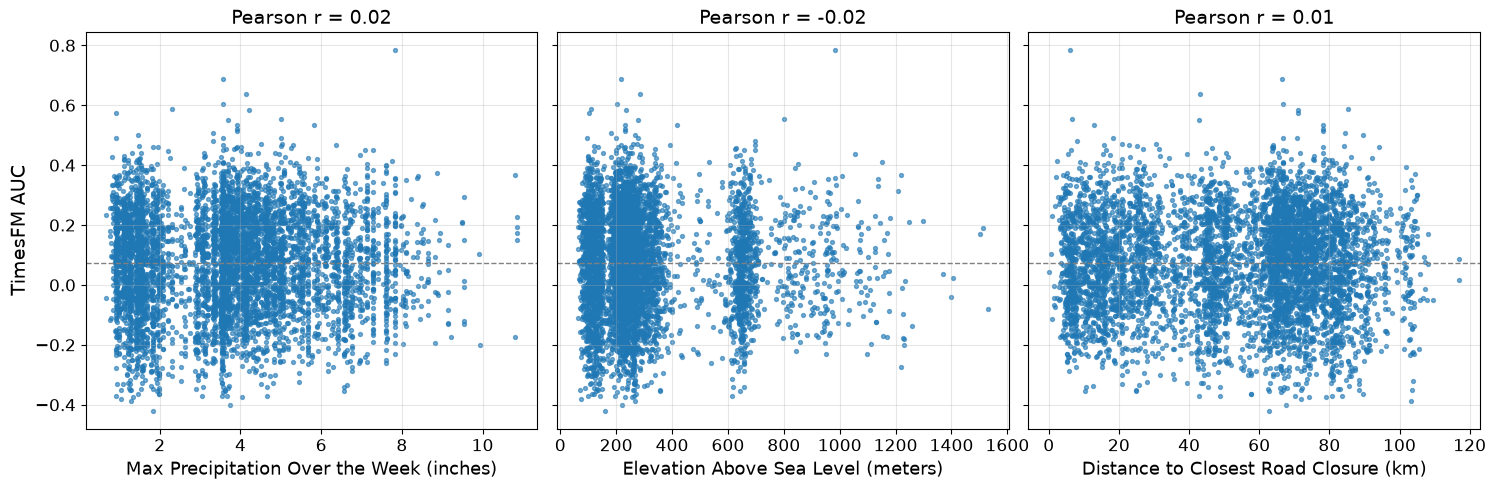

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import os

# ==========================================
# Target variable
# ==========================================
y_col = "timesfm_auc_total"

vars_to_plot = [
    ("precip_max_week", "Max Precipitation Over the Week (inches)"),
    ("elevation_m", "Elevation Above Sea Level (meters)"),
    ("road_closure_dist_closest", "Distance to Closest Road Closure (km)")
]

# ==========================================
# Create the 1×3 figure
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (x_col, xlabel) in zip(axes, vars_to_plot):

    # Jointly drop NaNs
    df_tmp = merged_df[[x_col, y_col]].dropna()

    x = df_tmp[x_col].values
    y = df_tmp[y_col].values

    # Safe Pearson correlation
    if len(x) > 1 and np.std(x) > 0 and np.std(y) > 0:
        r, _ = pearsonr(x, y)
        r_text = f"{r:.02f}"
    else:
        r = np.nan
        r_text = "undefined"

    # Scatter plot
    ax.scatter(x, y, s=8, alpha=0.6)

    # Horizontal mean line
    ax.axhline(y.mean(), color="gray", linestyle="--", linewidth=1)

    # Labels and title
    ax.set_title(f"Pearson r = {r_text}", fontsize=14)
    ax.set_xlabel(xlabel, fontsize=13)
    ax.grid(True, alpha=0.3)

    # Tick sizes
    ax.tick_params(axis="both", labelsize=12)

# Shared Y label
axes[0].set_ylabel("TimesFM AUC", fontsize=14)

plt.tight_layout()

# ==========================================
# Save and show
# ==========================================
try:
    plt.savefig(
        os.path.join(figures_dir, "statistics", "timesfm_auc_correlations_1x3.pdf"),
        format="pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(figures_dir, "statistics", "timesfm_auc_correlations_1x3.png"),
        dpi=150,
        bbox_inches="tight"
    )
except NameError:
    plt.savefig(
        "timesfm_auc_correlations_1x3.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

### Total SHAP

#### Full data

X_transformed shape: (5671, 63)
Number of feature names: 63
Training RMSE: 0.136


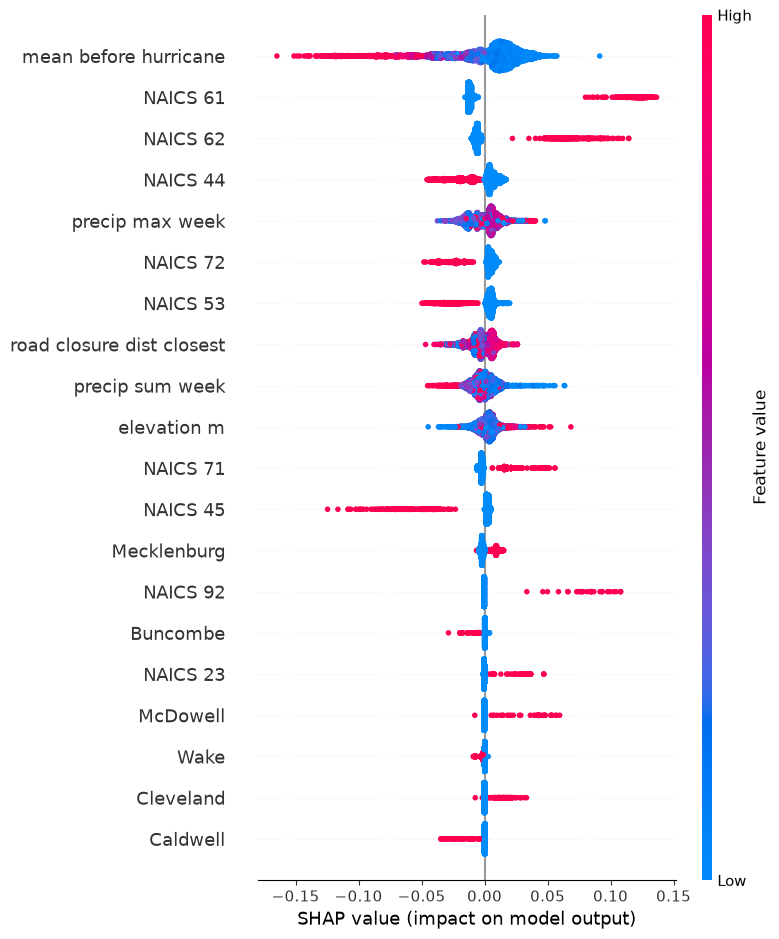

In [20]:
import os
set_reproducible_seeds(42)
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error


# Step 2: Define features and target
features = [
    'County', 'mean_per_day', 'mean_before_hurricane', 'mean_after_hurricane',
    'precip_sum_week', 'precip_mean_week', 'precip_max_week',
    'elevation_m', 'naics_2d', 'road_closure_dist_closest'
]
target = 'timesfm_auc_total'

X = merged_df[features].copy()
y = merged_df[target]

# -------------------------------------------------------
# 1. Remove leakage / undesired columns
# -------------------------------------------------------
X_model = X.drop(
    columns=[
        "mean_after_hurricane",
        "mean_per_day"
    ]
).copy()

# -------------------------------------------------------
# 2. Define categorical columns
# -------------------------------------------------------
categorical_features = ["County", "naics_2d"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# -------------------------------------------------------
# 3. Transform X
# -------------------------------------------------------
X_transformed = preprocessor.fit_transform(X_model)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# -------------------------------------------------------
# 4. Exact transformed feature names
# -------------------------------------------------------
feature_names = preprocessor.get_feature_names_out()

cleaned_names = []

for f in feature_names:
    name = str(f)
    name = name.replace("cat__County_", "")
    name = name.replace("cat__naics_2d_", "NAICS ")
    name = name.replace("remainder__", "")
    name = name.replace("_", " ")
    cleaned_names.append(name)

# -------------------------------------------------------
# 5. Create DataFrame
# -------------------------------------------------------
X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=cleaned_names,
    index=X_model.index
)

print("X_transformed shape:", X_transformed_df.shape)
print("Number of feature names:", len(cleaned_names))

# -------------------------------------------------------
# 6. Fit model
# -------------------------------------------------------
xgb_direct = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

xgb_direct.fit(X_transformed_df, y)

# -------------------------------------------------------
# 7. RMSE
# -------------------------------------------------------
y_pred = xgb_direct.predict(X_transformed_df)

rmse = np.sqrt(mean_squared_error(y, y_pred))
print("Training RMSE:", round(rmse, 4))

# -------------------------------------------------------
# 8. SHAP
# -------------------------------------------------------
explainer = shap.Explainer(xgb_direct)
shap_values = explainer(X_transformed_df)

# -------------------------------------------------------
# 9. SHAP summary plot
# -------------------------------------------------------
plt.close("all")
plt.figure(figsize=(12, 6))

shap.summary_plot(
    shap_values,
    X_transformed_df,
    show=False
)

try:
    plt.savefig(
        os.path.join(figures_dir, "SHAP", "SHAP_Summary_Plot.pdf"),
        format="pdf",
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(figures_dir, "SHAP", "SHAP_Summary_Plot.png"),
        dpi=150,
        bbox_inches="tight"
    )
except NameError:
    plt.savefig(
        "SHAP_Summary_Plot.pdf",
        format="pdf",
        bbox_inches="tight"
    )

plt.show()
plt.close()

#### Splitted data

In [21]:
merged_df.head()

,Unnamed: 0,placekey,latitude,longitude,naics_code,city,region,GEOID,County,mean_per_day,...,precip_20240926,precip_20240927,precip_20240928,precip_20240929,precip_sum_week,precip_mean_week,precip_max_week,road_closure_dist_closest,road_closure_dist_second_closest,naics_2d
0,0,zzy-226@63g-2dz-kcq,36.099589,-79.778028,3231,Greensboro,NC,3.708101e+11,Guilford,39.785714,...,0.220472,0.468504,0.921260,0.0,4.440945,0.634421,1.539370,77.896505,117.777972,32
1,1,229-222@8gf-r5g-2hq,35.594863,-82.550944,5412,Asheville,NC,3.702100e+11,Buncombe,74.220497,...,7.279527,4.370079,1.157480,0.0,13.279527,1.897075,7.279527,16.247025,22.852251,54
2,2,22b-222@8gf-dk3-d35,35.224164,-81.036060,5615,Belmont,NC,3.707103e+11,Gaston,156.156832,...,0.555118,5.476377,0.685039,0.0,7.622047,1.088864,5.476377,54.347037,64.226972,56
3,3,229-225@8gf-fnx-kxq,35.445106,-80.880242,311811,Huntersville,NC,3.711901e+11,Mecklenburg,112.459627,...,0.228346,4.866142,0.417323,0.0,7.354331,1.050619,4.866142,47.016981,71.938574,31
4,4,zzw-223@8gg-b7s-b6k,35.631602,-81.379969,445120,Hickory,NC,3.703501e+11,Catawba,55.563665,...,1.027559,4.307086,0.956693,0.0,7.704724,1.100675,4.307086,4.260887,31.733071,44


Some County-NAICS combinations are too rare.
Using NAICS-only stratification instead.
Some NAICS categories are too rare.
Using random split without stratification.
Train size: (4536, 8)
Test size: (1135, 8)

NAICS distribution in train:
naics_2d
11    0.000220
22    0.000661
23    0.011243
31    0.002205
32    0.001764
33    0.003748
42    0.001984
44    0.272487
45    0.035273
48    0.005732
49    0.002866
51    0.008157
52    0.012346
53    0.133598
54    0.014330
55    0.001764
56    0.010582
61    0.084656
62    0.084877
71    0.111111
72    0.142857
81    0.052249
92    0.005291
Name: proportion, dtype: float64

NAICS distribution in test:
naics_2d
22    0.001762
23    0.012335
31    0.000881
32    0.000881
33    0.004405
42    0.001762
44    0.295154
45    0.037004
48    0.007048
49    0.001762
51    0.007930
52    0.013216
53    0.118062
54    0.008811
55    0.003524
56    0.017621
61    0.103084
62    0.068722
71    0.093392
72    0.141850
81    0.057269
92    0.003524
Name: p

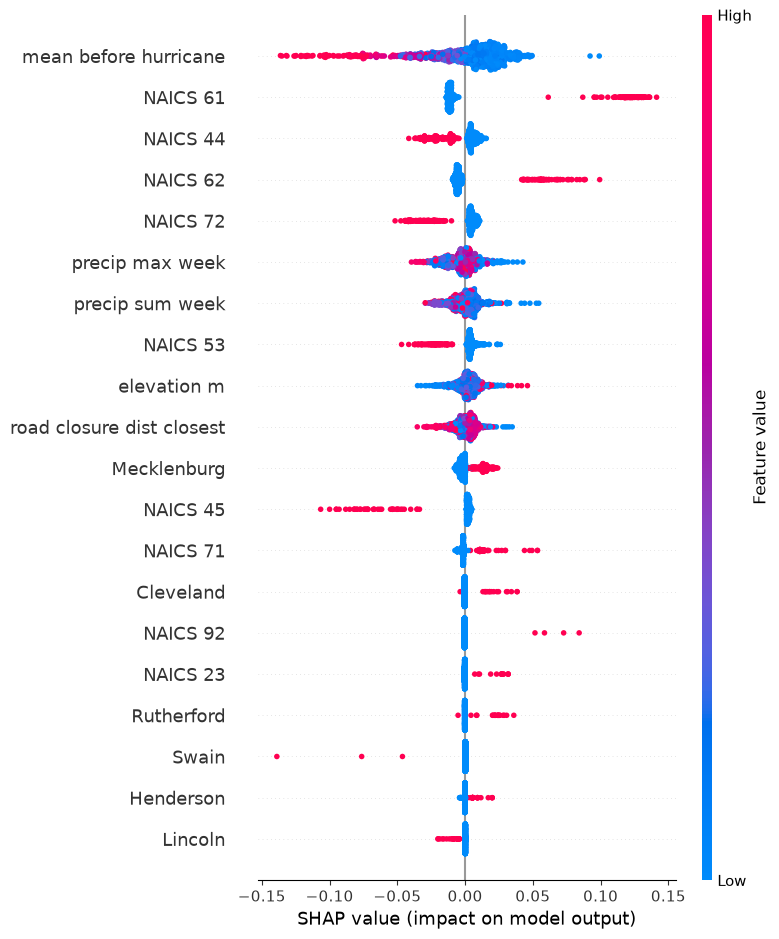

(1135, 101)


,Unnamed: 0,placekey,latitude,longitude,naics_code,city,region,GEOID,County,mean_per_day,...,SHAP_NAICS 71,SHAP_NAICS 72,SHAP_NAICS 81,SHAP_NAICS 92,SHAP_mean before hurricane,SHAP_precip sum week,SHAP_precip mean week,SHAP_precip max week,SHAP_elevation m,SHAP_road closure dist closest
3671,3671,222-222@8gg-95j-4vz,36.479346,-80.603424,531120,Mount Airy,NC,3.717193e+11,Surry,213.650621,...,-0.004662,0.003060,0.000349,-0.000465,-0.069919,0.007885,0.0,-0.019965,0.002501,0.000880
5183,5183,223-222@63g-2ch-9j9,36.094073,-79.815110,447110,Greensboro,NC,3.708101e+11,Guilford,29.742236,...,-0.001417,0.008274,0.000007,-0.000426,0.035993,0.017207,0.0,0.010597,0.005069,-0.004519
1859,1859,zzz-222@8gg-tjz-59f,35.382707,-82.549574,712190,Mills River,NC,3.708993e+11,Henderson,34.049689,...,0.014663,0.006469,-0.000113,-0.000403,0.024844,-0.002270,0.0,-0.002927,-0.001235,-0.008787
2589,2589,zzw-222@63f-kw6-kmk,35.904377,-78.784075,512131,Raleigh,NC,3.718305e+11,Wake,28.579193,...,-0.001441,0.009477,0.000012,-0.000374,0.025848,-0.006692,0.0,-0.021487,-0.020798,-0.014151
1662,1662,zzw-223@647-5ht-8y9,35.775159,-78.764950,722515,Cary,NC,3.718305e+11,Wake,71.784161,...,-0.001827,-0.021148,0.000005,-0.000428,-0.003374,-0.010171,0.0,0.007100,-0.002620,0.003592


In [22]:
import os
set_reproducible_seeds(42)
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# -------------------------------------------------------
# 1. Define features and target
# -------------------------------------------------------
features = [
    'County', 'mean_per_day', 'mean_before_hurricane', 'mean_after_hurricane',
    'precip_sum_week', 'precip_mean_week', 'precip_max_week',
    'elevation_m', 'naics_2d', 'road_closure_dist_closest'
]

target = 'timesfm_auc_total'

X = merged_df[features].copy()
y = merged_df[target].copy()

# -------------------------------------------------------
# 2. Remove leakage / undesired columns
# -------------------------------------------------------
X_model = X.drop(
    columns=[
        "mean_after_hurricane",
        "mean_per_day"
    ]
).copy()

# -------------------------------------------------------
# 3. Create stratification column for fair categorical split
# -------------------------------------------------------
# Try to balance both County and NAICS together
strata = (
    X_model["County"].astype(str) + "_" +
    X_model["naics_2d"].astype(str)
)

# If some groups are too rare, fall back to NAICS-only stratification
strata_counts = strata.value_counts()

if (strata_counts < 2).any():
    print("Some County-NAICS combinations are too rare.")
    print("Using NAICS-only stratification instead.")
    strata = X_model["naics_2d"].astype(str)

# If NAICS also has rare categories, fall back to no stratification
if (strata.value_counts() < 2).any():
    print("Some NAICS categories are too rare.")
    print("Using random split without stratification.")
    strata = None

# -------------------------------------------------------
# 4. Train-test split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=strata
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Optional check of category distribution
print("\nNAICS distribution in train:")
print(X_train["naics_2d"].value_counts(normalize=True).sort_index())

print("\nNAICS distribution in test:")
print(X_test["naics_2d"].value_counts(normalize=True).sort_index())

print("\nCounty distribution in train:")
print(X_train["County"].value_counts(normalize=True).head(10))

print("\nCounty distribution in test:")
print(X_test["County"].value_counts(normalize=True).head(10))

# -------------------------------------------------------
# 5. Preprocessor
# -------------------------------------------------------
categorical_features = ["County", "naics_2d"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# IMPORTANT:
# fit on train only, transform train and test
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# -------------------------------------------------------
# 6. Exact transformed feature names
# -------------------------------------------------------
feature_names = preprocessor.get_feature_names_out()

cleaned_names = []

for f in feature_names:
    name = str(f)
    name = name.replace("cat__County_", "")
    name = name.replace("cat__naics_2d_", "NAICS ")
    name = name.replace("remainder__", "")
    name = name.replace("_", " ")
    cleaned_names.append(name)

# -------------------------------------------------------
# 7. Create transformed DataFrames
# -------------------------------------------------------
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=cleaned_names,
    index=X_train.index
)

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=cleaned_names,
    index=X_test.index
)

print("\nTrain transformed shape:", X_train_transformed_df.shape)
print("Test transformed shape:", X_test_transformed_df.shape)
print("Number of feature names:", len(cleaned_names))

# -------------------------------------------------------
# 8. Fit model on training set only
# -------------------------------------------------------
xgb_direct = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

xgb_direct.fit(X_train_transformed_df, y_train)

# -------------------------------------------------------
# 9. Test-set prediction and metrics
# -------------------------------------------------------
y_test_pred = xgb_direct.predict(X_test_transformed_df)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest RMSE:", round(test_rmse, 4))
print("Test R²:", round(test_r2, 4))

# -------------------------------------------------------
# 10. SHAP on TEST SET
# -------------------------------------------------------
explainer = shap.Explainer(xgb_direct)
shap_values_test = explainer(X_test_transformed_df)

# -------------------------------------------------------
# 11. SHAP summary plot for TEST SET
# -------------------------------------------------------
plt.close("all")
plt.figure(figsize=(12, 6))

shap.summary_plot(
    shap_values_test,
    X_test_transformed_df,
    show=False
)

try:
    plt.savefig(
        os.path.join(figures_dir, "SHAP", "SHAP_Summary_Plot_TEST_SET.pdf"),
        format="pdf",
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(figures_dir, "SHAP", "SHAP_Summary_Plot_TEST_SET.png"),
        dpi=150,
        bbox_inches="tight"
    )
except NameError:
    plt.savefig(
        "SHAP_Summary_Plot_TEST_SET.pdf",
        format="pdf",
        bbox_inches="tight"
    )

plt.show()
plt.close()

# -------------------------------------------------------
# 12. Merge original test rows with SHAP values
# -------------------------------------------------------

# Original rows from merged_df that correspond exactly to X_test
test_merged_df = merged_df.loc[X_test.index].copy()

# SHAP values as DataFrame
shap_test_df = pd.DataFrame(
    shap_values_test.values,
    columns=[f"SHAP_{col}" for col in X_test_transformed_df.columns],
    index=X_test.index
)

# Optional: add prediction and true target
test_merged_df["y_true"] = y_test
test_merged_df["y_pred"] = y_test_pred

# Final combined DataFrame
test_merged_with_shap = pd.concat(
    [test_merged_df, shap_test_df],
    axis=1
)

print(test_merged_with_shap.shape)
test_merged_with_shap.head()

In [23]:
X.head()

,County,mean_per_day,mean_before_hurricane,mean_after_hurricane,precip_sum_week,precip_mean_week,precip_max_week,elevation_m,naics_2d,road_closure_dist_closest
0,Guilford,39.785714,42.017613,31.210526,4.440945,0.634421,1.539370,234.0,32,77.896505
1,Buncombe,74.220497,84.144814,36.090226,13.279527,1.897075,7.279527,675.0,54,16.247025
2,Gaston,156.156832,159.688845,142.586466,7.622047,1.088864,5.476377,226.0,56,54.347037
3,Mecklenburg,112.459627,118.095890,90.804511,7.354331,1.050619,4.866142,224.0,31,47.016981
4,Catawba,55.563665,57.424658,48.413534,7.704724,1.100675,4.307086,303.0,44,4.260887


In [24]:
X[X.index == 3671]

,County,mean_per_day,mean_before_hurricane,mean_after_hurricane,precip_sum_week,precip_mean_week,precip_max_week,elevation_m,naics_2d,road_closure_dist_closest
3671,Surry,213.650621,216.526419,202.601504,5.11811,0.731159,2.070866,304.0,53,36.743523


In [25]:
merged_df[merged_df.index == 3671]

,Unnamed: 0,placekey,latitude,longitude,naics_code,city,region,GEOID,County,mean_per_day,...,precip_20240926,precip_20240927,precip_20240928,precip_20240929,precip_sum_week,precip_mean_week,precip_max_week,road_closure_dist_closest,road_closure_dist_second_closest,naics_2d
3671,3671,222-222@8gg-95j-4vz,36.479346,-80.603424,531120,Mount Airy,NC,3.717193e+11,Surry,213.650621,...,0.437008,1.732283,2.070866,0.0,5.11811,0.731159,2.070866,36.743523,54.913373,53


In [26]:
X_test.head()

,County,mean_before_hurricane,precip_sum_week,precip_mean_week,precip_max_week,elevation_m,naics_2d,road_closure_dist_closest
3671,Surry,216.526419,5.118110,0.731159,2.070866,304.0,53,36.743523
5183,Guilford,30.751468,4.440945,0.634421,1.539370,243.0,44,81.179863
1859,Henderson,36.448141,16.586614,2.369516,7.307086,632.0,71,7.734816
2589,Wake,30.324853,4.283465,0.611924,1.988189,123.0,51,57.355974
1662,Wake,74.853229,3.531496,0.504499,1.322835,143.0,72,71.581930


In [27]:
X["elevation_m"].isna().sum()

np.int64(0)

In [28]:
X_test_transformed_df.head(50)

,Alexander,Alleghany,Ashe,Avery,Buncombe,Burke,Caldwell,Catawba,Cherokee,Clay,...,NAICS 71,NAICS 72,NAICS 81,NAICS 92,mean before hurricane,precip sum week,precip mean week,precip max week,elevation m,road closure dist closest
3671,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,216.526419,5.118110,0.731159,2.070866,304.0,36.743523
5183,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,30.751468,4.440945,0.634421,1.539370,243.0,81.179863
1859,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,36.448141,16.586614,2.369516,7.307086,632.0,7.734816
2589,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,30.324853,4.283465,0.611924,1.988189,123.0,57.355974
1662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,74.853229,3.531496,0.504499,1.322835,143.0,71.581930
2418,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,67.035225,4.051181,0.578740,3.712598,173.0,74.868859
3576,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,61.841487,3.653543,0.521935,3.307087,190.0,82.990534
1849,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,29.410959,8.818897,1.259842,4.814960,338.0,30.947648
5482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,98.250489,3.637795,0.519685,1.468504,286.0,90.747216
4440,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,84.992172,8.051181,1.150169,4.157480,328.0,13.627153


In [29]:
test_merged_with_shap.head(50)

,Unnamed: 0,placekey,latitude,longitude,naics_code,city,region,GEOID,County,mean_per_day,...,SHAP_NAICS 71,SHAP_NAICS 72,SHAP_NAICS 81,SHAP_NAICS 92,SHAP_mean before hurricane,SHAP_precip sum week,SHAP_precip mean week,SHAP_precip max week,SHAP_elevation m,SHAP_road closure dist closest
3671,3671,222-222@8gg-95j-4vz,36.479346,-80.603424,531120,Mount Airy,NC,3.717193e+11,Surry,213.650621,...,-0.004662,0.003060,3.491853e-04,-0.000465,-0.069919,0.007885,0.0,-0.019965,0.002501,0.000880
5183,5183,223-222@63g-2ch-9j9,36.094073,-79.815110,447110,Greensboro,NC,3.708101e+11,Guilford,29.742236,...,-0.001417,0.008274,7.414364e-06,-0.000426,0.035993,0.017207,0.0,0.010597,0.005069,-0.004519
1859,1859,zzz-222@8gg-tjz-59f,35.382707,-82.549574,712190,Mills River,NC,3.708993e+11,Henderson,34.049689,...,0.014663,0.006469,-1.134444e-04,-0.000403,0.024844,-0.002270,0.0,-0.002927,-0.001235,-0.008787
2589,2589,zzw-222@63f-kw6-kmk,35.904377,-78.784075,512131,Raleigh,NC,3.718305e+11,Wake,28.579193,...,-0.001441,0.009477,1.196082e-05,-0.000374,0.025848,-0.006692,0.0,-0.021487,-0.020798,-0.014151
1662,1662,zzw-223@647-5ht-8y9,35.775159,-78.764950,722515,Cary,NC,3.718305e+11,Wake,71.784161,...,-0.001827,-0.021148,4.953503e-06,-0.000428,-0.003374,-0.010171,0.0,0.007100,-0.002620,0.003592
2418,2418,zzw-222@8gf-dqf-qmk,35.084570,-80.882983,531120,Pineville,NC,3.711901e+11,Mecklenburg,64.908385,...,-0.001814,0.005025,-2.979341e-04,-0.000311,0.006196,0.002696,0.0,-0.003532,-0.011911,-0.010842
3576,3576,zzz-222@8gf-dpx-k75,35.019798,-80.841018,712190,Charlotte,NC,3.711901e+11,Mecklenburg,59.503106,...,0.012787,0.005654,-2.429493e-04,-0.000300,0.006162,0.000843,0.0,-0.011898,0.001705,-0.010719
1849,1849,228-222@8gf-pxs-qfz,35.753826,-81.668387,713910,Morganton,NC,3.702302e+11,Burke,27.947205,...,0.010736,0.008019,3.325715e-05,-0.000362,0.006069,-0.003544,0.0,-0.005500,0.000423,-0.003668
5482,5482,226-223@63g-5m8-qvf,36.054681,-79.909878,451110,Greensboro,NC,3.708102e+11,Guilford,94.464286,...,-0.001562,0.003136,7.532620e-05,-0.000407,-0.008681,-0.014632,0.0,-0.014116,0.009362,-0.021597
4440,4440,222-222@8gg-9r4-xt9,35.769401,-81.328181,445110,Hickory,NC,3.703501e+11,Catawba,82.875776,...,-0.001918,0.003007,1.081489e-04,-0.000466,-0.040656,-0.002642,0.0,0.008568,0.003877,-0.005626


In [30]:
test_merged_with_shap.columns.values

<ArrowStringArray>
[                    'Unnamed: 0',                       'placekey',
                       'latitude',                      'longitude',
                     'naics_code',                           'city',
                         'region',                          'GEOID',
                         'County',                   'mean_per_day',
 ...
                  'SHAP_NAICS 71',                  'SHAP_NAICS 72',
                  'SHAP_NAICS 81',                  'SHAP_NAICS 92',
     'SHAP_mean before hurricane',           'SHAP_precip sum week',
          'SHAP_precip mean week',           'SHAP_precip max week',
               'SHAP_elevation m', 'SHAP_road closure dist closest']
Length: 101, dtype: str

In [31]:
test_merged_with_shap[test_merged_with_shap["SHAP_mean before hurricane"] < 0]

,Unnamed: 0,placekey,latitude,longitude,naics_code,city,region,GEOID,County,mean_per_day,...,SHAP_NAICS 71,SHAP_NAICS 72,SHAP_NAICS 81,SHAP_NAICS 92,SHAP_mean before hurricane,SHAP_precip sum week,SHAP_precip mean week,SHAP_precip max week,SHAP_elevation m,SHAP_road closure dist closest
3671,3671,222-222@8gg-95j-4vz,36.479346,-80.603424,531120,Mount Airy,NC,3.717193e+11,Surry,213.650621,...,-0.004662,0.003060,0.000349,-0.000465,-0.069919,0.007885,0.0,-0.019965,0.002501,0.000880
1662,1662,zzw-223@647-5ht-8y9,35.775159,-78.764950,722515,Cary,NC,3.718305e+11,Wake,71.784161,...,-0.001827,-0.021148,0.000005,-0.000428,-0.003374,-0.010171,0.0,0.007100,-0.002620,0.003592
5482,5482,226-223@63g-5m8-qvf,36.054681,-79.909878,451110,Greensboro,NC,3.708102e+11,Guilford,94.464286,...,-0.001562,0.003136,0.000075,-0.000407,-0.008681,-0.014632,0.0,-0.014116,0.009362,-0.021597
4440,4440,222-222@8gg-9r4-xt9,35.769401,-81.328181,445110,Hickory,NC,3.703501e+11,Catawba,82.875776,...,-0.001918,0.003007,0.000108,-0.000466,-0.040656,-0.002642,0.0,0.008568,0.003877,-0.005626
3603,3603,222-228@8gg-9sk-v75,35.719459,-81.347878,811111,Hickory,NC,3.703501e+11,Catawba,97.791925,...,-0.001808,0.003790,-0.002065,-0.000470,-0.002357,-0.018476,0.0,-0.006619,-0.001200,-0.007088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4731,4731,zzw-222@63f-ktm-5cq,35.805310,-78.780507,445110,Cary,NC,3.718305e+11,Wake,74.290373,...,-0.001919,0.003848,0.000036,-0.000465,-0.036326,0.004659,0.0,-0.001909,0.006871,0.002765
219,219,zzy-222@63f-m3h-y9z,35.941927,-78.560262,447110,Raleigh,NC,3.718305e+11,Wake,66.406832,...,-0.001253,0.004462,0.000036,-0.000465,-0.014749,-0.000570,0.0,0.001891,0.016467,0.002492
3872,3872,22y-222@8gf-ddy-789,35.107254,-80.987895,621210,Charlotte,NC,3.711901e+11,Mecklenburg,25.170807,...,-0.000804,0.009260,0.000002,-0.000306,-0.037009,-0.000662,0.0,-0.003086,0.008604,0.002589
1297,1297,zzy-223@63f-km2-26k,35.823047,-78.588952,722515,Raleigh,NC,3.718305e+11,Wake,186.097826,...,-0.002639,-0.022734,0.000030,-0.000415,-0.025146,-0.003556,0.0,0.016517,-0.006604,0.004395


### Anchor

In [32]:
# -------------------------------------------------------
# POIs with:
# 1. High mean_before_hurricane
# 2. VERY HIGH negative SHAP from mean_before_hurricane
# Then report their NAICS sector codes
# -------------------------------------------------------

import pandas as pd
import numpy as np

df = test_merged_with_shap.copy()

# -----------------------------------------
# Locate exact SHAP feature column
# -----------------------------------------
target_shap_col = "SHAP_mean before hurricane"

if target_shap_col not in df.columns:
    candidates = [
        c for c in df.columns
        if c.startswith("SHAP_") and "mean before" in c.lower()
    ]
    target_shap_col = candidates[0]

print("Using SHAP column:", target_shap_col)

# -----------------------------------------
# Thresholds
# -----------------------------------------

# High observed pre-hurricane visitation
high_mean_thresh = df["mean_before_hurricane"].quantile(0.95)

# Very negative SHAP contribution
neg_shap_thresh = df[target_shap_col].quantile(0.05)

print("High mean_before_hurricane threshold:", high_mean_thresh)
print("Negative SHAP threshold:", neg_shap_thresh)

# -----------------------------------------
# Filter POIs
# -----------------------------------------
mask = (
    (df[target_shap_col] <= neg_shap_thresh)&
    (df["mean_before_hurricane"] >= high_mean_thresh) 
)

selected = df.loc[mask].copy()

selected["mean_before_shap"] = selected[target_shap_col]

# -----------------------------------------
# Report NAICS sectors
# -----------------------------------------
sector_summary = (
    selected.groupby("naics_2d")
    .agg(
        count=("naics_2d", "size"),
        avg_mean_before=("mean_before_hurricane", "mean"),
        avg_shap=("mean_before_shap", "mean"),
        avg_y_true=("y_true", "mean"),
        avg_y_pred=("y_pred", "mean")
    )
    .sort_values(["count", "avg_shap"], ascending=[False, True])
    .reset_index()
)

print("\n=== NAICS sectors of high-traffic POIs with very negative SHAP ===")
print(sector_summary)

# -----------------------------------------
# Optional detailed POI rows
# -----------------------------------------
detail_cols = [
    "placekey",
    "County",
    "city",
    "naics_2d",
    "naics_code",
    "mean_before_hurricane",
    "mean_before_shap",
    "timesfm_auc_total",
    "y_true",
    "y_pred"
]

detail_cols = [c for c in detail_cols if c in selected.columns]

print("\n=== Example POIs ===")
print(selected[detail_cols].head(25))

Using SHAP column: SHAP_mean before hurricane
High mean_before_hurricane threshold: 270.77416829745584
Negative SHAP threshold: -0.07601016461849212

=== NAICS sectors of high-traffic POIs with very negative SHAP ===
   naics_2d  count  avg_mean_before  avg_shap  avg_y_true  avg_y_pred
0        53     30       617.623092 -0.109174   -0.115935   -0.084313
1        44      8       333.949364 -0.088952    0.023392   -0.043297
2        61      5       728.679061 -0.110074    0.135036    0.086038
3        45      1       319.369863 -0.094113   -0.334468   -0.060275
4        81      1       272.818004 -0.085327   -0.174502   -0.034027
5        56      1       313.072407 -0.080228   -0.145586   -0.023816
6        72      1       912.326810 -0.077427   -0.216047   -0.019098

=== Example POIs ===
                 placekey       County            city  naics_2d  naics_code  \
5631  222-222@8gg-3h8-d7q  Mecklenburg        Matthews        53      531120   
5361  228-222@8gg-thk-rx5    Henderson  H

In [33]:
selected[detail_cols]

,placekey,County,city,naics_2d,naics_code,mean_before_hurricane,mean_before_shap,timesfm_auc_total,y_true,y_pred
5631,222-222@8gg-3h8-d7q,Mecklenburg,Matthews,53,531120,619.309198,-0.125460,-0.183560,-0.183560,-0.157755
5361,228-222@8gg-thk-rx5,Henderson,Hendersonville,53,531120,391.422701,-0.117282,-0.274893,-0.274893,-0.099877
577,222-225@8gf-fpm-yvz,Lincoln,Denver,44,448190,333.804305,-0.081305,-0.199004,-0.199004,-0.034508
3895,zzw-225@647-5ht-7qz,Wake,Cary,53,531120,954.604697,-0.118992,0.082246,0.082246,-0.117642
199,222-222@647-364-p9z,Wake,Fuquay Varina,53,531120,497.559687,-0.102431,-0.222530,-0.222530,-0.094717
5255,zzw-225@63f-m38-y7q,Wake,Wake Forest,53,531120,286.939335,-0.080585,-0.210603,-0.210603,-0.033026
2197,223-222@647-5gy-p7q,Wake,Apex,53,531120,1138.837573,-0.121171,-0.238440,-0.238440,-0.128317
1199,zzw-222@647-37x-ch5,Wake,Raleigh,44,447110,310.260274,-0.089341,0.011927,0.011927,-0.063877
3931,222-222@63f-hrq-tn5,Wake,Wendell,44,447110,329.500978,-0.107042,-0.045235,-0.045235,-0.001222
3114,zzw-222@63f-kvz-5cq,Wake,Raleigh,53,531120,464.704501,-0.101038,0.107767,0.107767,-0.100492


In [34]:
selected["naics_code"].values

array([531120, 531120, 448190, 531120, 531120, 531120, 531120, 447110,
       447110, 531120, 611310, 611310, 722515, 531120, 812921, 531120,
       452311, 531120, 531120, 531120, 447110, 531120, 561622, 531120,
       531120, 611310, 531120, 611310, 611310, 531120, 531120, 531120,
       531120, 531120, 447110, 448130, 531120, 447110, 531120, 531120,
       531120, 441110, 531120, 531120, 531120, 531120, 531120])

In [ ]:
selected["naics_code"].value_counts()

In [35]:
# -------------------------------------------------------
# POIs with:
# 1. High mean_before_hurricane
# 2. VERY HIGH negative SHAP from mean_before_hurricane
# Then report their NAICS sector codes
# -------------------------------------------------------

import pandas as pd
import numpy as np

df = test_merged_with_shap.copy()

# -----------------------------------------
# Locate exact SHAP feature column
# -----------------------------------------
target_shap_col = "SHAP_mean before hurricane"

if target_shap_col not in df.columns:
    candidates = [
        c for c in df.columns
        if c.startswith("SHAP_") and "mean before" in c.lower()
    ]
    target_shap_col = candidates[0]

print("Using SHAP column:", target_shap_col)

# -----------------------------------------
# Thresholds
# -----------------------------------------

# High observed pre-hurricane visitation
high_mean_thresh = df["mean_before_hurricane"].quantile(0.90)

# Very negative SHAP contribution
neg_shap_thresh = df[target_shap_col].quantile(0.10)

print("High mean_before_hurricane threshold:", high_mean_thresh)
print("Negative SHAP threshold:", neg_shap_thresh)

# -----------------------------------------
# Filter POIs
# -----------------------------------------
mask = (
    (df[target_shap_col] <= neg_shap_thresh)&
    (df["mean_before_hurricane"] >= high_mean_thresh) 
)

selected = df.loc[mask].copy()

selected["mean_before_shap"] = selected[target_shap_col]

# -----------------------------------------
# Report NAICS sectors
# -----------------------------------------
sector_summary = (
    selected.groupby("naics_2d")
    .agg(
        count=("naics_2d", "size"),
        avg_mean_before=("mean_before_hurricane", "mean"),
        avg_shap=("mean_before_shap", "mean"),
        avg_y_true=("y_true", "mean"),
        avg_y_pred=("y_pred", "mean")
    )
    .sort_values(["count", "avg_shap"], ascending=[False, True])
    .reset_index()
)

print("\n=== NAICS sectors of high-traffic POIs with very negative SHAP ===")
print(sector_summary)

# -----------------------------------------
# Optional detailed POI rows
# -----------------------------------------
detail_cols = [
    "placekey",
    "County",
    "city",
    "naics_2d",
    "naics_code",
    "mean_before_hurricane",
    "mean_before_shap",
    "timesfm_auc_total",
    "y_true",
    "y_pred"
]

detail_cols = [c for c in detail_cols if c in selected.columns]

print("\n=== Example POIs ===")
print(selected[detail_cols].head(25))

Using SHAP column: SHAP_mean before hurricane
High mean_before_hurricane threshold: 196.23326810176127
Negative SHAP threshold: -0.04305766299366951

=== NAICS sectors of high-traffic POIs with very negative SHAP ===
   naics_2d  count  avg_mean_before  avg_shap  avg_y_true  avg_y_pred
0        53     50       467.561292 -0.094259   -0.088237   -0.065034
1        44     21       274.076507 -0.075018    0.034271   -0.034550
2        61      7       585.819961 -0.098583    0.159820    0.099755
3        62      5       417.760861 -0.052830    0.132707    0.136604
4        81      4       247.688845 -0.075151    0.008924   -0.018745
5        72      4       410.800391 -0.059808   -0.038607   -0.003367
6        45      3       289.958904 -0.086590   -0.333789   -0.123249
7        56      1       313.072407 -0.080228   -0.145586   -0.023816
8        52      1       250.786693 -0.075952   -0.113856    0.023278
9        92      1       219.628180 -0.054967   -0.187946    0.091208

=== Example 

In [36]:
selected[detail_cols]

,placekey,County,city,naics_2d,naics_code,mean_before_hurricane,mean_before_shap,timesfm_auc_total,y_true,y_pred
3671,222-222@8gg-95j-4vz,Surry,Mount Airy,53,531120,216.526419,-0.069919,0.005745,0.005745,-0.041264
5631,222-222@8gg-3h8-d7q,Mecklenburg,Matthews,53,531120,619.309198,-0.125460,-0.183560,-0.183560,-0.157755
5361,228-222@8gg-thk-rx5,Henderson,Hendersonville,53,531120,391.422701,-0.117282,-0.274893,-0.274893,-0.099877
5228,zzy-222@63g-5m5-4qf,Guilford,High Point,44,447110,228.890411,-0.072301,-0.009195,-0.009195,-0.055120
577,222-225@8gf-fpm-yvz,Lincoln,Denver,44,448190,333.804305,-0.081305,-0.199004,-0.199004,-0.034508
...,...,...,...,...,...,...,...,...,...,...
3082,zzy-222@63f-kjy-jy9,Wake,Knightdale,53,531120,623.395303,-0.131411,-0.038793,-0.038793,-0.107257
677,222-222@63g-2d8-8gk,Guilford,Greensboro,44,447110,214.283757,-0.069744,0.148001,0.148001,-0.061493
4447,zzy-224@647-3qf-b8v,Wake,Raleigh,44,445110,200.365949,-0.044087,0.086739,0.086739,0.052070
5245,22k-223@647-5hw-y9z,Wake,Raleigh,53,531120,350.722114,-0.092656,-0.065588,-0.065588,-0.087708


In [37]:
selected["naics_code"].values

array([531120, 531120, 531120, 447110, 448190, 531120, 531120, 531120,
       531120, 531120, 447110, 531120, 447110, 531120, 611310, 622110,
       531120, 611310, 722515, 531120, 531120, 452311, 812921, 446130,
       722511, 531120, 531120, 446110, 531120, 452311, 531120, 531120,
       531120, 522110, 531120, 447110, 531120, 561622, 531120, 531120,
       531120, 621399, 531120, 611310, 531120, 621399, 447110, 531120,
       611310, 611310, 452311, 531120, 531120, 531120, 441120, 531120,
       447110, 531120, 531120, 531120, 531120, 926120, 622110, 447110,
       448130, 611310, 811192, 531120, 531120, 531120, 812320, 721110,
       447110, 531120, 621210, 722511, 448210, 447110, 446110, 531120,
       531120, 531120, 531120, 531120, 531120, 812921, 441110, 531120,
       531120, 445110, 447110, 531120, 531120, 447110, 445110, 531120,
       611310])

In [49]:
selected["naics_code"].value_counts()

naics_code
531120    50
447110    11
611310     7
452311     3
622110     2
812921     2
722511     2
446110     2
621399     2
445110     2
448190     1
722515     1
446130     1
522110     1
561622     1
441120     1
926120     1
448130     1
811192     1
812320     1
721110     1
621210     1
448210     1
441110     1
Name: count, dtype: int64

### Local

✅ Saved: Local_SHAP_explanation_Highest_AUC_largest_hurricane_impact.pdf
Original merged_df row index: 183
AUC value: 0.635954
Predicted value: 0.07727224379777908


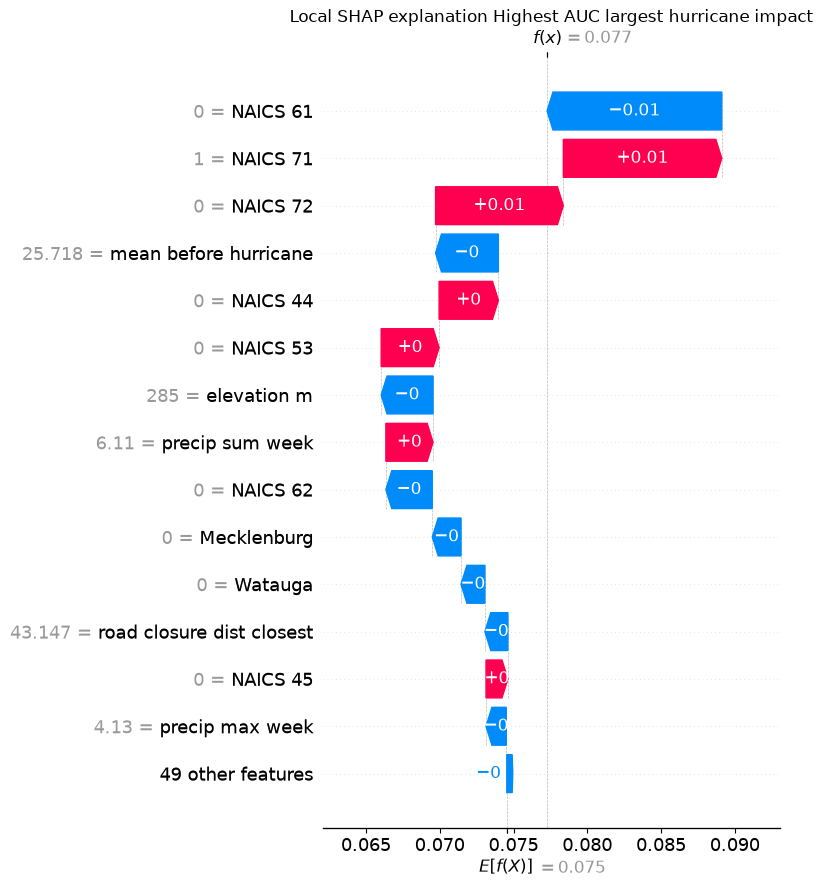

✅ Saved: Local_SHAP_explanation_Lowest_AUC_reverse_negative_impact.pdf
Original merged_df row index: 2572
AUC value: -0.37161857
Predicted value: 0.12658193707466125


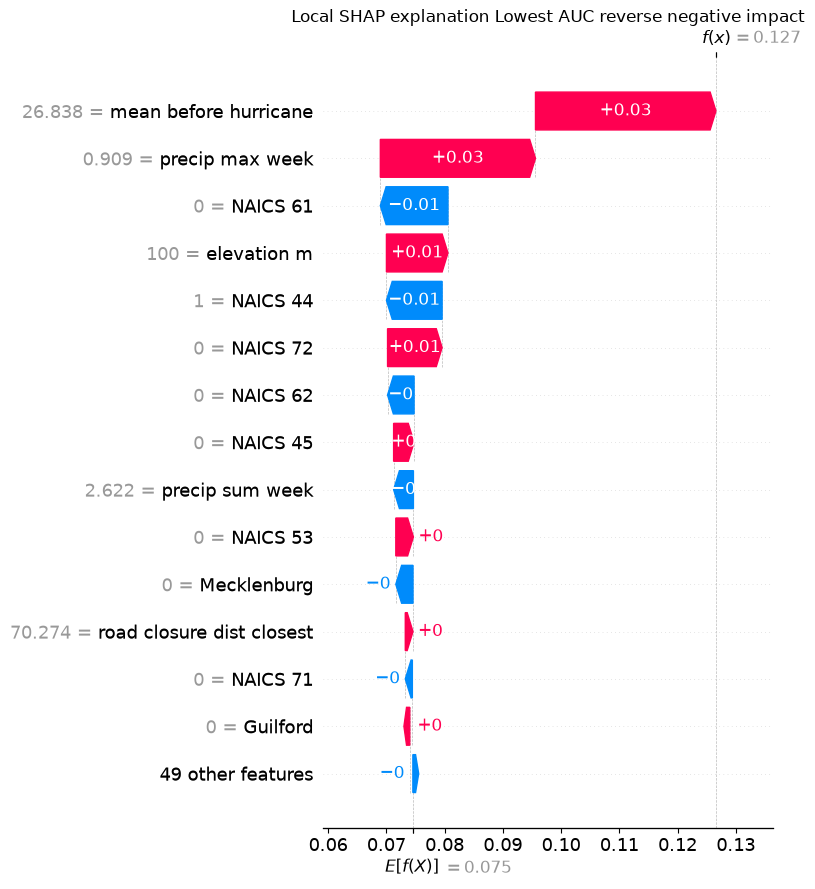

✅ Saved: Local_SHAP_explanation_Median_AUC_case.pdf
Original merged_df row index: 4065
AUC value: 0.087991595
Predicted value: 0.030241694301366806


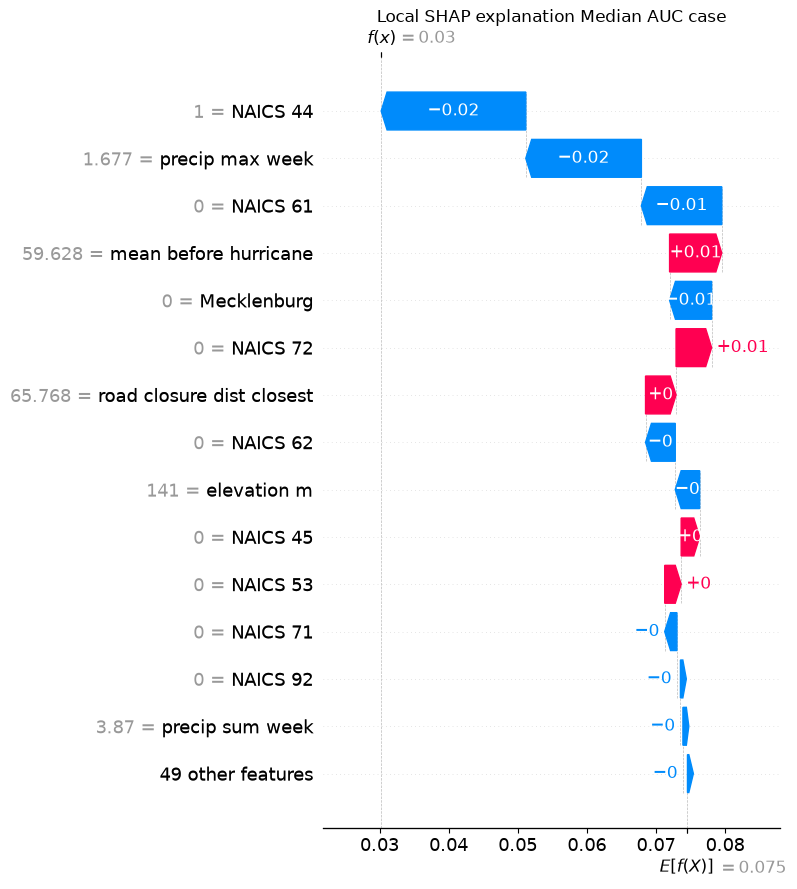

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import shap
import re

# -------------------------------------------------------
# Representative samples based on TEST target y
# -------------------------------------------------------
y_array = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.array(y_test)

i_high = np.argmax(y_array)  # highest AUC = largest disruption
i_low  = np.argmin(y_array)  # lowest AUC = reverse / negative impact
i_med  = np.argmin(np.abs(y_array - np.median(y_array)))

# -------------------------------------------------------
# Waterfall plot function
# -------------------------------------------------------
def plot_waterfall(idx, title):
    plt.close("all")

    row_index = X_test_transformed_df.index[idx]

    single_explanation = shap.Explanation(
        values=shap_values_test.values[idx],
        base_values=shap_values_test.base_values[idx],
        data=X_test_transformed_df.iloc[idx].values,
        feature_names=X_test_transformed_df.columns.tolist()
    )

    shap.waterfall_plot(
        single_explanation,
        show=False,
        max_display=15
    )

    plt.title(title)
    plt.tight_layout()

    safe = re.sub(r"[^A-Za-z0-9]+", "_", title).strip("_")
    fname = f"{safe}.pdf"
    
    try:
        save_path = os.path.join(figures_dir, "SHAP", fname)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
    except NameError:
        save_path = fname

    fig = plt.gcf()
    fig.savefig(save_path, format="pdf", bbox_inches="tight")
    fig.savefig(save_path.replace(".pdf", ".png"), dpi=150, bbox_inches="tight")

    print(f"✅ Saved: {fname}")
    print(f"Original merged_df row index: {row_index}")
    print(f"AUC value: {y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_array[idx]}")
    print(f"Predicted value: {y_test_pred[idx]}")

    plt.show()
    plt.close(fig)

# -------------------------------------------------------
# Generate plots
# -------------------------------------------------------
plot_waterfall(i_high, "Local SHAP explanation Highest AUC largest hurricane impact")
plot_waterfall(i_low,  "Local SHAP explanation Lowest AUC reverse negative impact")
plot_waterfall(i_med,  "Local SHAP explanation Median AUC case")

### Ablation

Some County-NAICS combinations are too rare.
Using NAICS-only stratification instead.
Some NAICS categories are too rare.
Using random split without stratification.
Train size: (4536, 8)
Test size: (1135, 8)

===== Running Ablation: full_model =====
Features used: ['County', 'mean_before_hurricane', 'precip_sum_week', 'precip_mean_week', 'precip_max_week', 'elevation_m', 'naics_2d', 'road_closure_dist_closest']
RMSE = 0.1453, R² = 0.2243

===== Running Ablation: no_precip =====
Features used: ['County', 'mean_before_hurricane', 'elevation_m', 'naics_2d', 'road_closure_dist_closest']
RMSE = 0.1450, R² = 0.2267

===== Running Ablation: no_mean_before =====
Features used: ['County', 'precip_sum_week', 'precip_mean_week', 'precip_max_week', 'elevation_m', 'naics_2d', 'road_closure_dist_closest']
RMSE = 0.1477, R² = 0.1983

===== Running Ablation: no_elevation =====
Features used: ['County', 'mean_before_hurricane', 'precip_sum_week', 'precip_mean_week', 'precip_max_week', 'naics_2d', 'road

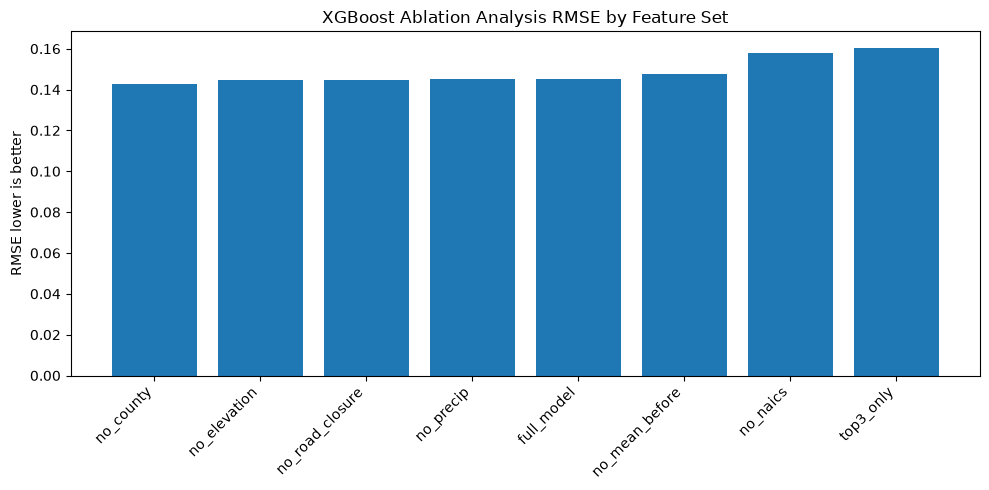

In [39]:
import os
set_reproducible_seeds(42)
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------------------------------
# 1. Define target and non-leakage features
# -------------------------------------------------------
target = "timesfm_auc_total"

full_features = [
    "County",
    "mean_before_hurricane",
    "precip_sum_week",
    "precip_mean_week",
    "precip_max_week",
    "elevation_m",
    "naics_2d",
    "road_closure_dist_closest"
]

X_model = merged_df[full_features].copy()
y = merged_df[target].copy()

# -------------------------------------------------------
# 2. Create same stratification logic
# -------------------------------------------------------
strata = (
    X_model["County"].astype(str) + "_" +
    X_model["naics_2d"].astype(str)
)

strata_counts = strata.value_counts()

if (strata_counts < 2).any():
    print("Some County-NAICS combinations are too rare.")
    print("Using NAICS-only stratification instead.")
    strata = X_model["naics_2d"].astype(str)

if (strata.value_counts() < 2).any():
    print("Some NAICS categories are too rare.")
    print("Using random split without stratification.")
    strata = None

# -------------------------------------------------------
# 3. Create ONE fixed train/test split for all ablations
# -------------------------------------------------------
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=strata
)

print("Train size:", X_train_full.shape)
print("Test size:", X_test_full.shape)

# -------------------------------------------------------
# 4. Ablation configurations
# -------------------------------------------------------
ablation_settings = {
    "full_model": full_features,

    "no_precip": [
        f for f in full_features if f not in
        ["precip_sum_week", "precip_mean_week", "precip_max_week"]
    ],

    "no_mean_before": [
        f for f in full_features if f not in
        ["mean_before_hurricane"]
    ],

    "no_elevation": [
        f for f in full_features if f not in ["elevation_m"]
    ],

    "no_road_closure": [
        f for f in full_features if f not in ["road_closure_dist_closest"]
    ],

    "no_naics": [
        f for f in full_features if f not in ["naics_2d"]
    ],

    "no_county": [
        f for f in full_features if f not in ["County"]
    ],

    "top3_only": [
        "precip_max_week",
        "elevation_m",
        "road_closure_dist_closest"
    ]
}

# -------------------------------------------------------
# 5. Ablation loop
# -------------------------------------------------------
results = []

for name, feature_list in ablation_settings.items():

    print(f"\n===== Running Ablation: {name} =====")

    X_train = X_train_full[feature_list].copy()
    X_test = X_test_full[feature_list].copy()

    categorical_features = [
        c for c in ["County", "naics_2d"]
        if c in feature_list
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ],
        remainder="passthrough"
    )

    xgb_reg = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", xgb_reg)
        ]
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "ablation": name,
        "num_original_features": len(feature_list),
        "features_used": feature_list,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"Features used: {feature_list}")
    print(f"RMSE = {rmse:.4f}, R² = {r2:.4f}")

# -------------------------------------------------------
# 6. Results DataFrame
# -------------------------------------------------------
results_df = pd.DataFrame(results)

results_df["RMSE_change_from_full"] = (
    results_df["RMSE"] - results_df.loc[
        results_df["ablation"] == "full_model", "RMSE"
    ].values[0]
)

results_df["R2_change_from_full"] = (
    results_df["R2"] - results_df.loc[
        results_df["ablation"] == "full_model", "R2"
    ].values[0]
)

results_df = results_df.sort_values("RMSE")

print("\n========== ABLATION SUMMARY ==========\n")
print(results_df)

# -------------------------------------------------------
# 7. Save results
# -------------------------------------------------------
try:
    results_df.to_csv(os.path.join(outputs_dir, "ablation", "xgboost_ablation_results_test_set.csv"), index=False)
except NameError:
    results_df.to_csv("xgboost_ablation_results_test_set.csv", index=False)

# -------------------------------------------------------
# 8. Plot RMSE
# -------------------------------------------------------
plt.close("all")
plt.figure(figsize=(10, 5))

plt.bar(results_df["ablation"], results_df["RMSE"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE lower is better")
plt.title("XGBoost Ablation Analysis RMSE by Feature Set")
plt.tight_layout()

try:
    plt.savefig(
        os.path.join(figures_dir, "ablation", "ablation_rmse_plot.pdf"),
        format="pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(figures_dir, "ablation", "ablation_rmse_plot.png"),
        dpi=150,
        bbox_inches="tight"
    )
except NameError:
    plt.savefig(
        "ablation_rmse_plot.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()
plt.close()

# Transfer for Readme

In [42]:
# Sync the current run's outputs to a static results_latest folder for the README to display
import shutil
import os

# Fallback to locate run_output_dir if undefined (Jupyter kernel restart resilience)
if 'run_output_dir' not in globals() or not run_output_dir:
    import glob
    results_folders = sorted(glob.glob("results_*"))
    if results_folders:
        run_output_dir = results_folders[-1]
        print(f"[info] Automatically set run_output_dir to latest run: {run_output_dir}")
    else:
        run_output_dir = None

latest_dir = "results_latest"
if os.path.exists(latest_dir):
    try:
        shutil.rmtree(latest_dir)
        print(f"Removed existing {latest_dir} directory.")
    except Exception as e:
        print(f"Could not remove existing {latest_dir} directory: {e}")

if run_output_dir and os.path.exists(run_output_dir):
    try:
        # Copy directory contents to the static results_latest folder
        shutil.copytree(run_output_dir, latest_dir)
        print(f"Successfully synced latest run results to: {latest_dir}")
    except Exception as e:
        print(f"Error syncing results to results_latest: {e}")
else:
    print("[info] Skipping results_latest sync: run_output_dir not found or does not exist.")


Successfully synced latest run results to: results_latest
